# 02 — Pendulum pure trajectory-level DPO final experiment

 This is the main  notebook for pure trajectory-level DPO on Pendulum-v1.

**What is done here:**
1. load the selected PPO expert policy $\pi_1$ and weaker/intermediate policy $\pi_2$;
2. generate trajectory-level preference pairs by comparing full rollouts from $\pi_1$ and $\pi_2$;
3. compute trajectory log-probabilities using the sum over timesteps;
4. train pure DPO initialized from $\pi_2$ with a frozen $\pi_2$ reference policy;
5. evaluate DPO across seeds and compare it against $\pi_2$;
6. produce the final trajectory-level DPO numbers used in the report.

**Main interpretation.** Pure trajectory-level DPO slightly improves over $\pi_2$, but remains far from PPO-RLHF and the expert policy. This notebook is the correct source for the main DPO result in the Pendulum section.


## 0. Imports and paths

In [ ]:
import os
import pickle
import random
import copy

import gymnasium as gym
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

from tqdm import tqdm
from stable_baselines3 import PPO


ENV_NAME = "Pendulum-v1"

PI1_PATH = "pendulum_ppo_pi1_final_stronger_minus155"
PI2_PATH = "pendulum_pi2_mid_after_80000_mean_-391"

PURE_DPO_PREFS_PATH = "pure_dpo_trajectory_prefs_pi1_vs_pi2_1000pairs_seed123.pkl"


def set_all_seeds(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


## 1. Policy evaluation

In [2]:
def evaluate_sb3_policy(
    model,
    env_name=ENV_NAME,
    episodes=300,
    deterministic=True,
    seed_start=10_000,
):
    env = gym.make(env_name)
    rewards = []

    for i in range(episodes):
        obs, _ = env.reset(seed=seed_start + i)
        done = False
        total_reward = 0.0

        while not done:
            action, _ = model.predict(obs, deterministic=deterministic)
            obs, reward, terminated, truncated, _ = env.step(action)

            total_reward += float(reward)
            done = terminated or truncated

        rewards.append(total_reward)

    env.close()

    return float(np.mean(rewards)), float(np.std(rewards)), rewards


In [3]:
def sample_raw_action_from_policy(model, obs, env, deterministic=False):
    device = model.policy.device

    obs_tensor = torch.as_tensor(
        obs,
        dtype=torch.float32,
        device=device,
    ).unsqueeze(0)

    with torch.no_grad():
        dist = model.policy.get_distribution(obs_tensor)
        raw_action_tensor = dist.get_actions(deterministic=deterministic)

    raw_action = raw_action_tensor.cpu().numpy().reshape(env.action_space.shape)

    # Pendulum requires action in [-2, 2].
    # This clipped action is only for env.step().
    env_action = np.clip(
        raw_action,
        env.action_space.low,
        env.action_space.high,
    )

    return raw_action.astype(np.float32), env_action.astype(np.float32)


def rollout_trajectory(
    model,
    env_name=ENV_NAME,
    seed=None,
    max_steps=200,
    deterministic=False,
):
    env = gym.make(env_name)
    obs, _ = env.reset(seed=seed)

    obs_list = []
    raw_action_list = []
    env_action_list = []
    reward_list = []

    total_reward = 0.0

    for _ in range(max_steps):
        raw_action, env_action = sample_raw_action_from_policy(
            model,
            obs,
            env,
            deterministic=deterministic,
        )

        next_obs, reward, terminated, truncated, _ = env.step(env_action)

        obs_list.append(np.asarray(obs, dtype=np.float32).copy())
        raw_action_list.append(raw_action.copy())
        env_action_list.append(env_action.copy())
        reward_list.append(float(reward))

        total_reward += float(reward)
        obs = next_obs

        if terminated or truncated:
            break

    env.close()

    return {
        "obs": np.asarray(obs_list, dtype=np.float32),
        "raw_actions": np.asarray(raw_action_list, dtype=np.float32),
        "env_actions": np.asarray(env_action_list, dtype=np.float32),
        "rewards": np.asarray(reward_list, dtype=np.float32),
        "return": float(total_reward),
        "length": len(raw_action_list),
    }


## 3. Preference probability from the assignment

The assignment formula is:

$$
\frac{\exp(R_1)}{\exp(R_1)+\exp(R_2)}.
$$

This is exactly the same as:

$$
\sigma(R_1-R_2).
$$

We use the sigmoid version because it is numerically stable.


In [4]:
def stable_preference_probability(ret1, ret2):
    # exp(R1) / (exp(R1) + exp(R2)) = sigmoid(R1 - R2)
    diff = ret1 - ret2

    if diff > 50:
        return 1.0
    if diff < -50:
        return 0.0

    return float(1.0 / (1.0 + np.exp(-diff)))


## 4. Collect trajectory preference dataset

In [5]:
def collect_trajectory_preference_dataset(
    pi1_model,
    pi2_model,
    K=1000,
    env_name=ENV_NAME,
    seed_start=123,
    deterministic_rollouts=False,
):
    prefs = []

    for k in tqdm(range(K), desc="Collecting trajectory preferences"):
        seed = seed_start + k

        tau1 = rollout_trajectory(
            pi1_model,
            env_name=env_name,
            seed=seed,
            deterministic=deterministic_rollouts,
        )

        tau2 = rollout_trajectory(
            pi2_model,
            env_name=env_name,
            seed=seed,
            deterministic=deterministic_rollouts,
        )

        ret1 = tau1["return"]
        ret2 = tau2["return"]

        p_tau1_preferred = stable_preference_probability(ret1, ret2)

        if np.random.rand() < p_tau1_preferred:
            winner = tau1
            loser = tau2
        else:
            winner = tau2
            loser = tau1

        prefs.append({
            "winner_obs": winner["obs"],
            "winner_raw_actions": winner["raw_actions"],
            "winner_env_actions": winner["env_actions"],
            "winner_return": winner["return"],
            "winner_length": winner["length"],

            "loser_obs": loser["obs"],
            "loser_raw_actions": loser["raw_actions"],
            "loser_env_actions": loser["env_actions"],
            "loser_return": loser["return"],
            "loser_length": loser["length"],

            "pi1_return": ret1,
            "pi2_return": ret2,
            "p_pi1_preferred": p_tau1_preferred,
        })

    return prefs


def summarize_preference_dataset(prefs):
    winner_returns = np.array([p["winner_return"] for p in prefs])
    loser_returns = np.array([p["loser_return"] for p in prefs])
    pi1_returns = np.array([p["pi1_return"] for p in prefs])
    pi2_returns = np.array([p["pi2_return"] for p in prefs])
    winner_lengths = np.array([p["winner_length"] for p in prefs])
    loser_lengths = np.array([p["loser_length"] for p in prefs])

    print("Number of pairs:", len(prefs))
    print("Winner return mean/std:", winner_returns.mean(), winner_returns.std())
    print("Loser return mean/std:", loser_returns.mean(), loser_returns.std())
    print("π1 return mean/std:", pi1_returns.mean(), pi1_returns.std())
    print("π2 return mean/std:", pi2_returns.mean(), pi2_returns.std())
    print("Winner length unique:", np.unique(winner_lengths))
    print("Loser length unique:", np.unique(loser_lengths))
    print("Fraction winner_return >= loser_return:", np.mean(winner_returns >= loser_returns))
    print("Mean winner-loser return margin:", np.mean(winner_returns - loser_returns))


## 5. Load policies and create/load dataset

In [ ]:
set_all_seeds(42)

pi1_model = PPO.load(PI1_PATH, device="cpu")
pi2_model = PPO.load(PI2_PATH, device="cpu")

pi1_mean, pi1_std, _ = evaluate_sb3_policy(
    pi1_model,
    episodes=300,
    deterministic=True,
    seed_start=10_000,
)

pi2_mean, pi2_std, _ = evaluate_sb3_policy(
    pi2_model,
    episodes=300,
    deterministic=True,
    seed_start=10_000,
)

print("π1 expert deterministic evaluation:", pi1_mean, pi1_std)
print("π2 intermediate deterministic evaluation:", pi2_mean, pi2_std)

if os.path.exists(PURE_DPO_PREFS_PATH):
    print("Loading cached pure DPO trajectory preference dataset...")
    with open(PURE_DPO_PREFS_PATH, "rb") as f:
        trajectory_prefs = pickle.load(f)
else:
    print("Creating new pure DPO trajectory preference dataset...")
    trajectory_prefs = collect_trajectory_preference_dataset(
        pi1_model,
        pi2_model,
        K=1000,
        seed_start=123,
        deterministic_rollouts=False,
    )

    with open(PURE_DPO_PREFS_PATH, "wb") as f:
        pickle.dump(trajectory_prefs, f)

summarize_preference_dataset(trajectory_prefs)


## 6. Pure trajectory log-probability


In [6]:
def trajectory_logprob_sum(model, obs_np, raw_actions_np):
    device = model.policy.device

    obs = torch.as_tensor(
        obs_np,
        dtype=torch.float32,
        device=device,
    )

    actions = torch.as_tensor(
        raw_actions_np,
        dtype=torch.float32,
        device=device,
    )

    dist = model.policy.get_distribution(obs)
    log_probs = dist.log_prob(actions)

    if log_probs.ndim > 1:
        log_probs = log_probs.sum(dim=-1)

    return log_probs.sum()


## 7. Pure DPO batch loss

In [7]:
def pure_trajectory_dpo_batch_loss(policy_model, ref_model, batch, beta=0.01):
    logits = []

    for pair in batch:
        pi_winner = trajectory_logprob_sum(
            policy_model,
            pair["winner_obs"],
            pair["winner_raw_actions"],
        )

        pi_loser = trajectory_logprob_sum(
            policy_model,
            pair["loser_obs"],
            pair["loser_raw_actions"],
        )

        with torch.no_grad():
            ref_winner = trajectory_logprob_sum(
                ref_model,
                pair["winner_obs"],
                pair["winner_raw_actions"],
            )

            ref_loser = trajectory_logprob_sum(
                ref_model,
                pair["loser_obs"],
                pair["loser_raw_actions"],
            )

        policy_gap = pi_winner - pi_loser
        ref_gap = ref_winner - ref_loser

        logit = beta * (policy_gap - ref_gap)
        logits.append(logit)

    logits = torch.stack(logits)
    loss = -F.logsigmoid(logits).mean()

    return loss


## 8. Train pure DPO



In [8]:
def train_pure_trajectory_dpo_with_eval(
    policy_model,
    ref_model,
    prefs,
    epochs=5,
    batch_size=16,
    lr=1e-6,
    beta=0.01,
    eval_episodes=100,
    eval_seed_start=20_000,
):
    policy_model.policy.train()
    ref_model.policy.eval()

    # Freeze reference policy
    for p in ref_model.policy.parameters():
        p.requires_grad = False

    # Train full policy
    for p in policy_model.policy.parameters():
        p.requires_grad = True

    optimizer = torch.optim.Adam(policy_model.policy.parameters(), lr=lr)

    losses = []
    rewards = []
    reward_stds = []

    for epoch in range(epochs):
        random.shuffle(prefs)

        total_loss = 0.0
        num_batches = 0

        for start in tqdm(
            range(0, len(prefs), batch_size),
            desc=f"Pure DPO epoch {epoch+1}/{epochs}",
        ):
            batch = prefs[start:start + batch_size]

            loss = pure_trajectory_dpo_batch_loss(
                policy_model,
                ref_model,
                batch,
                beta=beta,
            )

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += float(loss.item())
            num_batches += 1

        avg_loss = total_loss / max(num_batches, 1)
        losses.append(avg_loss)

        # Evaluate after every epoch
        mean_reward, std_reward, _ = evaluate_sb3_policy(
            policy_model,
            episodes=eval_episodes,
            deterministic=True,
            seed_start=eval_seed_start,
        )

        rewards.append(mean_reward)
        reward_stds.append(std_reward)

        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"pure DPO loss = {avg_loss:.6f} | "
            f"eval reward = {mean_reward:.2f} ± {std_reward:.2f}"
        )

    return policy_model, {
        "loss": losses,
        "reward": rewards,
        "reward_std": reward_stds,
    }

## 9. One pure DPO test


In [9]:
def plot_dpo_training_progress(history, title="Pure DPO training progress"):
    epochs = np.arange(1, len(history["loss"]) + 1)

    fig, ax1 = plt.subplots(figsize=(9, 5))

    ax1.plot(
        epochs,
        history["loss"],
        marker="o",
        color="red",
        label="Average DPO loss",
    )
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Average DPO loss", color="red")
    ax1.tick_params(axis="y", labelcolor="red")
    ax1.grid(True)

    ax2 = ax1.twinx()
    ax2.plot(
        epochs,
        history["reward"],
        marker="s",
        color="blue",
        label="Evaluation reward",
    )
    ax2.set_ylabel("Evaluation reward", color="blue")
    ax2.tick_params(axis="y", labelcolor="blue")

    plt.title(title)
    fig.tight_layout()
    plt.show()

In [10]:
def run_one_pure_dpo_test(
    beta=0.01,
    lr=1e-6,
    epochs=5,
    batch_size=16,
    seed=0,
    eval_seed_start=20_000,
):
    set_all_seeds(seed)

    env_train = gym.make(ENV_NAME)

    # Fresh copies every time
    policy_model = PPO.load(PI2_PATH, env=env_train, device="cpu")
    ref_model = PPO.load(PI2_PATH, env=env_train, device="cpu")

    trained_model, history = train_pure_trajectory_dpo_with_eval(
        policy_model=policy_model,
        ref_model=ref_model,
        prefs=copy.deepcopy(trajectory_prefs),
        epochs=epochs,
        batch_size=batch_size,
        lr=lr,
        beta=beta,
        eval_episodes=100,
        eval_seed_start=eval_seed_start,
    )

    pi2_same_mean, pi2_same_std, _ = evaluate_sb3_policy(
        pi2_model,
        episodes=100,
        deterministic=True,
        seed_start=eval_seed_start,
    )

    dpo_mean, dpo_std, _ = evaluate_sb3_policy(
        trained_model,
        episodes=100,
        deterministic=True,
        seed_start=eval_seed_start,
    )

    env_train.close()

    print("π2 same seeds:", pi2_same_mean, pi2_same_std)
    print("Pure DPO same seeds:", dpo_mean, dpo_std)

    # Plot like your friend's graph: loss + reward
    epochs_arr = np.arange(1, len(history["loss"]) + 1)

    fig, ax1 = plt.subplots(figsize=(9, 5))

    ax1.plot(
        epochs_arr,
        history["loss"],
        marker="o",
        color="red",
        label="Average DPO loss",
    )
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Average DPO loss", color="red")
    ax1.tick_params(axis="y", labelcolor="red")
    ax1.grid(True)

    ax2 = ax1.twinx()
    ax2.plot(
        epochs_arr,
        history["reward"],
        marker="s",
        color="blue",
        label="Evaluation reward",
    )
    ax2.set_ylabel("Evaluation reward", color="blue")
    ax2.tick_params(axis="y", labelcolor="blue")

    plt.title(f"Pure trajectory-level DPO: beta={beta}, lr={lr}")
    fig.tight_layout()
    plt.show()

    return trained_model, history, dpo_mean, dpo_std

Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


Pure DPO epoch 1/5: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 63/63 [00:02<00:00, 26.22it/s]


Epoch 1/5 | pure DPO loss = 0.677668 | eval reward = -387.97 ± 169.51


Pure DPO epoch 2/5: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 63/63 [00:02<00:00, 24.15it/s]


Epoch 2/5 | pure DPO loss = 0.645867 | eval reward = -384.12 ± 162.27


...

Epoch 3/5 | pure DPO loss = 0.616207 | eval reward = -409.94 ± 152.30


Pure DPO epoch 4/5: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 63/63 [00:02<00:00, 25.79it/s]


Epoch 4/5 | pure DPO loss = 0.588401 | eval reward = -425.94 ± 151.13


Pure DPO epoch 5/5: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 63/63 [00:02<00:00, 25.55it/s]


Epoch 5/5 | pure DPO loss = 0.561239 | eval reward = -437.49 ± 151.89
π2 same seeds: -391.88436331839125 170.65796681560818
Pure DPO same seeds: -437.4939728515355 151.89162315141064


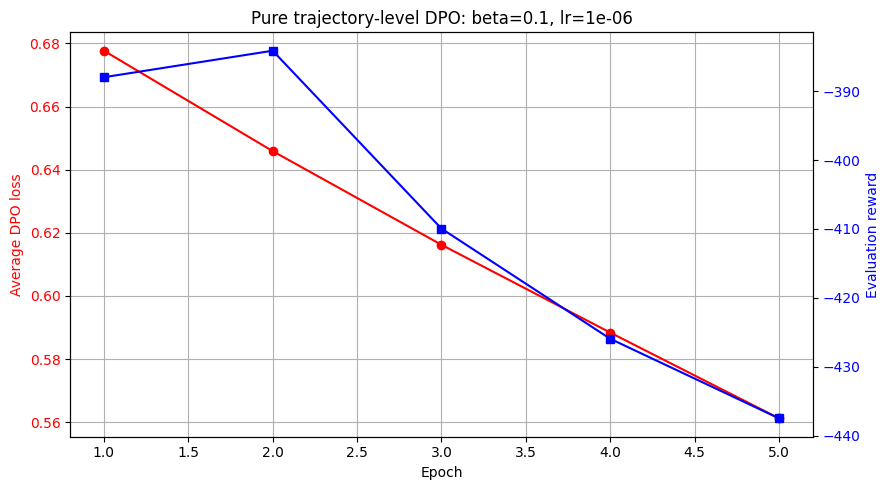

In [17]:
trained_dpo_model, history, dpo_mean, dpo_std = run_one_pure_dpo_test(
    beta=0.1,
    lr=1e-6,
    epochs=5,
    batch_size=16,
    seed=0,
)

In [ ]:
def inspect_action_clipping(prefs):
    winner_raw = np.concatenate([p["winner_raw_actions"] for p in prefs], axis=0)
    winner_env = np.concatenate([p["winner_env_actions"] for p in prefs], axis=0)

    loser_raw = np.concatenate([p["loser_raw_actions"] for p in prefs], axis=0)
    loser_env = np.concatenate([p["loser_env_actions"] for p in prefs], axis=0)

    winner_clipped = np.abs(winner_raw - winner_env) > 1e-6
    loser_clipped = np.abs(loser_raw - loser_env) > 1e-6

    print("Winner raw min/max:", winner_raw.min(), winner_raw.max())
    print("Winner env min/max:", winner_env.min(), winner_env.max())
    print("Winner clipped fraction:", winner_clipped.mean())

    print("Loser raw min/max:", loser_raw.min(), loser_raw.max())
    print("Loser env min/max:", loser_env.min(), loser_env.max())
    print("Loser clipped fraction:", loser_clipped.mean())

inspect_action_clipping(trajectory_prefs)

In [19]:
def inspect_policy_std(model, name="model"):
    if hasattr(model.policy, "log_std"):
        log_std = model.policy.log_std.detach().cpu().numpy()
        std = np.exp(log_std)
        print(name, "log_std:", log_std)
        print(name, "std:", std)
    else:
        print(name, "has no log_std")

inspect_policy_std(pi2_model, "π2 before DPO")
inspect_policy_std(trained_dpo_model, "DPO after training")

π2 before DPO log_std: [-0.54571027]
π2 before DPO std: [0.57943004]
DPO after training log_std: [-0.545567]
DPO after training std: [0.5795131]


Winner clipped fraction: 0.065475
Loser clipped fraction: 0.219735


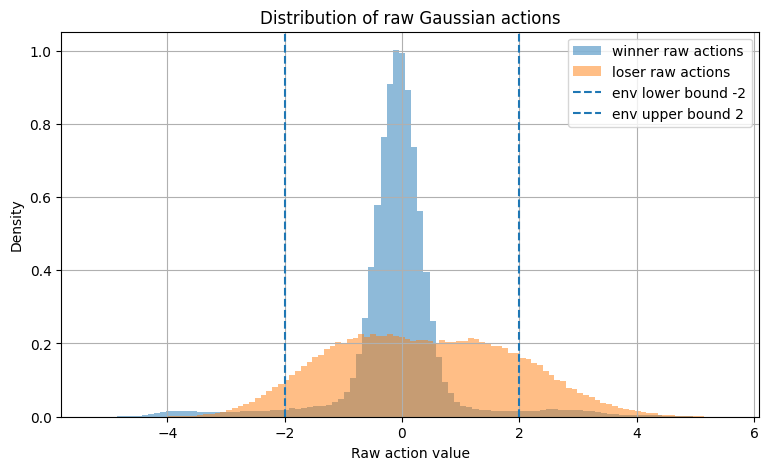

In [20]:
def plot_action_distributions(prefs, bins=100):
    winner_raw = np.concatenate([p["winner_raw_actions"] for p in prefs], axis=0).reshape(-1)
    winner_env = np.concatenate([p["winner_env_actions"] for p in prefs], axis=0).reshape(-1)

    loser_raw = np.concatenate([p["loser_raw_actions"] for p in prefs], axis=0).reshape(-1)
    loser_env = np.concatenate([p["loser_env_actions"] for p in prefs], axis=0).reshape(-1)

    winner_clipped = np.abs(winner_raw - winner_env) > 1e-6
    loser_clipped = np.abs(loser_raw - loser_env) > 1e-6

    print("Winner clipped fraction:", winner_clipped.mean())
    print("Loser clipped fraction:", loser_clipped.mean())

    plt.figure(figsize=(9, 5))
    plt.hist(winner_raw, bins=bins, alpha=0.5, density=True, label="winner raw actions")
    plt.hist(loser_raw, bins=bins, alpha=0.5, density=True, label="loser raw actions")

    plt.axvline(-2.0, linestyle="--", label="env lower bound -2")
    plt.axvline(2.0, linestyle="--", label="env upper bound 2")

    plt.xlabel("Raw action value")
    plt.ylabel("Density")
    plt.title("Distribution of raw Gaussian actions")
    plt.grid(True)
    plt.legend()
    plt.show()


plot_action_distributions(trajectory_prefs)

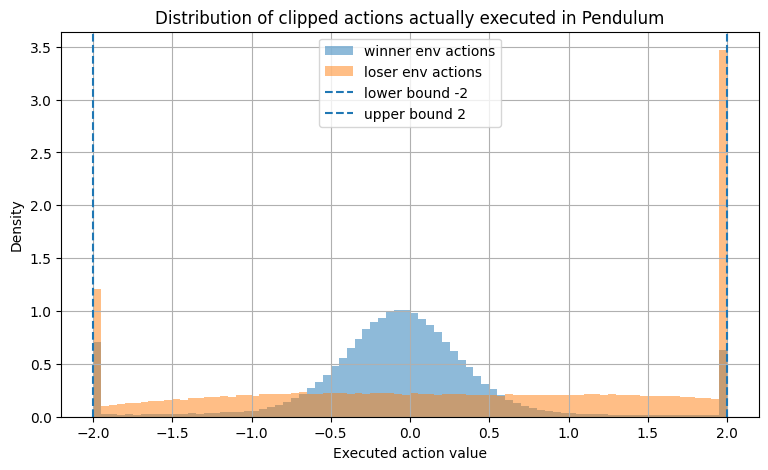

In [21]:
def plot_env_action_distributions(prefs, bins=80):
    winner_env = np.concatenate([p["winner_env_actions"] for p in prefs], axis=0).reshape(-1)
    loser_env = np.concatenate([p["loser_env_actions"] for p in prefs], axis=0).reshape(-1)

    plt.figure(figsize=(9, 5))
    plt.hist(winner_env, bins=bins, alpha=0.5, density=True, label="winner env actions")
    plt.hist(loser_env, bins=bins, alpha=0.5, density=True, label="loser env actions")

    plt.axvline(-2.0, linestyle="--", label="lower bound -2")
    plt.axvline(2.0, linestyle="--", label="upper bound 2")

    plt.xlabel("Executed action value")
    plt.ylabel("Density")
    plt.title("Distribution of clipped actions actually executed in Pendulum")
    plt.grid(True)
    plt.legend()
    plt.show()


plot_env_action_distributions(trajectory_prefs)

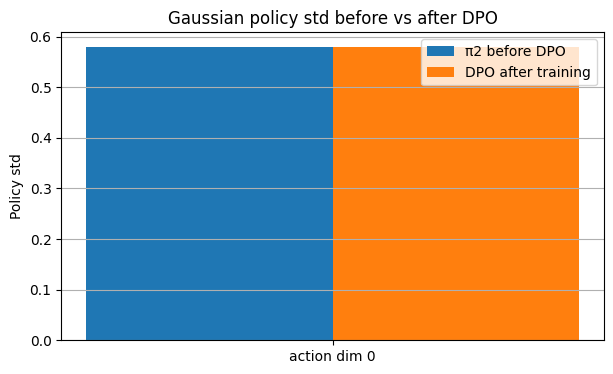

π2 std: [0.57943004]
DPO std: [0.5795131]


In [22]:
def plot_policy_std_before_after(before_model, after_model):
    before_log_std = before_model.policy.log_std.detach().cpu().numpy().reshape(-1)
    after_log_std = after_model.policy.log_std.detach().cpu().numpy().reshape(-1)

    before_std = np.exp(before_log_std)
    after_std = np.exp(after_log_std)

    labels = [f"action dim {i}" for i in range(len(before_std))]

    x = np.arange(len(labels))
    width = 0.35

    plt.figure(figsize=(7, 4))
    plt.bar(x - width / 2, before_std, width, label="π2 before DPO")
    plt.bar(x + width / 2, after_std, width, label="DPO after training")

    plt.xticks(x, labels)
    plt.ylabel("Policy std")
    plt.title("Gaussian policy std before vs after DPO")
    plt.grid(True, axis="y")
    plt.legend()
    plt.show()

    print("π2 std:", before_std)
    print("DPO std:", after_std)


plot_policy_std_before_after(pi2_model, trained_dpo_model)

In [ ]:
def get_policy_mean_actions(model, obs_np):
    device = model.policy.device

    obs_tensor = torch.as_tensor(
        obs_np,
        dtype=torch.float32,
        device=device,
    )

    with torch.no_grad():
        dist = model.policy.get_distribution(obs_tensor)
        mean_actions = dist.distribution.mean

    return mean_actions.cpu().numpy().reshape(-1)


def plot_policy_mean_shift(before_model, after_model, prefs, bins=100, max_points=50_000):
    obs = np.concatenate(
        [p["winner_obs"] for p in prefs] + [p["loser_obs"] for p in prefs],
        axis=0,
    ).astype(np.float32)

    if len(obs) > max_points:
        idx = np.random.choice(len(obs), size=max_points, replace=False)
        obs = obs[idx]

    before_mean = get_policy_mean_actions(before_model, obs)
    after_mean = get_policy_mean_actions(after_model, obs)

    diff = after_mean - before_mean

    print("Mean absolute shift:", np.mean(np.abs(diff)))
    print("Max absolute shift:", np.max(np.abs(diff)))
    print("Before mean action min/max:", before_mean.min(), before_mean.max())
    print("After mean action min/max:", after_mean.min(), after_mean.max())

    plt.figure(figsize=(9, 5))
    plt.hist(before_mean, bins=bins, alpha=0.5, density=True, label="π2 mean actions")
    plt.hist(after_mean, bins=bins, alpha=0.5, density=True, label="DPO mean actions")

    plt.axvline(-2.0, linestyle="--", label="lower bound -2")
    plt.axvline(2.0, linestyle="--", label="upper bound 2")

    plt.xlabel("Policy mean action")
    plt.ylabel("Density")
    plt.title("Policy mean action distribution before vs after DPO")
    plt.grid(True)
    plt.legend()
    plt.show()

    plt.figure(figsize=(9, 5))
    plt.hist(diff, bins=bins, density=True)
    plt.xlabel("DPO mean action - π2 mean action")
    plt.ylabel("Density")
    plt.title("Distribution of policy mean shifts caused by DPO")
    plt.grid(True)
    plt.show()


In [16]:
def inspect_preference_dataset(prefs, n=1000):
    winner_returns = np.array([p["winner_return"] for p in prefs[:n]])
    loser_returns = np.array([p["loser_return"] for p in prefs[:n]])
    pi1_returns = np.array([p["pi1_return"] for p in prefs[:n]])
    pi2_returns = np.array([p["pi2_return"] for p in prefs[:n]])

    print("Mean winner return:", winner_returns.mean())
    print("Mean loser return:", loser_returns.mean())
    print("Mean winner - loser:", (winner_returns - loser_returns).mean())
    print("Fraction winner better:", np.mean(winner_returns >= loser_returns))
    print("Mean pi1 return:", pi1_returns.mean())
    print("Mean pi2 return:", pi2_returns.mean())
    print("Fraction pi1 better than pi2:", np.mean(pi1_returns >= pi2_returns))

inspect_preference_dataset(trajectory_prefs)

Mean winner return: -160.2005702606245
Mean loser return: -538.384649192439
Mean winner - loser: 378.1840789318146
Fraction winner better: 0.999
Mean pi1 return: -160.56892419769912
Mean pi2 return: -538.0162952553644
Fraction pi1 better than pi2: 0.998


In [11]:
def run_one_pure_dpo_sweep_run(
    beta=0.001,
    lr=1e-7,
    epochs=10,
    batch_size=16,
    seed=0,
    eval_episodes=50,
    eval_seed_start=20_000,
):
    set_all_seeds(seed)

    env_train = gym.make(ENV_NAME)

    # Fresh copy every time
    policy_model = PPO.load(PI2_PATH, env=env_train, device="cpu")
    ref_model = PPO.load(PI2_PATH, env=env_train, device="cpu")

    trained_model, history = train_pure_trajectory_dpo_with_eval(
        policy_model=policy_model,
        ref_model=ref_model,
        prefs=copy.deepcopy(trajectory_prefs),
        epochs=epochs,
        batch_size=batch_size,
        lr=lr,
        beta=beta,
        eval_episodes=eval_episodes,
        eval_seed_start=eval_seed_start,
    )

    pi2_mean, pi2_std, _ = evaluate_sb3_policy(
        pi2_model,
        episodes=eval_episodes,
        deterministic=True,
        seed_start=eval_seed_start,
    )

    final_mean, final_std, _ = evaluate_sb3_policy(
        trained_model,
        episodes=eval_episodes,
        deterministic=True,
        seed_start=eval_seed_start,
    )

    env_train.close()

    best_epoch_idx = int(np.argmax(history["reward"]))
    best_reward = float(history["reward"][best_epoch_idx])
    best_epoch = best_epoch_idx + 1

    return {
        "beta": beta,
        "lr": lr,
        "epochs": epochs,
        "batch_size": batch_size,
        "seed": seed,
        "pi2_mean": pi2_mean,
        "pi2_std": pi2_std,
        "final_reward": final_mean,
        "final_std": final_std,
        "best_reward": best_reward,
        "best_epoch": best_epoch,
        "final_loss": history["loss"][-1],
        "best_loss": history["loss"][best_epoch_idx],
        "history": history,
        "model": trained_model,
    }

In [26]:
configs = [
    {"beta": 0.0001, "lr": 1e-6, "epochs": 10},
    {"beta": 0.0003, "lr": 1e-6, "epochs": 10},
    {"beta": 0.001,  "lr": 1e-6, "epochs": 10},
    {"beta": 0.003,  "lr": 1e-6, "epochs": 10},
    {"beta": 0.001,  "lr": 3e-6, "epochs": 10},
    {"beta": 0.003,  "lr": 3e-6, "epochs": 10},
]

sweep_runs = []
rows = []

for cfg in configs:
    print("\n" + "=" * 80)
    print("CONFIG:", cfg)
    print("=" * 80)

    result = run_one_pure_dpo_sweep_run(
        beta=cfg["beta"],
        lr=cfg["lr"],
        epochs=cfg["epochs"],
        batch_size=16,
        seed=0,
        eval_episodes=50,
        eval_seed_start=20_000,
    )

    sweep_runs.append(result)

    rows.append({
        "beta": result["beta"],
        "lr": result["lr"],
        "epochs": result["epochs"],
        "seed": result["seed"],
        "pi2_mean": result["pi2_mean"],
        "final_reward": result["final_reward"],
        "best_reward": result["best_reward"],
        "best_epoch": result["best_epoch"],
        "final_loss": result["final_loss"],
        "best_loss": result["best_loss"],
        "improvement_final": result["final_reward"] - result["pi2_mean"],
        "improvement_best": result["best_reward"] - result["pi2_mean"],
    })

pure_sweep_df = pd.DataFrame(rows)
pure_sweep_df.sort_values("best_reward", ascending=False)


CONFIG: {'beta': 0.0001, 'lr': 1e-06, 'epochs': 10}
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


Pure DPO epoch 1/10: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 63/63 [00:02<00:00, 25.86it/s]


Epoch 1/10 | pure DPO loss = 0.693131 | eval reward = -379.53 ± 159.39


Pure DPO epoch 2/10: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 63/63 [00:02<00:00, 23.24it/s]


Epoch 2/10 | pure DPO loss = 0.693097 | eval reward = -375.75 ± 161.85


...

Pure DPO epoch 9/10: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 63/63 [00:02<00:00, 26.07it/s]


Epoch 9/10 | pure DPO loss = 0.652452 | eval reward = -855.55 ± 237.38


Pure DPO epoch 10/10: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 63/63 [00:02<00:00, 25.67it/s]


Epoch 10/10 | pure DPO loss = 0.644942 | eval reward = -885.65 ± 232.63


,beta,lr,epochs,seed,pi2_mean,final_reward,best_reward,best_epoch,final_loss,best_loss,improvement_final,improvement_best
3,0.0030,0.000001,10,0,-383.747353,-494.267114,-375.737306,2,0.681960,0.691637,-110.519761,8.010047
2,0.0010,0.000001,10,0,-383.747353,-494.951049,-375.748583,2,0.689383,0.692643,-111.203696,7.998771
1,0.0003,0.000001,10,0,-383.747353,-495.193672,-375.752399,2,0.692014,0.692996,-111.446319,7.994954
0,0.0001,0.000001,10,0,-383.747353,-495.266982,-375.752987,2,0.692769,0.693097,-111.519628,7.994367
5,0.0030,0.000003,10,0,-383.747353,-885.650629,-407.657070,1,0.644942,0.691695,-501.903276,-23.909716
4,0.0010,0.000003,10,0,-383.747353,-888.517007,-407.675530,1,0.676507,0.692663,-504.769654,-23.928177


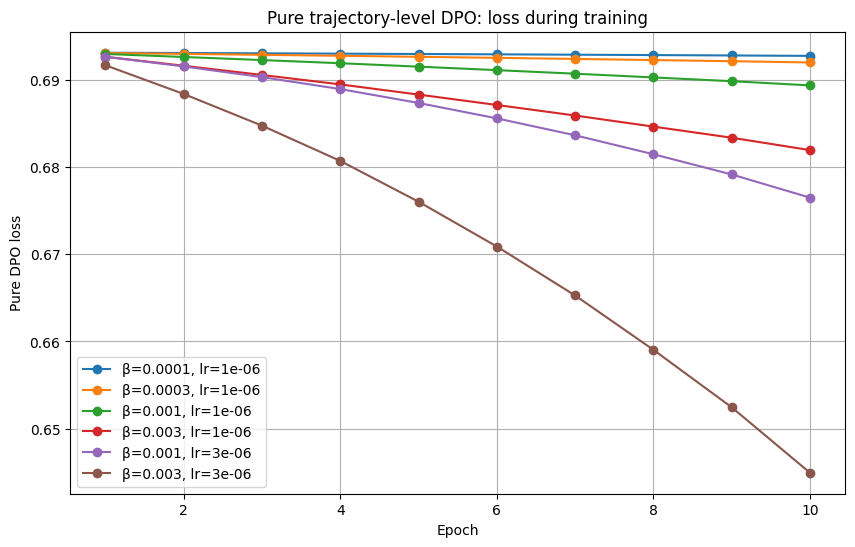

In [28]:
plt.figure(figsize=(10, 6))

for result in sweep_runs:
    label = f"β={result['beta']}, lr={result['lr']}"
    epochs_arr = np.arange(1, len(result["history"]["loss"]) + 1)
    plt.plot(epochs_arr, result["history"]["loss"], marker="o", label=label)

plt.xlabel("Epoch")
plt.ylabel("Pure DPO loss")
plt.title("Pure trajectory-level DPO: loss during training")
plt.grid(True)
plt.legend()
plt.show()

In [12]:
import copy
import math

def train_pure_trajectory_dpo_with_eval_scheduler(
    policy_model,
    ref_model,
    prefs,
    epochs=5,
    batch_size=16,
    lr=1e-6,
    beta=0.01,
    eval_episodes=100,
    eval_seed_start=20_000,
    warmup_frac=0.1,
    min_lr_frac=0.05,
):
    policy_model.policy.train()
    ref_model.policy.eval()

    for p in ref_model.policy.parameters():
        p.requires_grad = False

    for p in policy_model.policy.parameters():
        p.requires_grad = True

    optimizer = torch.optim.Adam(policy_model.policy.parameters(), lr=lr)

    total_steps = epochs * math.ceil(len(prefs) / batch_size)
    warmup_steps = max(1, int(warmup_frac * total_steps))
    global_step = 0

    losses = []
    rewards = []
    reward_stds = []
    lrs = []

    best_reward = -float("inf")
    best_state_dict = None
    best_epoch = None

    def get_lr(step):
        if step < warmup_steps:
            return lr * (step + 1) / warmup_steps

        progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
        cosine = 0.5 * (1.0 + math.cos(math.pi * progress))
        min_lr = min_lr_frac * lr
        return min_lr + (lr - min_lr) * cosine

    for epoch in range(epochs):
        random.shuffle(prefs)

        total_loss = 0.0
        num_batches = 0

        for start in tqdm(
            range(0, len(prefs), batch_size),
            desc=f"Pure DPO epoch {epoch+1}/{epochs}",
        ):
            current_lr = get_lr(global_step)
            for group in optimizer.param_groups:
                group["lr"] = current_lr

            batch = prefs[start:start + batch_size]

            loss = pure_trajectory_dpo_batch_loss(
                policy_model,
                ref_model,
                batch,
                beta=beta,
            )

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += float(loss.item())
            num_batches += 1
            global_step += 1

        avg_loss = total_loss / max(num_batches, 1)
        losses.append(avg_loss)
        lrs.append(current_lr)

        mean_reward, std_reward, _ = evaluate_sb3_policy(
            policy_model,
            episodes=eval_episodes,
            deterministic=True,
            seed_start=eval_seed_start,
        )

        rewards.append(mean_reward)
        reward_stds.append(std_reward)

        if mean_reward > best_reward:
            best_reward = mean_reward
            best_epoch = epoch + 1
            best_state_dict = copy.deepcopy(policy_model.policy.state_dict())

        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"loss={avg_loss:.6f} | "
            f"reward={mean_reward:.2f} ± {std_reward:.2f} | "
            f"lr={current_lr:.2e}"
        )

    if best_state_dict is not None:
        policy_model.policy.load_state_dict(best_state_dict)

    print(f"Loaded best epoch: {best_epoch}, best reward: {best_reward:.2f}")

    return policy_model, {
        "loss": losses,
        "reward": rewards,
        "reward_std": reward_stds,
        "lr": lrs,
        "best_reward": best_reward,
        "best_epoch": best_epoch,
    }

In [14]:
def run_one_pure_dpo_scheduler_test(
    beta=0.01,
    lr=1e-6,
    epochs=5,
    batch_size=16,
    seed=0,
    eval_episodes=100,
    eval_seed_start=20_000,
):
    set_all_seeds(seed)

    env_train = gym.make(ENV_NAME)

    policy_model = PPO.load(PI2_PATH, env=env_train, device="cpu")
    ref_model = PPO.load(PI2_PATH, env=env_train, device="cpu")

    trained_model, history = train_pure_trajectory_dpo_with_eval_scheduler(
        policy_model=policy_model,
        ref_model=ref_model,
        prefs=copy.deepcopy(trajectory_prefs),
        epochs=epochs,
        batch_size=batch_size,
        lr=lr,
        beta=beta,
        eval_episodes=eval_episodes,
        eval_seed_start=eval_seed_start,
        warmup_frac=0.1,
        min_lr_frac=0.05,
    )

    pi2_mean, pi2_std, _ = evaluate_sb3_policy(
        pi2_model,
        episodes=eval_episodes,
        deterministic=True,
        seed_start=eval_seed_start,
    )

    dpo_mean, dpo_std, _ = evaluate_sb3_policy(
        trained_model,
        episodes=eval_episodes,
        deterministic=True,
        seed_start=eval_seed_start,
    )

    env_train.close()

    print("π2 same seeds:", pi2_mean, pi2_std)
    print("Best-loaded DPO same seeds:", dpo_mean, dpo_std)

    return {
        "beta": beta,
        "lr": lr,
        "epochs": epochs,
        "seed": seed,
        "pi2_mean": pi2_mean,
        "dpo_mean": dpo_mean,
        "dpo_std": dpo_std,
        "improvement": dpo_mean - pi2_mean,
        "best_epoch": history["best_epoch"],
        "best_reward_during_training": history["best_reward"],
        "history": history,
        "model": trained_model,
    }

In [31]:
configs_scheduler = [
    {"beta": 0.003, "lr": 1e-6, "epochs": 5},
    {"beta": 0.01,  "lr": 1e-6, "epochs": 5},
    {"beta": 0.03,  "lr": 1e-6, "epochs": 5},
    {"beta": 0.1,   "lr": 3e-7, "epochs": 5},
    {"beta": 0.3,   "lr": 3e-7, "epochs": 5},
]

scheduler_runs = []
scheduler_rows = []

for cfg in configs_scheduler:
    print("\n" + "=" * 80)
    print("SCHEDULER CONFIG:", cfg)
    print("=" * 80)

    result = run_one_pure_dpo_scheduler_test(
        beta=cfg["beta"],
        lr=cfg["lr"],
        epochs=cfg["epochs"],
        batch_size=16,
        seed=0,
        eval_episodes=100,
        eval_seed_start=20_000,
    )

    scheduler_runs.append(result)

    scheduler_rows.append({
        "beta": result["beta"],
        "lr": result["lr"],
        "epochs": result["epochs"],
        "pi2_mean": result["pi2_mean"],
        "dpo_mean": result["dpo_mean"],
        "improvement": result["improvement"],
        "best_epoch": result["best_epoch"],
        "best_reward_during_training": result["best_reward_during_training"],
    })

scheduler_df = pd.DataFrame(scheduler_rows)
scheduler_df.sort_values("dpo_mean", ascending=False)


SCHEDULER CONFIG: {'beta': 0.003, 'lr': 1e-06, 'epochs': 5}
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


Pure DPO epoch 1/5: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 63/63 [00:02<00:00, 25.93it/s]


Epoch 1/5 | loss=0.692872 | reward=-387.57 ± 172.73 | lr=9.72e-07


Pure DPO epoch 2/5: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 63/63 [00:02<00:00, 26.29it/s]


Epoch 2/5 | loss=0.691938 | reward=-385.62 ± 163.52 | lr=7.66e-07


...

Pure DPO epoch 4/5: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 63/63 [00:02<00:00, 26.56it/s]


Epoch 4/5 | loss=0.627397 | reward=-387.55 ± 172.76 | lr=4.92e-08


Pure DPO epoch 5/5: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 63/63 [00:02<00:00, 26.33it/s]


Epoch 5/5 | loss=0.622482 | reward=-388.55 ± 171.52 | lr=1.50e-08
Loaded best epoch: 2, best reward: -387.46
π2 same seeds: -391.88436331839125 170.65796681560818
Best-loaded DPO same seeds: -387.46167959789136 172.57850033649973


,beta,lr,epochs,pi2_mean,dpo_mean,improvement,best_epoch,best_reward_during_training
2,0.030,1.000000e-06,5,-391.884363,-385.581375,6.302988,2,-385.581375
1,0.010,1.000000e-06,5,-391.884363,-385.608341,6.276022,2,-385.608341
0,0.003,1.000000e-06,5,-391.884363,-385.619193,6.265171,2,-385.619193
4,0.300,3.000000e-07,5,-391.884363,-387.461680,4.422684,2,-387.461680
3,0.100,3.000000e-07,5,-391.884363,-387.480197,4.404166,2,-387.480197


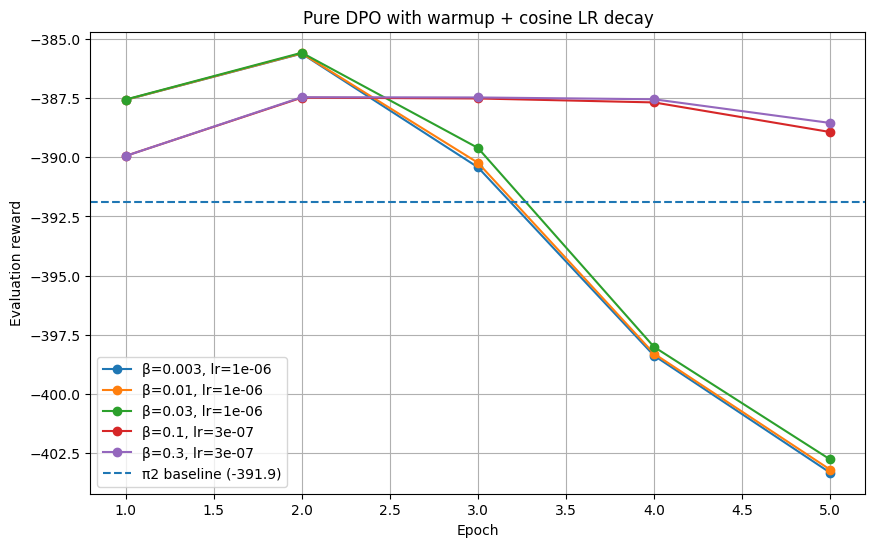

In [32]:
plt.figure(figsize=(10, 6))

for result in scheduler_runs:
    hist = result["history"]
    epochs_arr = np.arange(1, len(hist["reward"]) + 1)
    label = f"β={result['beta']}, lr={result['lr']}"
    plt.plot(epochs_arr, hist["reward"], marker="o", label=label)

plt.axhline(
    scheduler_runs[0]["pi2_mean"],
    linestyle="--",
    label=f"π2 baseline ({scheduler_runs[0]['pi2_mean']:.1f})",
)

plt.xlabel("Epoch")
plt.ylabel("Evaluation reward")
plt.title("Pure DPO with warmup + cosine LR decay")
plt.grid(True)
plt.legend()
plt.show()

In [33]:
final_configs = [
    {"name": "early_stop_best", "beta": 0.03, "lr": 1e-6, "epochs": 2},
    {"name": "stable_final", "beta": 0.3, "lr": 3e-7, "epochs": 5},
]

SEEDS = [0, 1, 2]
final_rows = []

for cfg in final_configs:
    for seed in SEEDS:
        print("\n" + "=" * 80)
        print(cfg["name"], "| seed =", seed)
        print("=" * 80)

        result = run_one_pure_dpo_scheduler_test(
            beta=cfg["beta"],
            lr=cfg["lr"],
            epochs=cfg["epochs"],
            batch_size=16,
            seed=seed,
            eval_episodes=300,
            eval_seed_start=30_000,
        )

        final_rows.append({
            "config": cfg["name"],
            "seed": seed,
            "beta": cfg["beta"],
            "lr": cfg["lr"],
            "epochs": cfg["epochs"],
            "pi2_mean": result["pi2_mean"],
            "dpo_mean": result["dpo_mean"],
            "improvement": result["dpo_mean"] - result["pi2_mean"],
            "best_epoch": result["best_epoch"],
        })

final_df = pd.DataFrame(final_rows)
final_df


early_stop_best | seed = 0
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


Pure DPO epoch 1/2: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 63/63 [00:02<00:00, 23.93it/s]


Epoch 1/2 | loss=0.689450 | reward=-387.26 ± 193.14 | lr=6.16e-07


Pure DPO epoch 2/2: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 63/63 [00:03<00:00, 20.45it/s]


Epoch 2/2 | loss=0.683481 | reward=-384.09 ± 194.12 | lr=5.02e-08
Loaded best epoch: 2, best reward: -384.09
π2 same seeds: -390.41390286649744 194.94155677370088
Best-loaded DPO same seeds: -384.08541254135326 194.1243166233488

early_stop_best | seed = 1
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


...

Pure DPO epoch 4/5: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 63/63 [00:02<00:00, 26.47it/s]


Epoch 4/5 | loss=0.627397 | reward=-387.44 ± 193.13 | lr=4.92e-08


Pure DPO epoch 5/5: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 63/63 [00:02<00:00, 26.49it/s]


Epoch 5/5 | loss=0.622482 | reward=-387.27 ± 193.18 | lr=1.50e-08
Loaded best epoch: 5, best reward: -387.27
π2 same seeds: -390.41390286649744 194.94155677370088
Best-loaded DPO same seeds: -387.27069621451534 193.18362619328167


,config,seed,beta,lr,epochs,pi2_mean,dpo_mean,improvement,best_epoch
0,early_stop_best,0,0.03,1.000000e-06,2,-390.413903,-384.085413,6.328490,2
1,early_stop_best,1,0.03,1.000000e-06,2,-390.413903,-384.085413,6.328490,2
2,early_stop_best,2,0.03,1.000000e-06,2,-390.413903,-384.085413,6.328490,2
3,stable_final,0,0.30,3.000000e-07,5,-390.413903,-387.270696,3.143207,5
4,stable_final,1,0.30,3.000000e-07,5,-390.413903,-387.270696,3.143207,5
5,stable_final,2,0.30,3.000000e-07,5,-390.413903,-387.270696,3.143207,5


In [34]:
final_summary = (
    final_df
    .groupby("config")
    .agg(
        pi2_mean=("pi2_mean", "mean"),
        pi2_std=("pi2_mean", "std"),
        dpo_mean=("dpo_mean", "mean"),
        dpo_std=("dpo_mean", "std"),
        improvement_mean=("improvement", "mean"),
        improvement_std=("improvement", "std"),
    )
    .reset_index()
)

final_summary

,config,pi2_mean,pi2_std,dpo_mean,dpo_std,improvement_mean,improvement_std
0,early_stop_best,-390.413903,0.0,-384.085413,0.0,6.328490,0.0
1,stable_final,-390.413903,0.0,-387.270696,0.0,3.143207,0.0


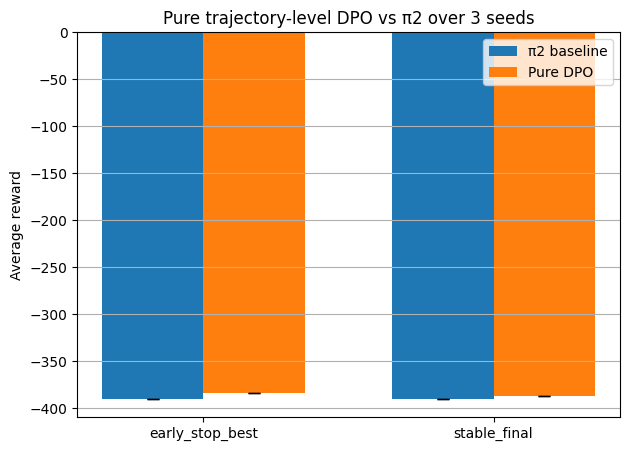

In [35]:
plt.figure(figsize=(7, 5))

x = np.arange(len(final_summary))
width = 0.35

plt.bar(
    x - width / 2,
    final_summary["pi2_mean"],
    width,
    yerr=final_summary["pi2_std"],
    capsize=4,
    label="π2 baseline",
)

plt.bar(
    x + width / 2,
    final_summary["dpo_mean"],
    width,
    yerr=final_summary["dpo_std"],
    capsize=4,
    label="Pure DPO",
)

plt.xticks(x, final_summary["config"])
plt.ylabel("Average reward")
plt.title("Pure trajectory-level DPO vs π2 over 3 seeds")
plt.grid(True, axis="y")
plt.legend()
plt.show()

In [13]:
def get_or_create_prefs_for_seed(seed, K=1000, deterministic_rollouts=False):
    mode = "det" if deterministic_rollouts else "stoch"
    path = f"pure_dpo_prefs_{mode}_K{K}_seed{seed}.pkl"

    if os.path.exists(path):
        print("Loading prefs:", path)
        with open(path, "rb") as f:
            prefs = pickle.load(f)
    else:
        print("Creating prefs:", path)
        set_all_seeds(seed)

        prefs = collect_trajectory_preference_dataset(
            pi1_model,
            pi2_model,
            K=K,
            seed_start=123 + 10_000 * seed,
            deterministic_rollouts=deterministic_rollouts,
        )

        with open(path, "wb") as f:
            pickle.dump(prefs, f)

    return prefs

In [14]:
def run_final_pure_dpo_config(
    cfg,
    seed,
    K=1000,
    deterministic_rollouts=False,
):
    set_all_seeds(seed)

    prefs_seed = get_or_create_prefs_for_seed(
        seed=seed,
        K=K,
        deterministic_rollouts=deterministic_rollouts,
    )

    env_train = gym.make(ENV_NAME)

    policy_model = PPO.load(PI2_PATH, env=env_train, device="cpu")
    ref_model = PPO.load(PI2_PATH, env=env_train, device="cpu")

    trained_model, history = train_pure_trajectory_dpo_with_eval_scheduler(
        policy_model=policy_model,
        ref_model=ref_model,
        prefs=copy.deepcopy(prefs_seed),
        epochs=cfg["epochs"],
        batch_size=16,
        lr=cfg["lr"],
        beta=cfg["beta"],
        eval_episodes=100,
        eval_seed_start=20_000 + 10_000 * seed,  # selection/early stopping
        warmup_frac=0.1,
        min_lr_frac=0.05,
    )

    # final test on different seeds from early-stopping eval
    test_seed_start = 50_000 + 10_000 * seed

    pi2_mean, pi2_std, _ = evaluate_sb3_policy(
        pi2_model,
        episodes=300,
        deterministic=True,
        seed_start=test_seed_start,
    )

    dpo_mean, dpo_std, _ = evaluate_sb3_policy(
        trained_model,
        episodes=300,
        deterministic=True,
        seed_start=test_seed_start,
    )

    env_train.close()

    return {
        "config": cfg["name"],
        "seed": seed,
        "beta": cfg["beta"],
        "lr": cfg["lr"],
        "epochs": cfg["epochs"],
        "pi2_mean": pi2_mean,
        "pi2_std": pi2_std,
        "dpo_mean": dpo_mean,
        "dpo_std": dpo_std,
        "improvement": dpo_mean - pi2_mean,
        "best_epoch": history["best_epoch"],
        "best_reward_during_training": history["best_reward"],
    }

In [39]:
final_summary = (
    final_df
    .groupby("config")
    .agg(
        pi2_mean=("pi2_mean", "mean"),
        pi2_std_across_seeds=("pi2_mean", "std"),
        dpo_mean=("dpo_mean", "mean"),
        dpo_std_across_seeds=("dpo_mean", "std"),
        improvement_mean=("improvement", "mean"),
        improvement_std=("improvement", "std"),
        mean_best_epoch=("best_epoch", "mean"),
    )
    .reset_index()
)

final_summary

,config,pi2_mean,pi2_std_across_seeds,dpo_mean,dpo_std_across_seeds,improvement_mean,improvement_std,mean_best_epoch
0,early_stop_best,-399.571601,4.295536,-390.510022,1.936314,9.061580,2.975061,2.0
1,stable_final,-399.571601,4.295536,-392.702400,2.441115,6.869202,2.415329,3.0


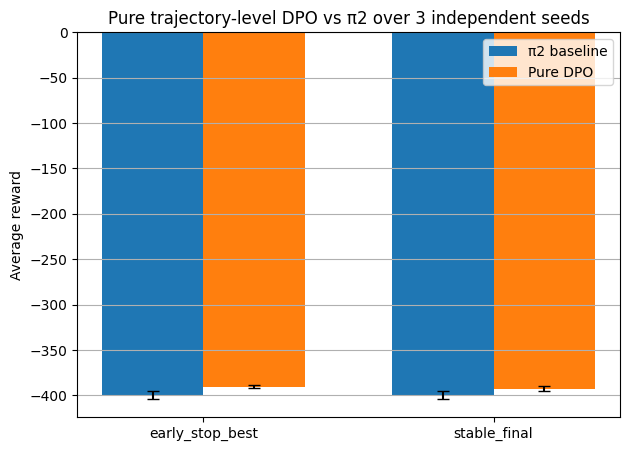

In [40]:
plt.figure(figsize=(7, 5))

x = np.arange(len(final_summary))
width = 0.35

plt.bar(
    x - width / 2,
    final_summary["pi2_mean"],
    width,
    yerr=final_summary["pi2_std_across_seeds"],
    capsize=4,
    label="π2 baseline",
)

plt.bar(
    x + width / 2,
    final_summary["dpo_mean"],
    width,
    yerr=final_summary["dpo_std_across_seeds"],
    capsize=4,
    label="Pure DPO",
)

plt.xticks(x, final_summary["config"])
plt.ylabel("Average reward")
plt.title("Pure trajectory-level DPO vs π2 over 3 independent seeds")
plt.grid(True, axis="y")
plt.legend()
plt.show()

In [43]:
final_configs = [
    {"name": "early_stop_best", "beta": 0.03, "lr": 1e-6, "epochs": 2},
    {"name": "stable_final",    "beta": 0.3,  "lr": 3e-7, "epochs": 5},
]

SEEDS = [0, 1, 2]

final_runs = []
final_rows = []

for cfg in final_configs:
    for seed in SEEDS:
        print("\n" + "=" * 80)
        print(cfg["name"], "| seed =", seed)
        print("=" * 80)

        result = run_one_pure_dpo_scheduler_test(
            beta=cfg["beta"],
            lr=cfg["lr"],
            epochs=cfg["epochs"],
            batch_size=16,
            seed=seed,
            eval_episodes=300,
            eval_seed_start=30_000,
        )

        # save history for plots
        result["config"] = cfg["name"]
        result["seed"] = seed
        final_runs.append(result)

        # save numbers for table
        final_rows.append({
            "config": cfg["name"],
            "seed": seed,
            "beta": cfg["beta"],
            "lr": cfg["lr"],
            "epochs": cfg["epochs"],
            "pi2_mean": result["pi2_mean"],
            "dpo_mean": result["dpo_mean"],
            "improvement": result["dpo_mean"] - result["pi2_mean"],
            "best_epoch": result["best_epoch"],
        })

final_df = pd.DataFrame(final_rows)
final_df


early_stop_best | seed = 0
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


Pure DPO epoch 1/2: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 63/63 [00:02<00:00, 24.51it/s]


Epoch 1/2 | loss=0.689450 | reward=-387.26 ± 193.14 | lr=6.16e-07


Pure DPO epoch 2/2: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 63/63 [00:02<00:00, 27.65it/s]


Epoch 2/2 | loss=0.683481 | reward=-384.09 ± 194.12 | lr=5.02e-08
Loaded best epoch: 2, best reward: -384.09
π2 same seeds: -390.41390286649744 194.94155677370088
Best-loaded DPO same seeds: -384.08541254135326 194.1243166233488

early_stop_best | seed = 1
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


...

Pure DPO epoch 4/5: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 63/63 [00:02<00:00, 22.65it/s]


Epoch 4/5 | loss=0.627397 | reward=-387.44 ± 193.13 | lr=4.92e-08


Pure DPO epoch 5/5: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 63/63 [00:02<00:00, 21.51it/s]


Epoch 5/5 | loss=0.622482 | reward=-387.27 ± 193.18 | lr=1.50e-08
Loaded best epoch: 5, best reward: -387.27
π2 same seeds: -390.41390286649744 194.94155677370088
Best-loaded DPO same seeds: -387.27069621451534 193.18362619328167


,config,seed,beta,lr,epochs,pi2_mean,dpo_mean,improvement,best_epoch
0,early_stop_best,0,0.03,1.000000e-06,2,-390.413903,-384.085413,6.328490,2
1,early_stop_best,1,0.03,1.000000e-06,2,-390.413903,-384.085413,6.328490,2
2,early_stop_best,2,0.03,1.000000e-06,2,-390.413903,-384.085413,6.328490,2
3,stable_final,0,0.30,3.000000e-07,5,-390.413903,-387.270696,3.143207,5
4,stable_final,1,0.30,3.000000e-07,5,-390.413903,-387.270696,3.143207,5
5,stable_final,2,0.30,3.000000e-07,5,-390.413903,-387.270696,3.143207,5


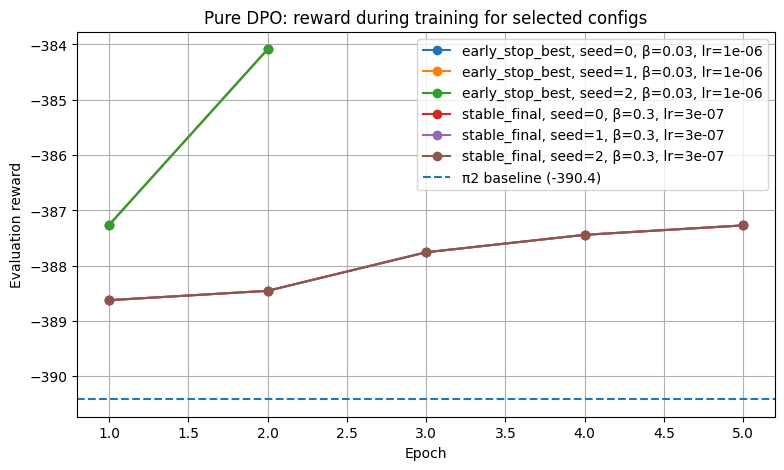

In [44]:
plt.figure(figsize=(9, 5))

for run in final_runs:
    hist = run["history"]
    epochs_arr = np.arange(1, len(hist["reward"]) + 1)

    label = f"{run['config']}, seed={run['seed']}, β={run['beta']}, lr={run['lr']}"
    plt.plot(epochs_arr, hist["reward"], marker="o", label=label)

plt.axhline(
    final_df["pi2_mean"].mean(),
    linestyle="--",
    label=f"π2 baseline ({final_df['pi2_mean'].mean():.1f})",
)

plt.xlabel("Epoch")
plt.ylabel("Evaluation reward")
plt.title("Pure DPO: reward during training for selected configs")
plt.grid(True)
plt.legend()
plt.show()

In [45]:
long_result = run_one_pure_dpo_scheduler_test(
    beta=0.3,
    lr=3e-7,
    epochs=20,
    batch_size=16,
    seed=0,
    eval_episodes=300,
    eval_seed_start=30_000,
)

long_result["best_epoch"], long_result["best_reward_during_training"], long_result["pi2_mean"], long_result["dpo_mean"]

Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


Pure DPO epoch 1/20: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 63/63 [00:02<00:00, 21.39it/s]


Epoch 1/20 | loss=0.690855 | reward=-389.78 ± 194.75 | lr=1.50e-07


Pure DPO epoch 2/20: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 63/63 [00:02<00:00, 21.26it/s]


Epoch 2/20 | loss=0.676252 | reward=-388.16 ± 195.35 | lr=3.00e-07


...

Pure DPO epoch 19/20: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 63/63 [00:02<00:00, 27.33it/s]


Epoch 19/20 | loss=0.472231 | reward=-394.48 ± 183.25 | lr=1.72e-08


Pure DPO epoch 20/20: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 63/63 [00:02<00:00, 27.40it/s]


Epoch 20/20 | loss=0.471557 | reward=-394.59 ± 183.33 | lr=1.50e-08
Loaded best epoch: 7, best reward: -378.87
π2 same seeds: -390.41390286649744 194.94155677370088
Best-loaded DPO same seeds: -378.8670340944765 194.40867191910922


(7, -378.8670340944765, -390.41390286649744, -378.8670340944765)

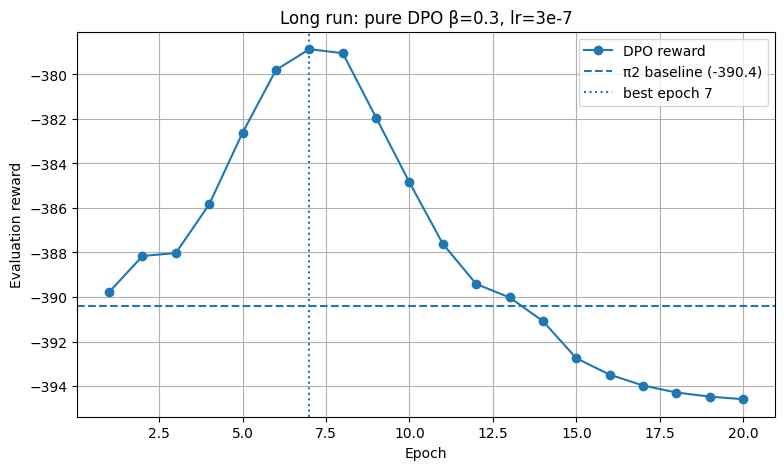

In [46]:
hist = long_result["history"]
epochs_arr = np.arange(1, len(hist["reward"]) + 1)

plt.figure(figsize=(9, 5))
plt.plot(epochs_arr, hist["reward"], marker="o", label="DPO reward")
plt.axhline(
    long_result["pi2_mean"],
    linestyle="--",
    label=f"π2 baseline ({long_result['pi2_mean']:.1f})",
)

plt.axvline(
    long_result["best_epoch"],
    linestyle=":",
    label=f"best epoch {long_result['best_epoch']}",
)

plt.xlabel("Epoch")
plt.ylabel("Evaluation reward")
plt.title("Long run: pure DPO β=0.3, lr=3e-7")
plt.grid(True)
plt.legend()
plt.show()

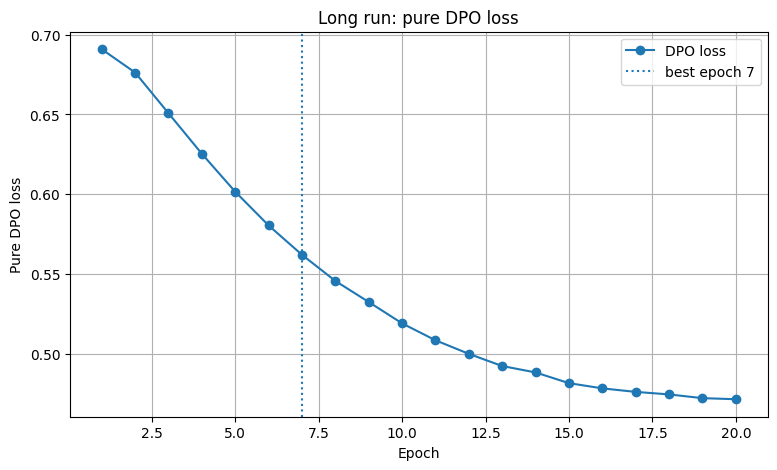

In [47]:
plt.figure(figsize=(9, 5))
plt.plot(epochs_arr, hist["loss"], marker="o", label="DPO loss")
plt.axvline(
    long_result["best_epoch"],
    linestyle=":",
    label=f"best epoch {long_result['best_epoch']}",
)

plt.xlabel("Epoch")
plt.ylabel("Pure DPO loss")
plt.title("Long run: pure DPO loss")
plt.grid(True)
plt.legend()
plt.show()

In [48]:
SAVE_DIR = "saved_pure_dpo_models"
os.makedirs(SAVE_DIR, exist_ok=True)

best_model_path = f"{SAVE_DIR}/pendulum_pure_dpo_beta0p3_lr3e-7_best_epoch7"

long_result["model"].save(best_model_path)

print("Saved model to:", best_model_path + ".zip")
print("Best epoch:", long_result["best_epoch"])
print("Best reward:", long_result["best_reward_during_training"])

Saved model to: saved_pure_dpo_models/pendulum_pure_dpo_beta0p3_lr3e-7_best_epoch7.zip
Best epoch: 7
Best reward: -378.8670340944765


In [15]:
def get_or_create_prefs_for_seed(seed, K=1000, deterministic_rollouts=False):
    mode = "det" if deterministic_rollouts else "stoch"
    path = f"pure_dpo_prefs_{mode}_K{K}_seed{seed}.pkl"

    if os.path.exists(path):
        print("Loading prefs:", path)
        with open(path, "rb") as f:
            prefs = pickle.load(f)
    else:
        print("Creating prefs:", path)
        set_all_seeds(seed)

        prefs = collect_trajectory_preference_dataset(
            pi1_model,
            pi2_model,
            K=K,
            seed_start=123 + 10_000 * seed,
            deterministic_rollouts=deterministic_rollouts,
        )

        with open(path, "wb") as f:
            pickle.dump(prefs, f)

    return prefs
def run_beta_earlystop_pure_dpo(
    beta,
    seed,
    lr=3e-7,
    epochs=20,
    batch_size=16,
    K=1000,
    selection_eval_episodes=50,
    final_eval_episodes=300,
):
    set_all_seeds(seed)

    prefs_seed = get_or_create_prefs_for_seed(
        seed=seed,
        K=K,
        deterministic_rollouts=False,
    )

    env_train = gym.make(ENV_NAME)

    policy_model = PPO.load(PI2_PATH, env=env_train, device="cpu")
    ref_model = PPO.load(PI2_PATH, env=env_train, device="cpu")

    trained_model, history = train_pure_trajectory_dpo_with_eval_scheduler(
        policy_model=policy_model,
        ref_model=ref_model,
        prefs=copy.deepcopy(prefs_seed),
        epochs=epochs,
        batch_size=batch_size,
        lr=lr,
        beta=beta,
        eval_episodes=selection_eval_episodes,
        eval_seed_start=30_000 + 10_000 * seed,
        warmup_frac=0.1,
        min_lr_frac=0.05,
    )

    # Final test on separate seeds from the early-stopping selection
    test_seed_start = 70_000 + 10_000 * seed

    pi2_mean, pi2_std, _ = evaluate_sb3_policy(
        pi2_model,
        episodes=final_eval_episodes,
        deterministic=True,
        seed_start=test_seed_start,
    )

    dpo_mean, dpo_std, _ = evaluate_sb3_policy(
        trained_model,
        episodes=final_eval_episodes,
        deterministic=True,
        seed_start=test_seed_start,
    )

    env_train.close()

    return {
        "beta": beta,
        "lr": lr,
        "epochs": epochs,
        "seed": seed,
        "pi2_mean": pi2_mean,
        "pi2_std": pi2_std,
        "dpo_mean": dpo_mean,
        "dpo_std": dpo_std,
        "improvement": dpo_mean - pi2_mean,
        "best_epoch": history["best_epoch"],
        "best_reward_during_training": history["best_reward"],
        "history": history,
        "model": trained_model,
    }

In [50]:
BETAS = [0.003, 0.01, 0.03, 0.1, 0.3, 1.0]
SEEDS = [0, 1, 2]

beta_runs = []
beta_rows = []

for beta in BETAS:
    for seed in SEEDS:
        print("\n" + "=" * 90)
        print(f"PURE DPO BETA SWEEP | beta={beta} | seed={seed}")
        print("=" * 90)

        result = run_beta_earlystop_pure_dpo(
            beta=beta,
            seed=seed,
            lr=3e-7,
            epochs=20,
            batch_size=16,
            K=1000,
            selection_eval_episodes=50,
            final_eval_episodes=300,
        )

        beta_runs.append(result)

        beta_rows.append({
            "beta": result["beta"],
            "lr": result["lr"],
            "epochs": result["epochs"],
            "seed": result["seed"],
            "pi2_mean": result["pi2_mean"],
            "dpo_mean": result["dpo_mean"],
            "improvement": result["improvement"],
            "best_epoch": result["best_epoch"],
            "best_reward_during_training": result["best_reward_during_training"],
        })

beta_df = pd.DataFrame(beta_rows)
beta_df


PURE DPO BETA SWEEP | beta=0.003 | seed=0
Loading prefs: pure_dpo_prefs_stoch_K1000_seed0.pkl
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


Pure DPO epoch 1/20: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 63/63 [00:02<00:00, 27.29it/s]


Epoch 1/20 | loss=0.693124 | reward=-376.54 ± 162.69 | lr=1.50e-07


Pure DPO epoch 2/20: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 63/63 [00:02<00:00, 27.71it/s]


Epoch 2/20 | loss=0.692973 | reward=-375.90 ± 162.88 | lr=3.00e-07


...

Pure DPO epoch 19/20: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 63/63 [00:02<00:00, 27.14it/s]


Epoch 19/20 | loss=0.289426 | reward=-361.75 ± 121.98 | lr=1.72e-08


Pure DPO epoch 20/20: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 63/63 [00:02<00:00, 27.32it/s]


Epoch 20/20 | loss=0.287288 | reward=-361.67 ± 121.95 | lr=1.50e-08
Loaded best epoch: 4, best reward: -352.29


,beta,lr,epochs,seed,pi2_mean,dpo_mean,improvement,best_epoch,best_reward_during_training
0,0.003,3.000000e-07,20,0,-402.859027,-390.976711,11.882316,7,-360.435865
1,0.003,3.000000e-07,20,1,-399.712031,-393.741524,5.970507,8,-372.814706
2,0.003,3.000000e-07,20,2,-390.783238,-385.325168,5.458070,4,-352.956530
3,0.010,3.000000e-07,20,0,-402.859027,-390.931965,11.927062,7,-360.486036
4,0.010,3.000000e-07,20,1,-399.712031,-393.692440,6.019591,8,-372.762093
5,0.010,3.000000e-07,20,2,-390.783238,-385.337353,5.445885,4,-352.952302
6,0.030,3.000000e-07,20,0,-402.859027,-390.864075,11.994952,7,-360.894365
7,0.030,3.000000e-07,20,1,-399.712031,-393.558594,6.153437,8,-372.621972
8,0.030,3.000000e-07,20,2,-390.783238,-385.371870,5.411367,4,-352.944602
9,0.100,3.000000e-07,20,0,-402.859027,-390.884975,11.974053,7,-362.287711


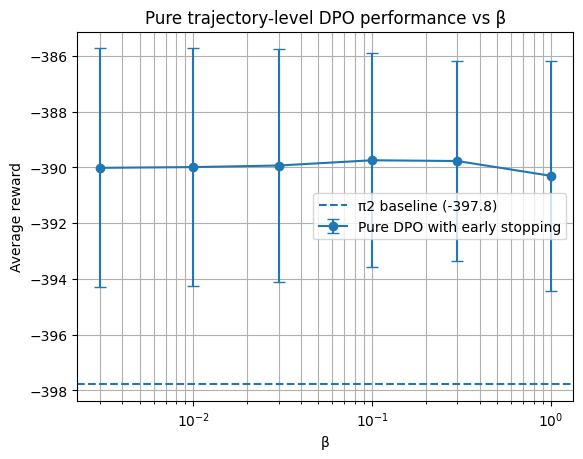

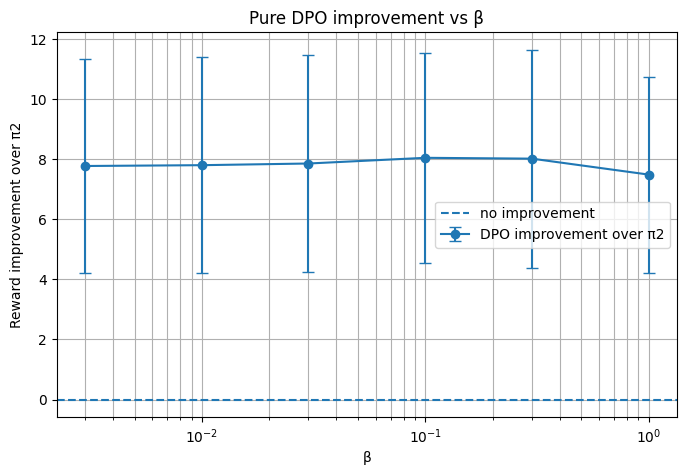

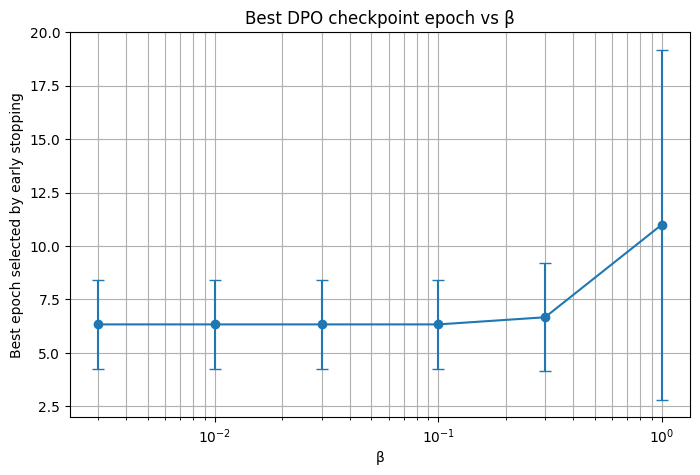

In [56]:
beta_df.to_csv("pure_dpo_beta_sweep_earlystop_3seeds.csv", index=False)


beta_summary = (
    beta_df
    .groupby("beta")
    .agg(
        pi2_mean=("pi2_mean", "mean"),
        pi2_std=("pi2_mean", "std"),
        dpo_mean=("dpo_mean", "mean"),
        dpo_std=("dpo_mean", "std"),
        improvement_mean=("improvement", "mean"),
        improvement_std=("improvement", "std"),
        mean_best_epoch=("best_epoch", "mean"),
        std_best_epoch=("best_epoch", "std"),
    )
    .reset_index()
    .sort_values("beta")
)

beta_summary

plt.errorbar(
    beta_summary["beta"],
    beta_summary["dpo_mean"],
    yerr=beta_summary["dpo_std"],
    marker="o",
    capsize=4,
    label="Pure DPO with early stopping",
)

plt.axhline(
    beta_summary["pi2_mean"].mean(),
    linestyle="--",
    label=f"π2 baseline ({beta_summary['pi2_mean'].mean():.1f})",
)

plt.xscale("log")
plt.xlabel("β")
plt.ylabel("Average reward")
plt.title("Pure trajectory-level DPO performance vs β")
plt.grid(True, which="both")
plt.legend()
plt.show()


beta_summary
plt.figure(figsize=(8, 5))

plt.errorbar(
    beta_summary["beta"],
    beta_summary["improvement_mean"],
    yerr=beta_summary["improvement_std"],
    marker="o",
    capsize=4,
    label="DPO improvement over π2",
)

plt.axhline(0.0, linestyle="--", label="no improvement")

plt.xscale("log")
plt.xlabel("β")
plt.ylabel("Reward improvement over π2")
plt.title("Pure DPO improvement vs β")
plt.grid(True, which="both")
plt.legend()
plt.show()
plt.figure(figsize=(8, 5))

plt.errorbar(
    beta_summary["beta"],
    beta_summary["mean_best_epoch"],
    yerr=beta_summary["std_best_epoch"],
    marker="o",
    capsize=4,
)

plt.xscale("log")
plt.xlabel("β")
plt.ylabel("Best epoch selected by early stopping")
plt.title("Best DPO checkpoint epoch vs β")
plt.grid(True, which="both")
plt.show()


In [57]:
beta_summary = (
    beta_df
    .groupby("beta")
    .agg(
        pi2_mean=("pi2_mean", "mean"),
        dpo_mean=("dpo_mean", "mean"),
        dpo_std=("dpo_mean", "std"),
        improvement_mean=("improvement", "mean"),
        improvement_std=("improvement", "std"),
        mean_best_epoch=("best_epoch", "mean"),
    )
    .reset_index()
    .sort_values("beta")
)

n_seeds = beta_df["seed"].nunique()
beta_summary["dpo_sem"] = beta_summary["dpo_std"] / np.sqrt(n_seeds)

pi2_baseline = beta_summary["pi2_mean"].mean()

# CHANGE THIS if your printed π1 expert value was different
pi1_baseline = -160.0

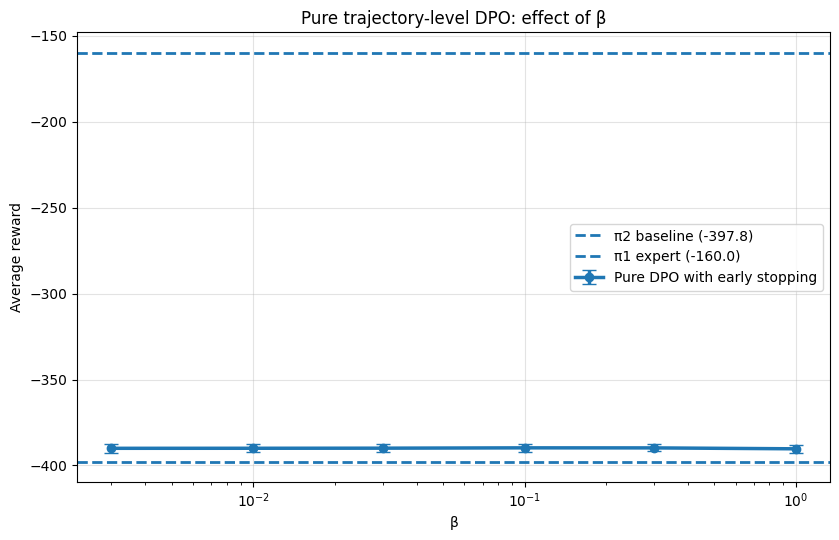

In [58]:
plt.figure(figsize=(8.5, 5.5))

plt.errorbar(
    beta_summary["beta"],
    beta_summary["dpo_mean"],
    yerr=beta_summary["dpo_sem"],
    marker="o",
    linewidth=2.5,
    capsize=5,
    label="Pure DPO with early stopping",
)

plt.axhline(
    pi2_baseline,
    linestyle="--",
    linewidth=2,
    label=f"π2 baseline ({pi2_baseline:.1f})",
)

plt.axhline(
    pi1_baseline,
    linestyle="--",
    linewidth=2,
    label=f"π1 expert ({pi1_baseline:.1f})",
)

plt.xscale("log")
plt.xlabel("β")
plt.ylabel("Average reward")
plt.title("Pure trajectory-level DPO: effect of β")
plt.grid(True, which="major", alpha=0.35)
plt.legend()
plt.tight_layout()
plt.show()

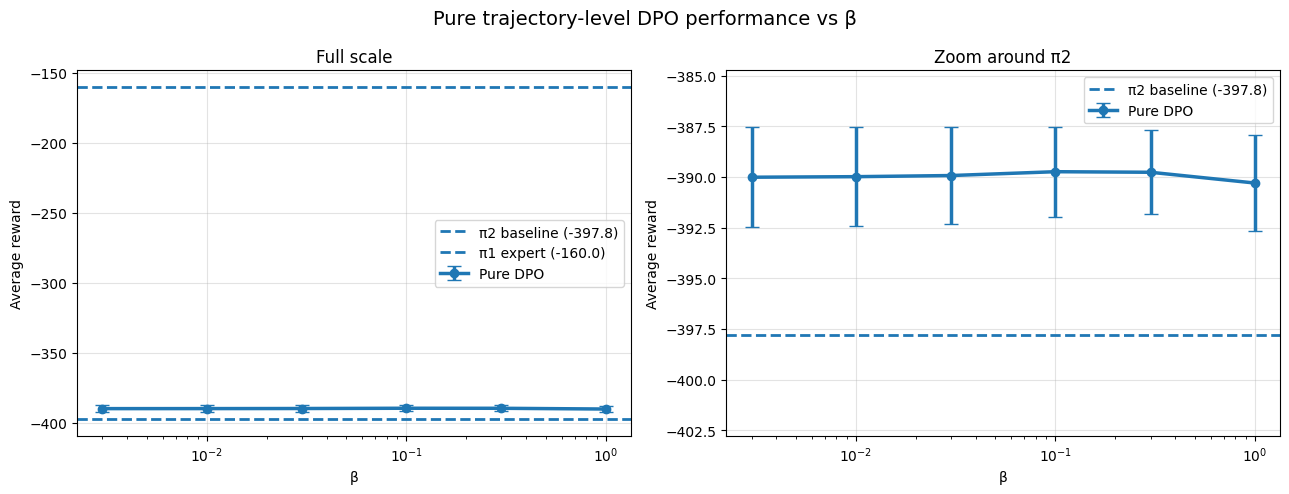

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True)

# Full context plot
axes[0].errorbar(
    beta_summary["beta"],
    beta_summary["dpo_mean"],
    yerr=beta_summary["dpo_sem"],
    marker="o",
    linewidth=2.5,
    capsize=5,
    label="Pure DPO",
)

axes[0].axhline(
    pi2_baseline,
    linestyle="--",
    linewidth=2,
    label=f"π2 baseline ({pi2_baseline:.1f})",
)

axes[0].axhline(
    pi1_baseline,
    linestyle="--",
    linewidth=2,
    label=f"π1 expert ({pi1_baseline:.1f})",
)

axes[0].set_xscale("log")
axes[0].set_xlabel("β")
axes[0].set_ylabel("Average reward")
axes[0].set_title("Full scale")
axes[0].grid(True, which="major", alpha=0.35)
axes[0].legend()


# Zoomed plot around DPO and π2
axes[1].errorbar(
    beta_summary["beta"],
    beta_summary["dpo_mean"],
    yerr=beta_summary["dpo_sem"],
    marker="o",
    linewidth=2.5,
    capsize=5,
    label="Pure DPO",
)

axes[1].axhline(
    pi2_baseline,
    linestyle="--",
    linewidth=2,
    label=f"π2 baseline ({pi2_baseline:.1f})",
)

axes[1].set_xscale("log")
axes[1].set_xlabel("β")
axes[1].set_ylabel("Average reward")
axes[1].set_title("Zoom around π2")
axes[1].grid(True, which="major", alpha=0.35)
axes[1].legend()

# Zoom limits: adjust if needed
y_min = min(beta_summary["dpo_mean"].min(), pi2_baseline) - 5
y_max = max(beta_summary["dpo_mean"].max(), pi2_baseline) + 5
axes[1].set_ylim(y_min, y_max)

fig.suptitle("Pure trajectory-level DPO performance vs β", fontsize=14)
plt.tight_layout()
plt.show()

In [18]:
K_2000 = 2000
SEED = 0

prefs_2000_path = f"pure_dpo_prefs_stoch_K{K_2000}_seed{SEED}.pkl"

if os.path.exists(prefs_2000_path):
    print("Loading prefs:", prefs_2000_path)
    with open(prefs_2000_path, "rb") as f:
        trajectory_prefs_2000 = pickle.load(f)
else:
    print("Creating prefs:", prefs_2000_path)
    set_all_seeds(SEED)

    trajectory_prefs_2000 = collect_trajectory_preference_dataset(
        pi1_model,
        pi2_model,
        K=K_2000,
        seed_start=123 + 10_000 * SEED,
        deterministic_rollouts=False,
    )

    with open(prefs_2000_path, "wb") as f:
        pickle.dump(trajectory_prefs_2000, f)

summarize_preference_dataset(trajectory_prefs_2000)

Loading prefs: pure_dpo_prefs_stoch_K2000_seed0.pkl
Number of pairs: 2000
Winner return mean/std: -160.90125568237644 107.51933513354953
Loser return mean/std: -540.1674081382022 182.13582221129965
π1 return mean/std: -160.97728356654522 107.89936389279833
π2 return mean/std: -540.0913802540333 182.06935622837233
Winner length unique: [200]
Loser length unique: [200]
Fraction winner_return >= loser_return: 1.0
Mean winner-loser return margin: 379.2661524558257


In [19]:
set_all_seeds(0)

env_train = gym.make(ENV_NAME)

policy_model = PPO.load(PI2_PATH, env=env_train, device="cpu")
ref_model = PPO.load(PI2_PATH, env=env_train, device="cpu")

trained_model_2000, history_2000 = train_pure_trajectory_dpo_with_eval_scheduler(
    policy_model=policy_model,
    ref_model=ref_model,
    prefs=copy.deepcopy(trajectory_prefs_2000),
    epochs=20,
    batch_size=16,
    lr=3e-7,
    beta=0.3,
    eval_episodes=300,
    eval_seed_start=30_000,
    warmup_frac=0.1,
    min_lr_frac=0.05,
)

env_train.close()

Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


Pure DPO epoch 1/20: 100%|████████████████████████████████████████████████████████████| 125/125 [00:05<00:00, 22.86it/s]


Epoch 1/20 | loss=0.688091 | reward=-389.33 ± 194.95 | lr=1.50e-07


Pure DPO epoch 2/20: 100%|████████████████████████████████████████████████████████████| 125/125 [00:04<00:00, 26.19it/s]


Epoch 2/20 | loss=0.658977 | reward=-388.05 ± 193.24 | lr=3.00e-07


...

Epoch 18/20 | loss=0.350109 | reward=-428.23 ± 164.67 | lr=2.37e-08


Pure DPO epoch 19/20: 100%|███████████████████████████████████████████████████████████| 125/125 [00:04<00:00, 26.71it/s]


Epoch 19/20 | loss=0.348424 | reward=-428.36 ± 164.72 | lr=1.72e-08


Pure DPO epoch 20/20: 100%|███████████████████████████████████████████████████████████| 125/125 [00:04<00:00, 26.57it/s]


Epoch 20/20 | loss=0.347283 | reward=-427.98 ± 165.30 | lr=1.50e-08
Loaded best epoch: 4, best reward: -379.32


In [16]:
from stable_baselines3 import PPO
import gymnasium as gym

ENV_NAME = "Pendulum-v1"

PI1_PATH = "pendulum_ppo_pi1_final_stronger_minus155"
PI2_PATH = "pendulum_pi2_mid_after_80000_mean_-391"

pi1_model = PPO.load(PI1_PATH, device="cpu")
pi2_model = PPO.load(PI2_PATH, device="cpu")

print("Reloaded π1 and π2.")

Reloaded π1 and π2.


In [23]:
pi2_mean_2000, pi2_std_2000, _ = evaluate_sb3_policy(
    pi2_model,
    episodes=300,
    deterministic=True,
    seed_start=70_000,
)

dpo_mean_2000, dpo_std_2000, _ = evaluate_sb3_policy(
    trained_model_2000,
    episodes=300,
    deterministic=True,
    seed_start=70_000,
)

print("π2 baseline:", pi2_mean_2000, pi2_std_2000)
print("DPO K=2000:", dpo_mean_2000, dpo_std_2000)
print("Improvement:", dpo_mean_2000 - pi2_mean_2000)
print("Best epoch:", history_2000["best_epoch"])
print("Best reward during training:", history_2000["best_reward"])

π2 baseline: -402.8590272629127 195.25502897571167
DPO K=2000: -390.68887909417555 194.33867301329164
Improvement: 12.170148168737171
Best epoch: 4
Best reward during training: -379.32107827569035


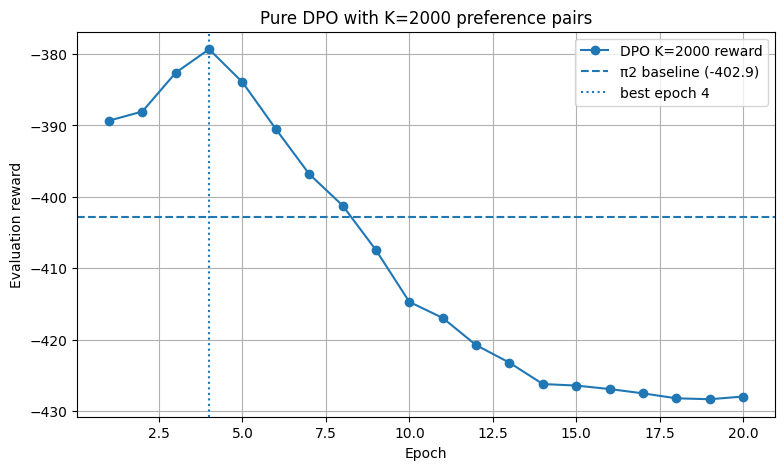

In [24]:
epochs_arr = np.arange(1, len(history_2000["reward"]) + 1)

plt.figure(figsize=(9, 5))

plt.plot(
    epochs_arr,
    history_2000["reward"],
    marker="o",
    label="DPO K=2000 reward",
)

plt.axhline(
    pi2_mean_2000,
    linestyle="--",
    label=f"π2 baseline ({pi2_mean_2000:.1f})",
)

plt.axvline(
    history_2000["best_epoch"],
    linestyle=":",
    label=f"best epoch {history_2000['best_epoch']}",
)

plt.xlabel("Epoch")
plt.ylabel("Evaluation reward")
plt.title("Pure DPO with K=2000 preference pairs")
plt.grid(True)
plt.legend()
plt.show()

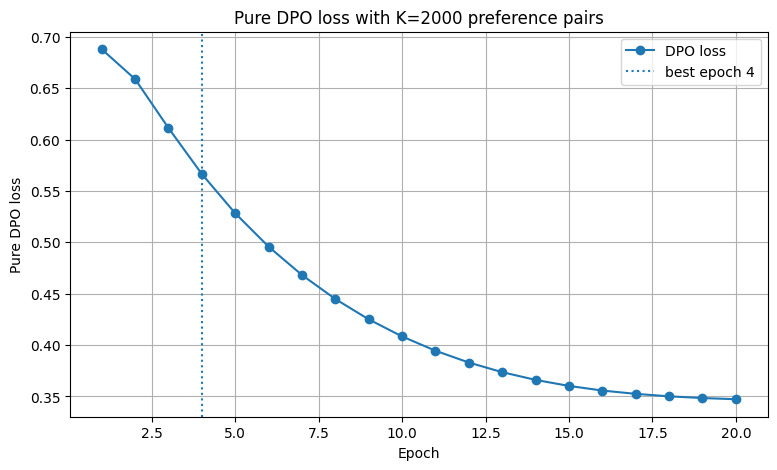

In [25]:
plt.figure(figsize=(9, 5))

plt.plot(
    epochs_arr,
    history_2000["loss"],
    marker="o",
    label="DPO loss",
)

plt.axvline(
    history_2000["best_epoch"],
    linestyle=":",
    label=f"best epoch {history_2000['best_epoch']}",
)

plt.xlabel("Epoch")
plt.ylabel("Pure DPO loss")
plt.title("Pure DPO loss with K=2000 preference pairs")
plt.grid(True)
plt.legend()
plt.show()

In [26]:
SAVE_DIR = "saved_pure_dpo_models"
os.makedirs(SAVE_DIR, exist_ok=True)

trained_model_2000.save(
    f"{SAVE_DIR}/pendulum_pure_dpo_K2000_beta0p3_lr3e-7_best"
)

with open(f"{SAVE_DIR}/pendulum_pure_dpo_K2000_history.pkl", "wb") as f:
    pickle.dump(history_2000, f)

print("Saved K=2000 model and history.")

Saved K=2000 model and history.


In [27]:
K_10000 = 10000
SEED = 0

prefs_10000_path = f"pure_dpo_prefs_stoch_K{K_10000}_seed{SEED}.pkl"

if os.path.exists(prefs_10000_path):
    print("Loading prefs:", prefs_10000_path)
    with open(prefs_10000_path, "rb") as f:
        trajectory_prefs_10000 = pickle.load(f)
else:
    print("Creating prefs:", prefs_10000_path)
    set_all_seeds(SEED)

    trajectory_prefs_10000 = collect_trajectory_preference_dataset(
        pi1_model,
        pi2_model,
        K=K_10000,
        seed_start=123 + 10_000 * SEED,
        deterministic_rollouts=False,
    )

    with open(prefs_10000_path, "wb") as f:
        pickle.dump(trajectory_prefs_10000, f)

summarize_preference_dataset(trajectory_prefs_10000)

Creating prefs: pure_dpo_prefs_stoch_K10000_seed0.pkl


Number of pairs: 10000
Winner return mean/std: -159.0796558513776 103.38502114330387
Loser return mean/std: -537.5896830979369 176.59555897828514
π1 return mean/std: -159.20236063331174 104.10183014317622
π2 return mean/std: -537.4669783160026 176.4373057952173
Winner length unique: [200]
Loser length unique: [200]
Fraction winner_return >= loser_return: 0.9999
Mean winner-loser return margin: 378.5100272465593


In [28]:
set_all_seeds(0)

env_train = gym.make(ENV_NAME)

policy_model = PPO.load(PI2_PATH, env=env_train, device="cpu")
ref_model = PPO.load(PI2_PATH, env=env_train, device="cpu")

trained_model_10000, history_10000 = train_pure_trajectory_dpo_with_eval_scheduler(
    policy_model=policy_model,
    ref_model=ref_model,
    prefs=copy.deepcopy(trajectory_prefs_10000),
    epochs=20,
    batch_size=16,
    lr=3e-7,
    beta=0.3,
    eval_episodes=100,      # keep this 100 during training, otherwise it is slow
    eval_seed_start=30_000,
    warmup_frac=0.1,
    min_lr_frac=0.05,
)

env_train.close()

Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


Pure DPO epoch 1/20: 100%|████████████████████████████████████████████████████████████| 625/625 [00:23<00:00, 26.05it/s]


Epoch 1/20 | loss=0.669212 | reward=-424.54 ± 198.33 | lr=1.50e-07


Pure DPO epoch 2/20: 100%|████████████████████████████████████████████████████████████| 625/625 [00:23<00:00, 26.30it/s]


Epoch 2/20 | loss=0.553773 | reward=-423.16 ± 183.43 | lr=3.00e-07


...

Epoch 18/20 | loss=0.067241 | reward=-644.94 ± 236.35 | lr=2.36e-08


Pure DPO epoch 19/20: 100%|███████████████████████████████████████████████████████████| 625/625 [00:23<00:00, 26.10it/s]


Epoch 19/20 | loss=0.066134 | reward=-648.21 ± 234.64 | lr=1.72e-08


Pure DPO epoch 20/20: 100%|███████████████████████████████████████████████████████████| 625/625 [00:24<00:00, 25.55it/s]


Epoch 20/20 | loss=0.065379 | reward=-649.64 ± 235.57 | lr=1.50e-08
Loaded best epoch: 2, best reward: -423.16


In [29]:
pi2_mean_10000, pi2_std_10000, _ = evaluate_sb3_policy(
    pi2_model,
    episodes=300,
    deterministic=True,
    seed_start=70_000,
)

dpo_mean_10000, dpo_std_10000, _ = evaluate_sb3_policy(
    trained_model_10000,
    episodes=300,
    deterministic=True,
    seed_start=70_000,
)

print("π2 baseline:", pi2_mean_10000, pi2_std_10000)
print("DPO K=10000:", dpo_mean_10000, dpo_std_10000)
print("Improvement:", dpo_mean_10000 - pi2_mean_10000)
print("Best epoch:", history_10000["best_epoch"])
print("Best reward during training:", history_10000["best_reward"])

π2 baseline: -402.8590272629127 195.25502897571167
DPO K=10000: -410.71270188971454 179.70680221787018
Improvement: -7.853674626801819
Best epoch: 2
Best reward during training: -423.16433935416774


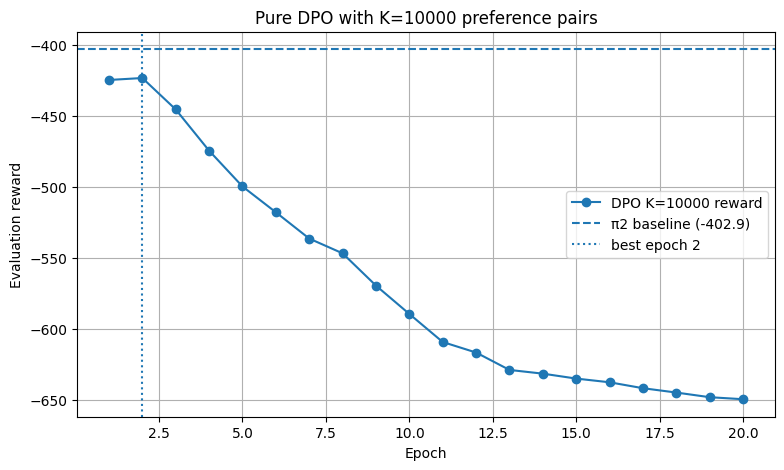

In [30]:
epochs_arr = np.arange(1, len(history_10000["reward"]) + 1)

plt.figure(figsize=(9, 5))

plt.plot(
    epochs_arr,
    history_10000["reward"],
    marker="o",
    label="DPO K=10000 reward",
)

plt.axhline(
    pi2_mean_10000,
    linestyle="--",
    label=f"π2 baseline ({pi2_mean_10000:.1f})",
)

plt.axvline(
    history_10000["best_epoch"],
    linestyle=":",
    label=f"best epoch {history_10000['best_epoch']}",
)

plt.xlabel("Epoch")
plt.ylabel("Evaluation reward")
plt.title("Pure DPO with K=10000 preference pairs")
plt.grid(True)
plt.legend()
plt.show()

In [17]:
def train_pure_dpo_fixed_updates_with_eval(
    policy_model,
    ref_model,
    prefs,
    max_updates=600,
    batch_size=16,
    lr=3e-7,
    beta=0.3,
    eval_every=50,
    eval_episodes=100,
    eval_seed_start=30_000,
    warmup_frac=0.1,
    min_lr_frac=0.05,
):
    import math
    import copy
    import random

    policy_model.policy.train()
    ref_model.policy.eval()

    for p in ref_model.policy.parameters():
        p.requires_grad = False

    for p in policy_model.policy.parameters():
        p.requires_grad = True

    optimizer = torch.optim.Adam(policy_model.policy.parameters(), lr=lr)

    warmup_steps = max(1, int(warmup_frac * max_updates))

    def get_lr(step):
        if step < warmup_steps:
            return lr * (step + 1) / warmup_steps

        progress = (step - warmup_steps) / max(1, max_updates - warmup_steps)
        cosine = 0.5 * (1.0 + math.cos(math.pi * progress))
        min_lr = min_lr_frac * lr
        return min_lr + (lr - min_lr) * cosine

    losses = []
    rewards = []
    reward_stds = []
    update_steps = []
    lrs = []

    best_reward = -float("inf")
    best_step = None
    best_state_dict = None

    n = len(prefs)

    for step in range(max_updates):
        current_lr = get_lr(step)
        for group in optimizer.param_groups:
            group["lr"] = current_lr

        batch = random.sample(prefs, batch_size)

        loss = pure_trajectory_dpo_batch_loss(
            policy_model,
            ref_model,
            batch,
            beta=beta,
        )

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if (step + 1) % eval_every == 0 or step == 0:
            mean_reward, std_reward, _ = evaluate_sb3_policy(
                policy_model,
                episodes=eval_episodes,
                deterministic=True,
                seed_start=eval_seed_start,
            )

            losses.append(float(loss.item()))
            rewards.append(mean_reward)
            reward_stds.append(std_reward)
            update_steps.append(step + 1)
            lrs.append(current_lr)

            if mean_reward > best_reward:
                best_reward = mean_reward
                best_step = step + 1
                best_state_dict = copy.deepcopy(policy_model.policy.state_dict())

            print(
                f"Update {step+1}/{max_updates} | "
                f"loss={loss.item():.6f} | "
                f"reward={mean_reward:.2f} ± {std_reward:.2f} | "
                f"lr={current_lr:.2e}"
            )

    if best_state_dict is not None:
        policy_model.policy.load_state_dict(best_state_dict)

    print(f"Loaded best update: {best_step}, best reward: {best_reward:.2f}")

    return policy_model, {
        "loss": losses,
        "reward": rewards,
        "reward_std": reward_stds,
        "update_steps": update_steps,
        "lr": lrs,
        "best_step": best_step,
        "best_reward": best_reward,
    }

In [32]:
set_all_seeds(0)

env_train = gym.make(ENV_NAME)

policy_model = PPO.load(PI2_PATH, env=env_train, device="cpu")
ref_model = PPO.load(PI2_PATH, env=env_train, device="cpu")

trained_model_10000_steps, history_10000_steps = train_pure_dpo_fixed_updates_with_eval(
    policy_model=policy_model,
    ref_model=ref_model,
    prefs=copy.deepcopy(trajectory_prefs_10000),
    max_updates=600,
    batch_size=16,
    lr=3e-7,
    beta=0.3,
    eval_every=50,
    eval_episodes=100,
    eval_seed_start=30_000,
)

env_train.close()

Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Update 1/600 | loss=0.693147 | reward=-429.36 ± 199.97 | lr=5.00e-09
Update 50/600 | loss=0.683384 | reward=-427.51 ± 199.77 | lr=2.50e-07
Update 100/600 | loss=0.664352 | reward=-424.56 ± 201.26 | lr=2.96e-07
Update 150/600 | loss=0.650028 | reward=-425.11 ± 198.53 | lr=2.81e-07
Update 200/600 | loss=0.640561 | reward=-424.40 ± 198.26 | lr=2.56e-07
Update 250/600 | loss=0.614507 | reward=-422.22 ± 198.05 | lr=2.22e-07
Update 300/600 | loss=0.630884 | reward=-421.12 ± 198.32 | lr=1.83e-07
Update 350/600 | loss=0.570362 | reward=-419.71 ± 198.19 | lr=1.42e-07
Update 400/600 | loss=0.583173 | reward=-418.09 ± 198.05 | lr=1.02e-07
Update 450/600 | loss=0.557316 | reward=-417.67 ± 198.14 | lr=6.65e-08
Update 500/600 | loss=0.552222 | reward=-417.39 ± 198.11 | lr=3.89e-08
Update 550/600 | loss=0.589682 | reward=-417.20 ± 198.05 | lr=2.12e-

In [33]:
pi2_same_10000_train_mean, pi2_same_10000_train_std, _ = evaluate_sb3_policy(
    pi2_model,
    episodes=100,
    deterministic=True,
    seed_start=30_000,
)

print("π2 baseline on same training-eval seeds:",
      pi2_same_10000_train_mean,
      pi2_same_10000_train_std)

π2 baseline on same training-eval seeds: -429.3601156317017 199.96937634583804


In [34]:
pi2_mean_10000_steps, pi2_std_10000_steps, _ = evaluate_sb3_policy(
    pi2_model,
    episodes=300,
    deterministic=True,
    seed_start=70_000,
)

dpo_mean_10000_steps, dpo_std_10000_steps, _ = evaluate_sb3_policy(
    trained_model_10000_steps,
    episodes=300,
    deterministic=True,
    seed_start=70_000,
)

print("π2 baseline:", pi2_mean_10000_steps, pi2_std_10000_steps)
print("DPO K=10000 fixed updates:", dpo_mean_10000_steps, dpo_std_10000_steps)
print("Improvement:", dpo_mean_10000_steps - pi2_mean_10000_steps)
print("Best update:", history_10000_steps["best_step"])
print("Best reward during training:", history_10000_steps["best_reward"])

π2 baseline: -402.8590272629127 195.25502897571167
DPO K=10000 fixed updates: -391.7552427853088 194.94935604551404
Improvement: 11.103784477603938
Best update: 600
Best reward during training: -417.03741334259826


In [35]:
set_all_seeds(0)

env_train = gym.make(ENV_NAME)

policy_model = PPO.load(PI2_PATH, env=env_train, device="cpu")
ref_model = PPO.load(PI2_PATH, env=env_train, device="cpu")

trained_model_10000_steps_long, history_10000_steps_long = train_pure_dpo_fixed_updates_with_eval(
    policy_model=policy_model,
    ref_model=ref_model,
    prefs=copy.deepcopy(trajectory_prefs_10000),
    max_updates=1500,
    batch_size=16,
    lr=3e-7,
    beta=0.3,
    eval_every=100,
    eval_episodes=100,
    eval_seed_start=30_000,
)

env_train.close()

Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Update 1/1500 | loss=0.693147 | reward=-429.36 ± 199.97 | lr=2.00e-09
Update 100/1500 | loss=0.679188 | reward=-426.75 ± 200.48 | lr=2.00e-07
Update 200/1500 | loss=0.652467 | reward=-425.15 ± 198.46 | lr=2.99e-07
Update 300/1500 | loss=0.634778 | reward=-421.79 ± 198.15 | lr=2.92e-07
Update 400/1500 | loss=0.573186 | reward=-417.12 ± 197.99 | lr=2.77e-07
Update 500/1500 | loss=0.517345 | reward=-415.76 ± 194.74 | lr=2.56e-07
Update 600/1500 | loss=0.537914 | reward=-420.01 ± 186.52 | lr=2.29e-07
Update 700/1500 | loss=0.473878 | reward=-419.59 ± 183.55 | lr=1.99e-07
Update 800/1500 | loss=0.494701 | reward=-423.61 ± 183.19 | lr=1.66e-07
Update 900/1500 | loss=0.482606 | reward=-427.54 ± 183.47 | lr=1.33e-07
Update 1000/1500 | loss=0.498997 | reward=-429.05 ± 183.57 | lr=1.01e-07
Update 1100/1500 | loss=0.487353 | reward=-429.90 ± 183

In [21]:
pi2_same_mean, pi2_same_std, _ = evaluate_sb3_policy(
    pi2_model,
    episodes=100,
    deterministic=True,
    seed_start=30_000,
)

print("π2 baseline on same eval seeds:", pi2_same_mean, pi2_same_std)

π2 baseline on same eval seeds: -429.3601156317017 199.96937634583804


In [37]:
k10000_configs = [
    {"beta": 0.03, "lr": 3e-8},
    {"beta": 0.03, "lr": 1e-7},
    {"beta": 0.03, "lr": 3e-7},

    {"beta": 0.1, "lr": 3e-8},
    {"beta": 0.1, "lr": 1e-7},
    {"beta": 0.1, "lr": 3e-7},

    {"beta": 0.3, "lr": 3e-8},
    {"beta": 0.3, "lr": 1e-7},
    {"beta": 0.3, "lr": 3e-7},

    {"beta": 1.0, "lr": 3e-8},
    {"beta": 1.0, "lr": 1e-7},
]

k10000_runs = []
k10000_rows = []

for cfg in k10000_configs:
    print("\n" + "=" * 90)
    print("K=10000 CONFIG:", cfg)
    print("=" * 90)

    set_all_seeds(0)

    env_train = gym.make(ENV_NAME)

    policy_model = PPO.load(PI2_PATH, env=env_train, device="cpu")
    ref_model = PPO.load(PI2_PATH, env=env_train, device="cpu")

    model_cfg, hist_cfg = train_pure_dpo_fixed_updates_with_eval(
        policy_model=policy_model,
        ref_model=ref_model,
        prefs=copy.deepcopy(trajectory_prefs_10000),
        max_updates=1500,
        batch_size=16,
        lr=cfg["lr"],
        beta=cfg["beta"],
        eval_every=100,
        eval_episodes=100,
        eval_seed_start=30_000,
    )

    env_train.close()

    k10000_runs.append({
        "beta": cfg["beta"],
        "lr": cfg["lr"],
        "model": model_cfg,
        "history": hist_cfg,
    })

    k10000_rows.append({
        "beta": cfg["beta"],
        "lr": cfg["lr"],
        "best_step": hist_cfg["best_step"],
        "best_reward": hist_cfg["best_reward"],
        "improvement_same_eval": hist_cfg["best_reward"] - pi2_same_mean,
        "final_logged_reward": hist_cfg["reward"][-1],
    })

k10000_sweep_df = pd.DataFrame(k10000_rows)
k10000_sweep_df.sort_values("best_reward", ascending=False)


K=10000 CONFIG: {'beta': 0.03, 'lr': 3e-08}
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Update 1/1500 | loss=0.693147 | reward=-429.36 ± 199.97 | lr=2.00e-10
Update 100/1500 | loss=0.693017 | reward=-429.24 ± 199.91 | lr=2.00e-08
Update 200/1500 | loss=0.692717 | reward=-428.24 ± 199.59 | lr=2.99e-08
Update 300/1500 | loss=0.692505 | reward=-427.49 ± 199.77 | lr=2.92e-08
Update 400/1500 | loss=0.691718 | reward=-426.95 ± 200.29 | lr=2.77e-08
Update 500/1500 | loss=0.690902 | reward=-426.17 ± 200.69 | lr=2.56e-08
Update 600/1500 | loss=0.691157 | reward=-425.00 ± 201.32 | lr=2.29e-08
Update 700/1500 | loss=0.690222 | reward=-424.85 ± 201.34 | lr=1.99e-08
Update 800/1500 | loss=0.690420 | reward=-424.75 ± 201.30 | lr=1.66e-08
Update 900/1500 | loss=0.690153 | reward=-424.70 ± 201.23 | lr=1.33e-08
Update 1000/1500 | loss=0.690497 | reward=-424.66 ± 201.21 | lr=1.01e-08
Update 110

,beta,lr,best_step,best_reward,improvement_same_eval,final_logged_reward
8,0.30,3.000000e-07,500,-415.756675,13.603441,-430.589835
5,0.10,3.000000e-07,400,-417.205427,12.154689,-435.161329
2,0.03,3.000000e-07,400,-417.304877,12.055238,-437.829770
1,0.03,1.000000e-07,1500,-419.370388,9.989727,-419.370388
4,0.10,1.000000e-07,1500,-419.505806,9.854310,-419.505806
10,1.00,1.000000e-07,1500,-419.786114,9.574002,-419.786114
7,0.30,1.000000e-07,1500,-419.993319,9.366796,-419.993319
9,1.00,3.000000e-08,1500,-424.543268,4.816848,-424.543268
6,0.30,3.000000e-08,1500,-424.573931,4.786184,-424.573931
3,0.10,3.000000e-08,1500,-424.587100,4.773015,-424.587100


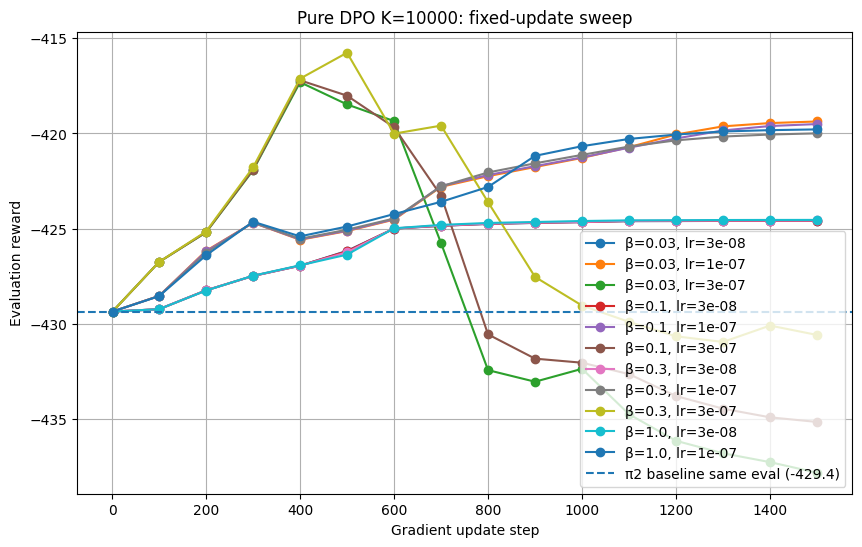

In [38]:
plt.figure(figsize=(10, 6))

for run in k10000_runs:
    hist = run["history"]

    label = f"β={run['beta']}, lr={run['lr']}"
    plt.plot(
        hist["update_steps"],
        hist["reward"],
        marker="o",
        label=label,
    )

plt.axhline(
    pi2_same_mean,
    linestyle="--",
    label=f"π2 baseline same eval ({pi2_same_mean:.1f})",
)

plt.xlabel("Gradient update step")
plt.ylabel("Evaluation reward")
plt.title("Pure DPO K=10000: fixed-update sweep")
plt.grid(True)
plt.legend()
plt.show()

In [18]:
K_10000 = 10000
SEED = 0

prefs_10000_det_path = f"pure_dpo_prefs_DET_K{K_10000}_seed{SEED}.pkl"

if os.path.exists(prefs_10000_det_path):
    print("Loading prefs:", prefs_10000_det_path)
    with open(prefs_10000_det_path, "rb") as f:
        trajectory_prefs_10000_det = pickle.load(f)
else:
    print("Creating deterministic prefs:", prefs_10000_det_path)
    set_all_seeds(SEED)

    trajectory_prefs_10000_det = collect_trajectory_preference_dataset(
        pi1_model,
        pi2_model,
        K=K_10000,
        seed_start=123,
        deterministic_rollouts=True,
    )

    with open(prefs_10000_det_path, "wb") as f:
        pickle.dump(trajectory_prefs_10000_det, f)

summarize_preference_dataset(trajectory_prefs_10000_det)

Loading prefs: pure_dpo_prefs_DET_K10000_seed0.pkl
Number of pairs: 10000
Winner return mean/std: -158.0798705127161 102.06182757143313
Loser return mean/std: -404.372605197663 189.57808568952342
π1 return mean/std: -160.38670493809553 119.06378163635975
π2 return mean/std: -402.0657707722836 182.4991870431931
Winner length unique: [200]
Loser length unique: [200]
Fraction winner_return >= loser_return: 0.9999
Mean winner-loser return margin: 246.2927346849469


In [19]:
set_all_seeds(0)

env_train = gym.make(ENV_NAME)

policy_model = PPO.load(PI2_PATH, env=env_train, device="cpu")
ref_model = PPO.load(PI2_PATH, env=env_train, device="cpu")

trained_model_10000_det, history_10000_det = train_pure_dpo_fixed_updates_with_eval(
    policy_model=policy_model,
    ref_model=ref_model,
    prefs=copy.deepcopy(trajectory_prefs_10000_det),
    max_updates=1500,
    batch_size=16,
    lr=3e-7,
    beta=0.3,
    eval_every=100,
    eval_episodes=100,
    eval_seed_start=30_000,
)

env_train.close()

Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Update 1/1500 | loss=0.693147 | reward=-429.36 ± 199.97 | lr=2.00e-09
Update 100/1500 | loss=0.679053 | reward=-426.70 ± 200.55 | lr=2.00e-07
Update 200/1500 | loss=0.650576 | reward=-425.11 ± 198.57 | lr=2.99e-07
Update 300/1500 | loss=0.631399 | reward=-421.46 ± 198.40 | lr=2.92e-07
Update 400/1500 | loss=0.570856 | reward=-416.76 ± 198.11 | lr=2.77e-07
Update 500/1500 | loss=0.509494 | reward=-415.86 ± 194.71 | lr=2.56e-07
Update 600/1500 | loss=0.521183 | reward=-420.02 ± 186.76 | lr=2.29e-07
Update 700/1500 | loss=0.483078 | reward=-419.39 ± 184.03 | lr=1.99e-07
Update 800/1500 | loss=0.491140 | reward=-422.99 ± 183.88 | lr=1.66e-07
Update 900/1500 | loss=0.486043 | reward=-426.35 ± 184.28 | lr=1.33e-07
Update 1000/1500 | loss=0.510927 | reward=-427.90 ± 184.62 | lr=1.01e-07
Update 1100/1500 | loss=0.475358 | reward=-428.53 ± 184

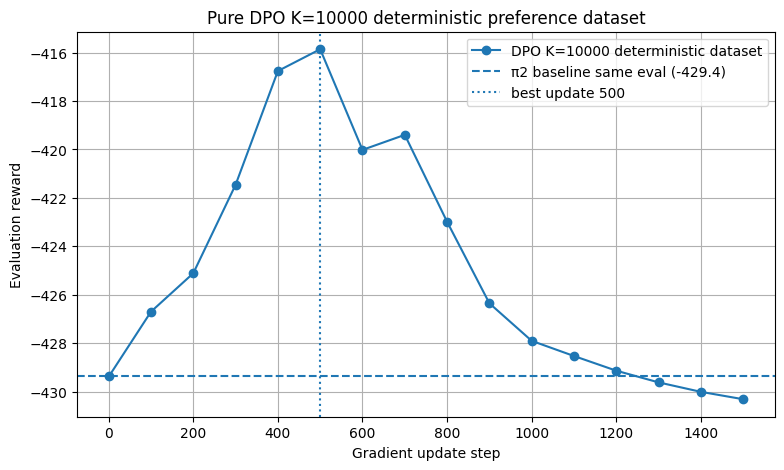

In [22]:
plt.figure(figsize=(9, 5))

plt.plot(
    history_10000_det["update_steps"],
    history_10000_det["reward"],
    marker="o",
    label="DPO K=10000 deterministic dataset",
)

plt.axhline(
    pi2_same_mean,
    linestyle="--",
    label=f"π2 baseline same eval ({pi2_same_mean:.1f})",
)

plt.axvline(
    history_10000_det["best_step"],
    linestyle=":",
    label=f"best update {history_10000_det['best_step']}",
)

plt.xlabel("Gradient update step")
plt.ylabel("Evaluation reward")
plt.title("Pure DPO K=10000 deterministic preference dataset")
plt.grid(True)
plt.legend()
plt.show()

In [25]:
import os, pickle, copy
import pandas as pd
import numpy as np
import gymnasium as gym
from stable_baselines3 import PPO

# Make sure models are loaded
pi1_model = PPO.load(PI1_PATH, device="cpu")
pi2_model = PPO.load(PI2_PATH, device="cpu")

# Load existing K=10000 preference dataset
K_10000 = 10000
SEED = 0

prefs_path = f"pure_dpo_prefs_stoch_K{K_10000}_seed{SEED}.pkl"

with open(prefs_path, "rb") as f:
    trajectory_prefs_10000 = pickle.load(f)

print("Loaded:", prefs_path)
print("Number of pairs:", len(trajectory_prefs_10000))

# Baseline on the same eval seeds used during sweep
pi2_same_mean, pi2_same_std, _ = evaluate_sb3_policy(
    pi2_model,
    episodes=100,
    deterministic=True,
    seed_start=30_000,
)

print("π2 baseline same eval:", pi2_same_mean, pi2_same_std)

Loaded: pure_dpo_prefs_stoch_K10000_seed0.pkl
Number of pairs: 10000
π2 baseline same eval: -429.3601156317017 199.96937634583804


In [26]:
k10000_configs = [
    {"beta": 0.03, "lr": 3e-7},
    {"beta": 0.1,  "lr": 3e-7},
    {"beta": 0.3,  "lr": 3e-7},
    {"beta": 1.0,  "lr": 1e-7},
]

csv_path = "pure_dpo_K10000_fixed_update_sweep_seed0.csv"

# If partially saved before, continue from it
if os.path.exists(csv_path):
    k10000_sweep_df = pd.read_csv(csv_path)
    done_pairs = set(zip(k10000_sweep_df["beta"], k10000_sweep_df["lr"]))
    k10000_rows = k10000_sweep_df.to_dict("records")
    print("Loaded existing partial CSV:", csv_path)
else:
    done_pairs = set()
    k10000_rows = []

k10000_runs = []

for cfg in k10000_configs:
    beta = cfg["beta"]
    lr = cfg["lr"]

    if (beta, lr) in done_pairs:
        print(f"Skipping already done beta={beta}, lr={lr}")
        continue

    print("\n" + "=" * 90)
    print(f"K=10000 SWEEP | beta={beta} | lr={lr}")
    print("=" * 90)

    set_all_seeds(0)

    env_train = gym.make(ENV_NAME)

    policy_model = PPO.load(PI2_PATH, env=env_train, device="cpu")
    ref_model = PPO.load(PI2_PATH, env=env_train, device="cpu")

    model_cfg, hist_cfg = train_pure_dpo_fixed_updates_with_eval(
        policy_model=policy_model,
        ref_model=ref_model,
        prefs=copy.deepcopy(trajectory_prefs_10000),
        max_updates=1500,
        batch_size=16,
        lr=lr,
        beta=beta,
        eval_every=100,
        eval_episodes=100,
        eval_seed_start=30_000,
    )

    env_train.close()

    row = {
        "beta": beta,
        "lr": lr,
        "best_step": hist_cfg["best_step"],
        "best_reward": hist_cfg["best_reward"],
        "improvement_same_eval": hist_cfg["best_reward"] - pi2_same_mean,
        "final_logged_reward": hist_cfg["reward"][-1],
    }

    k10000_rows.append(row)

    k10000_runs.append({
        "beta": beta,
        "lr": lr,
        "history": hist_cfg,
    })

    # Save after every run
    k10000_sweep_df = pd.DataFrame(k10000_rows)
    k10000_sweep_df.to_csv(csv_path, index=False)

    print("Saved partial sweep to:", csv_path)

k10000_sweep_df = pd.DataFrame(k10000_rows)
k10000_sweep_df.sort_values("best_reward", ascending=False)


K=10000 SWEEP | beta=0.03 | lr=3e-07
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Update 1/1500 | loss=0.693147 | reward=-429.36 ± 199.97 | lr=2.00e-09
Update 100/1500 | loss=0.691728 | reward=-426.76 ± 200.48 | lr=2.00e-07
Update 200/1500 | loss=0.688848 | reward=-425.20 ± 198.43 | lr=2.99e-07
Update 300/1500 | loss=0.686811 | reward=-421.94 ± 198.03 | lr=2.92e-07
Update 400/1500 | loss=0.679070 | reward=-417.30 ± 197.36 | lr=2.77e-07
Update 500/1500 | loss=0.671165 | reward=-418.47 ± 190.88 | lr=2.56e-07
Update 600/1500 | loss=0.673725 | reward=-419.35 ± 185.64 | lr=2.29e-07
Update 700/1500 | loss=0.664332 | reward=-425.76 ± 181.57 | lr=1.99e-07
Update 800/1500 | loss=0.666382 | reward=-432.44 ± 179.29 | lr=1.66e-07
Update 900/1500 | loss=0.663715 | reward=-433.05 ± 178.74 | lr=1.33e-07
Update 1000/1500 | loss=0.666416 | reward=-432.37 ± 177.93 | lr=1.01e-07
Update 1100/1500 

,beta,lr,best_step,best_reward,improvement_same_eval,final_logged_reward
2,0.30,3.000000e-07,500,-415.756675,13.603441,-430.589835
1,0.10,3.000000e-07,400,-417.205427,12.154689,-435.161329
0,0.03,3.000000e-07,400,-417.304877,12.055238,-437.829770
3,1.00,1.000000e-07,1500,-419.786114,9.574002,-419.786114


In [27]:
k10000_best_by_beta = (
    k10000_sweep_df
    .sort_values("best_reward", ascending=False)
    .groupby("beta", as_index=False)
    .first()
    .sort_values("beta")
)

k10000_best_by_beta.to_csv("pure_dpo_K10000_best_by_beta_seed0.csv", index=False)
k10000_best_by_beta

,beta,lr,best_step,best_reward,improvement_same_eval,final_logged_reward
0,0.03,3.000000e-07,400,-417.304877,12.055238,-437.829770
1,0.10,3.000000e-07,400,-417.205427,12.154689,-435.161329
2,0.30,3.000000e-07,500,-415.756675,13.603441,-430.589835
3,1.00,1.000000e-07,1500,-419.786114,9.574002,-419.786114


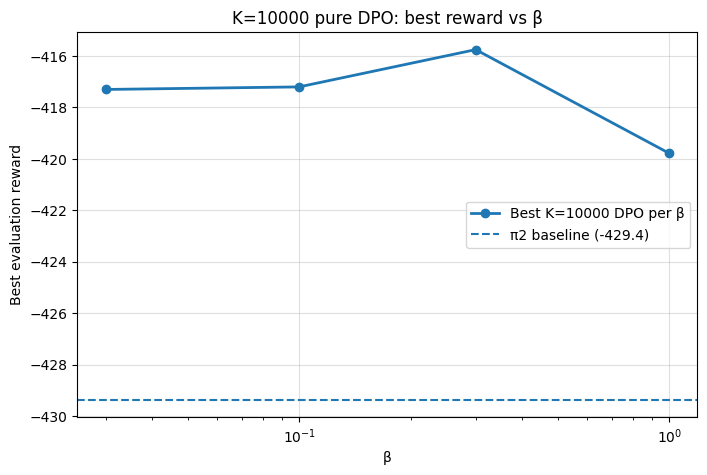

In [28]:
plt.figure(figsize=(8, 5))

plt.plot(
    k10000_best_by_beta["beta"],
    k10000_best_by_beta["best_reward"],
    marker="o",
    linewidth=2,
    label="Best K=10000 DPO per β",
)

plt.axhline(
    pi2_same_mean,
    linestyle="--",
    label=f"π2 baseline ({pi2_same_mean:.1f})",
)

plt.xscale("log")
plt.xlabel("β")
plt.ylabel("Best evaluation reward")
plt.title("K=10000 pure DPO: best reward vs β")
plt.grid(True, which="major", alpha=0.4)
plt.legend()
plt.show()

In [29]:
extra_k10000_configs = [
    {"beta": 0.003, "lr": 3e-7},
    {"beta": 0.01,  "lr": 3e-7},
    {"beta": 0.05,  "lr": 3e-7},
    {"beta": 0.2,   "lr": 3e-7},
    {"beta": 0.5,   "lr": 1e-7},
]

csv_path = "pure_dpo_K10000_fixed_update_sweep_seed0.csv"

# Load existing saved sweep
if os.path.exists(csv_path):
    k10000_sweep_df = pd.read_csv(csv_path)
    k10000_rows = k10000_sweep_df.to_dict("records")
    done_pairs = set(zip(k10000_sweep_df["beta"], k10000_sweep_df["lr"]))
    print("Loaded existing CSV:", csv_path)
else:
    k10000_rows = []
    done_pairs = set()

for cfg in extra_k10000_configs:
    beta = cfg["beta"]
    lr = cfg["lr"]

    if (beta, lr) in done_pairs:
        print(f"Skipping already done beta={beta}, lr={lr}")
        continue

    print("\n" + "=" * 90)
    print(f"EXTRA K=10000 SWEEP | beta={beta} | lr={lr}")
    print("=" * 90)

    set_all_seeds(0)

    env_train = gym.make(ENV_NAME)

    policy_model = PPO.load(PI2_PATH, env=env_train, device="cpu")
    ref_model = PPO.load(PI2_PATH, env=env_train, device="cpu")

    model_cfg, hist_cfg = train_pure_dpo_fixed_updates_with_eval(
        policy_model=policy_model,
        ref_model=ref_model,
        prefs=copy.deepcopy(trajectory_prefs_10000),
        max_updates=1500,
        batch_size=16,
        lr=lr,
        beta=beta,
        eval_every=100,
        eval_episodes=100,
        eval_seed_start=30_000,
    )

    env_train.close()

    row = {
        "beta": beta,
        "lr": lr,
        "best_step": hist_cfg["best_step"],
        "best_reward": hist_cfg["best_reward"],
        "improvement_same_eval": hist_cfg["best_reward"] - pi2_same_mean,
        "final_logged_reward": hist_cfg["reward"][-1],
    }

    k10000_rows.append(row)

    k10000_sweep_df = pd.DataFrame(k10000_rows)
    k10000_sweep_df.to_csv(csv_path, index=False)

    print("Saved updated sweep to:", csv_path)

k10000_sweep_df.sort_values("best_reward", ascending=False)

Loaded existing CSV: pure_dpo_K10000_fixed_update_sweep_seed0.csv

EXTRA K=10000 SWEEP | beta=0.003 | lr=3e-07
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Update 1/1500 | loss=0.693147 | reward=-429.36 ± 199.97 | lr=2.00e-09
Update 100/1500 | loss=0.693005 | reward=-426.76 ± 200.48 | lr=2.00e-07
Update 200/1500 | loss=0.692715 | reward=-425.21 ± 198.42 | lr=2.99e-07
Update 300/1500 | loss=0.692508 | reward=-421.94 ± 198.02 | lr=2.92e-07
Update 400/1500 | loss=0.691716 | reward=-417.34 ± 197.29 | lr=2.77e-07
Update 500/1500 | loss=0.690898 | reward=-418.70 ± 190.61 | lr=2.56e-07
Update 600/1500 | loss=0.691159 | reward=-419.75 ± 185.38 | lr=2.29e-07
Update 700/1500 | loss=0.690184 | reward=-426.84 ± 181.04 | lr=1.99e-07
Update 800/1500 | loss=0.690385 | reward=-431.80 ± 180.50 | lr=1.66e-07
Update 900/1500 | loss=0.690097 | reward=-432.17 ± 179.37 | lr=1.33e-07
Update 1000/1500 

,beta,lr,best_step,best_reward,improvement_same_eval,final_logged_reward
2,0.300,3.000000e-07,500,-415.756675,13.603441,-430.589835
7,0.200,3.000000e-07,500,-416.767628,12.592487,-432.604729
1,0.100,3.000000e-07,400,-417.205427,12.154689,-435.161329
6,0.050,3.000000e-07,400,-417.276382,12.083733,-436.962336
0,0.030,3.000000e-07,400,-417.304877,12.055238,-437.829770
5,0.010,3.000000e-07,400,-417.318325,12.041790,-438.321690
4,0.003,3.000000e-07,400,-417.343302,12.016813,-438.244371
3,1.000,1.000000e-07,1500,-419.786114,9.574002,-419.786114
8,0.500,1.000000e-07,1500,-420.010205,9.349911,-420.010205


In [30]:
k10000_best_by_beta = (
    k10000_sweep_df
    .sort_values("best_reward", ascending=False)
    .groupby("beta", as_index=False)
    .first()
    .sort_values("beta")
)

k10000_best_by_beta.to_csv("pure_dpo_K10000_best_by_beta_seed0.csv", index=False)

k10000_best_by_beta

,beta,lr,best_step,best_reward,improvement_same_eval,final_logged_reward
0,0.003,3.000000e-07,400,-417.343302,12.016813,-438.244371
1,0.010,3.000000e-07,400,-417.318325,12.041790,-438.321690
2,0.030,3.000000e-07,400,-417.304877,12.055238,-437.829770
3,0.050,3.000000e-07,400,-417.276382,12.083733,-436.962336
4,0.100,3.000000e-07,400,-417.205427,12.154689,-435.161329
5,0.200,3.000000e-07,500,-416.767628,12.592487,-432.604729
6,0.300,3.000000e-07,500,-415.756675,13.603441,-430.589835
7,0.500,1.000000e-07,1500,-420.010205,9.349911,-420.010205
8,1.000,1.000000e-07,1500,-419.786114,9.574002,-419.786114


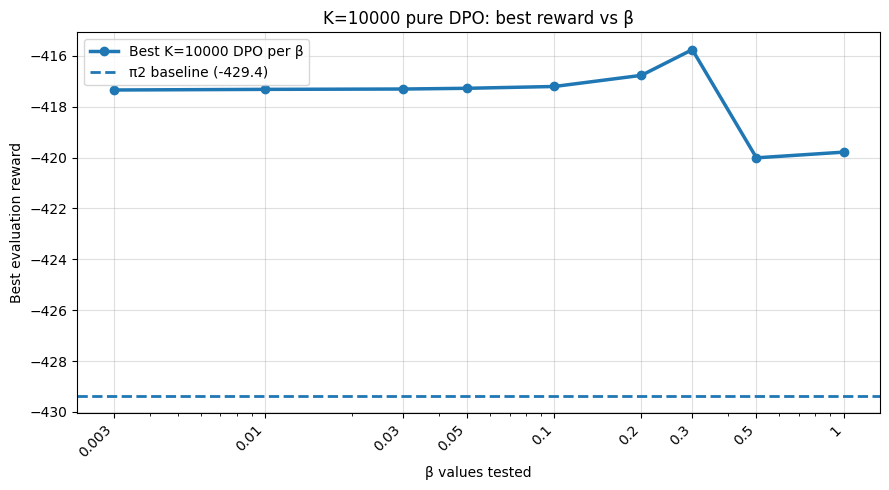

In [31]:
plt.figure(figsize=(9, 5))

plt.plot(
    k10000_best_by_beta["beta"],
    k10000_best_by_beta["best_reward"],
    marker="o",
    linewidth=2.5,
    label="Best K=10000 DPO per β",
)

plt.axhline(
    pi2_same_mean,
    linestyle="--",
    linewidth=2,
    label=f"π2 baseline ({pi2_same_mean:.1f})",
)

plt.xscale("log")

# Make x-axis explicitly show tested beta values
tested_betas = k10000_best_by_beta["beta"].values
plt.xticks(
    tested_betas,
    [f"{b:g}" for b in tested_betas],
    rotation=45,
    ha="right",
)

plt.xlabel("β values tested")
plt.ylabel("Best evaluation reward")
plt.title("K=10000 pure DPO: best reward vs β")
plt.grid(True, which="major", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

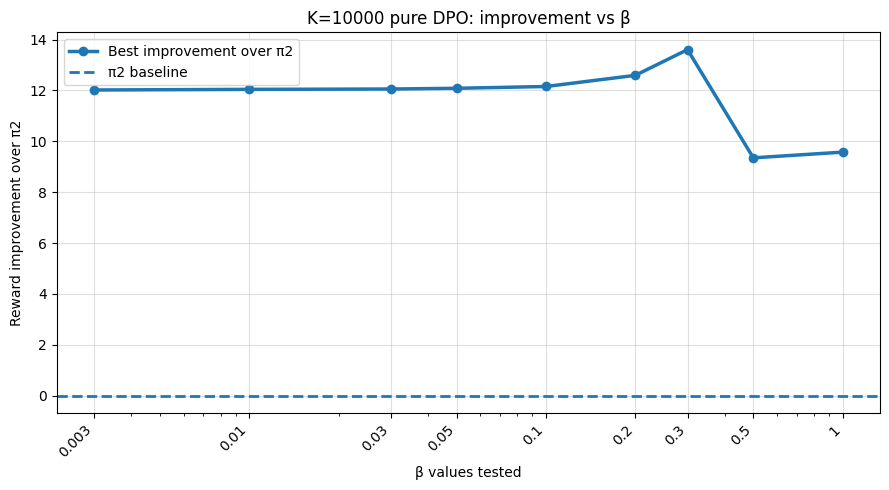

In [32]:
plt.figure(figsize=(9, 5))

plt.plot(
    k10000_best_by_beta["beta"],
    k10000_best_by_beta["improvement_same_eval"],
    marker="o",
    linewidth=2.5,
    label="Best improvement over π2",
)

plt.axhline(
    0.0,
    linestyle="--",
    linewidth=2,
    label="π2 baseline",
)

plt.xscale("log")

tested_betas = k10000_best_by_beta["beta"].values
plt.xticks(
    tested_betas,
    [f"{b:g}" for b in tested_betas],
    rotation=45,
    ha="right",
)

plt.xlabel("β values tested")
plt.ylabel("Reward improvement over π2")
plt.title("K=10000 pure DPO: improvement vs β")
plt.grid(True, which="major", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

In [33]:
BEST_BETA_10000 = 0.3
BEST_LR_10000 = 3e-7
MAX_UPDATES_10000 = 1500
K_10000 = 10000

SEEDS = [0, 1, 2]
def get_or_create_k10000_prefs_for_seed(seed, K=10000):
    path = f"pure_dpo_prefs_stoch_K{K}_seed{seed}.pkl"

    if os.path.exists(path):
        print("Loading prefs:", path)
        with open(path, "rb") as f:
            prefs = pickle.load(f)
    else:
        print("Creating prefs:", path)
        set_all_seeds(seed)

        prefs = collect_trajectory_preference_dataset(
            pi1_model,
            pi2_model,
            K=K,
            seed_start=123 + 10_000 * seed,
            deterministic_rollouts=False,
        )

        with open(path, "wb") as f:
            pickle.dump(prefs, f)

    return prefs

In [34]:
k10000_final_rows = []
k10000_final_runs = []

for seed in SEEDS:
    print("\n" + "=" * 90)
    print(f"K=10000 FINAL DPO | seed={seed}")
    print("=" * 90)

    prefs_seed = get_or_create_k10000_prefs_for_seed(
        seed=seed,
        K=K_10000,
    )

    set_all_seeds(seed)

    env_train = gym.make(ENV_NAME)

    policy_model = PPO.load(PI2_PATH, env=env_train, device="cpu")
    ref_model = PPO.load(PI2_PATH, env=env_train, device="cpu")

    model_seed, hist_seed = train_pure_dpo_fixed_updates_with_eval(
        policy_model=policy_model,
        ref_model=ref_model,
        prefs=copy.deepcopy(prefs_seed),
        max_updates=MAX_UPDATES_10000,
        batch_size=16,
        lr=BEST_LR_10000,
        beta=BEST_BETA_10000,
        eval_every=100,
        eval_episodes=100,
        eval_seed_start=30_000 + 10_000 * seed,
    )

    env_train.close()

    # Final evaluation on different seeds from early stopping
    test_seed_start = 70_000 + 10_000 * seed

    pi2_mean_seed, pi2_std_seed, _ = evaluate_sb3_policy(
        pi2_model,
        episodes=300,
        deterministic=True,
        seed_start=test_seed_start,
    )

    dpo_mean_seed, dpo_std_seed, _ = evaluate_sb3_policy(
        model_seed,
        episodes=300,
        deterministic=True,
        seed_start=test_seed_start,
    )

    k10000_final_runs.append({
        "seed": seed,
        "beta": BEST_BETA_10000,
        "lr": BEST_LR_10000,
        "model": model_seed,
        "history": hist_seed,
    })

    k10000_final_rows.append({
        "seed": seed,
        "K": K_10000,
        "beta": BEST_BETA_10000,
        "lr": BEST_LR_10000,
        "max_updates": MAX_UPDATES_10000,
        "pi2_mean": pi2_mean_seed,
        "pi2_std": pi2_std_seed,
        "dpo_mean": dpo_mean_seed,
        "dpo_std": dpo_std_seed,
        "improvement": dpo_mean_seed - pi2_mean_seed,
        "best_step": hist_seed["best_step"],
        "best_reward_during_training": hist_seed["best_reward"],
    })

k10000_final_df = pd.DataFrame(k10000_final_rows)

k10000_final_df.to_csv("pure_dpo_K10000_final_3seeds.csv", index=False)

k10000_final_df


K=10000 FINAL DPO | seed=0
Loading prefs: pure_dpo_prefs_stoch_K10000_seed0.pkl
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Update 1/1500 | loss=0.693147 | reward=-429.36 ± 199.97 | lr=2.00e-09
Update 100/1500 | loss=0.679188 | reward=-426.75 ± 200.48 | lr=2.00e-07
Update 200/1500 | loss=0.652467 | reward=-425.15 ± 198.46 | lr=2.99e-07
Update 300/1500 | loss=0.634778 | reward=-421.79 ± 198.15 | lr=2.92e-07
Update 400/1500 | loss=0.573186 | reward=-417.12 ± 197.99 | lr=2.77e-07
Update 500/1500 | loss=0.517345 | reward=-415.76 ± 194.74 | lr=2.56e-07
Update 600/1500 | loss=0.537914 | reward=-420.01 ± 186.52 | lr=2.29e-07
Update 700/1500 | loss=0.473878 | reward=-419.59 ± 183.55 | lr=1.99e-07
Update 800/1500 | loss=0.494701 | reward=-423.61 ± 183.19 | lr=1.66e-07
Update 900/1500 | loss=0.482606 | reward=-427.54 ± 183.47 | lr=1.33e-07
Update 1000/1500 | loss=0.498997 | reward=-429.

Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Update 1/1500 | loss=0.693147 | reward=-407.13 ± 180.03 | lr=2.00e-09
Update 100/1500 | loss=0.675396 | reward=-405.56 ± 178.81 | lr=2.00e-07
Update 200/1500 | loss=0.624260 | reward=-405.57 ± 177.09 | lr=2.99e-07
Update 300/1500 | loss=0.608261 | reward=-398.95 ± 177.76 | lr=2.92e-07
Update 400/1500 | loss=0.545115 | reward=-390.07 ± 180.32 | lr=2.77e-07
Update 500/1500 | loss=0.579900 | reward=-385.31 ± 180.90 | lr=2.56e-07
Update 600/1500 | loss=0.497880 | reward=-388.90 ± 176.72 | lr=2.29e-07
Update 700/1500 | loss=0.437384 | reward=-393.46 ± 171.63 | lr=1.99e-07
Update 800/1500 | loss=0.528402 | reward=-399.05 ± 167.60 | lr=1.66e-07
Update 900/1500 | loss=0.420159 | reward=-396.18 ± 165.64 | lr=1.33e-07
Update 1000/1500 | loss=0.421604 | reward=-397.14 ± 165.76 | lr=1.01e-07
Update 1100/1500 | loss=0.445052 | reward=-396.56 ± 165

Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Update 1/1500 | loss=0.693147 | reward=-379.10 ± 157.90 | lr=2.00e-09
Update 100/1500 | loss=0.675604 | reward=-378.81 ± 158.21 | lr=2.00e-07
Update 200/1500 | loss=0.657027 | reward=-377.12 ± 158.54 | lr=2.99e-07
Update 300/1500 | loss=0.592705 | reward=-378.36 ± 158.07 | lr=2.92e-07
Update 400/1500 | loss=0.564310 | reward=-377.61 ± 155.78 | lr=2.77e-07
Update 500/1500 | loss=0.506833 | reward=-374.19 ± 150.27 | lr=2.56e-07
Update 600/1500 | loss=0.529424 | reward=-375.87 ± 143.53 | lr=2.29e-07
Update 700/1500 | loss=0.537394 | reward=-381.05 ± 137.80 | lr=1.99e-07
Update 800/1500 | loss=0.427046 | reward=-382.19 ± 139.01 | lr=1.66e-07
Update 900/1500 | loss=0.426763 | reward=-385.24 ± 137.72 | lr=1.33e-07
Update 1000/1500 | loss=0.376720 | reward=-385.70 ± 137.95 | lr=1.01e-07
Update 1100/1500 | loss=0.427818 | reward=-385.08 ± 138

,seed,K,beta,lr,max_updates,pi2_mean,pi2_std,dpo_mean,dpo_std,improvement,best_step,best_reward_during_training
0,0,10000,0.3,3.000000e-07,1500,-402.859027,195.255029,-394.070132,190.915968,8.788896,500,-415.756675
1,1,10000,0.3,3.000000e-07,1500,-399.712031,174.919180,-391.568600,169.469028,8.143431,500,-385.306634
2,2,10000,0.3,3.000000e-07,1500,-390.783238,175.314030,-382.386293,171.654233,8.396945,500,-374.187103


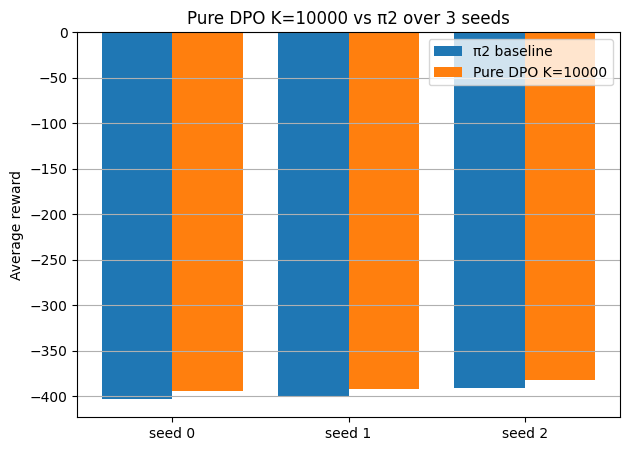

In [35]:
k10000_final_summary = pd.DataFrame([{
    "K": K_10000,
    "beta": BEST_BETA_10000,
    "lr": BEST_LR_10000,
    "pi2_mean": k10000_final_df["pi2_mean"].mean(),
    "pi2_std_across_seeds": k10000_final_df["pi2_mean"].std(),
    "dpo_mean": k10000_final_df["dpo_mean"].mean(),
    "dpo_std_across_seeds": k10000_final_df["dpo_mean"].std(),
    "improvement_mean": k10000_final_df["improvement"].mean(),
    "improvement_std": k10000_final_df["improvement"].std(),
    "mean_best_step": k10000_final_df["best_step"].mean(),
}])

k10000_final_summary.to_csv("pure_dpo_K10000_final_summary.csv", index=False)

k10000_final_summary
plt.figure(figsize=(7, 5))

x = np.arange(len(k10000_final_df))

plt.bar(
    x - 0.2,
    k10000_final_df["pi2_mean"],
    width=0.4,
    label="π2 baseline",
)

plt.bar(
    x + 0.2,
    k10000_final_df["dpo_mean"],
    width=0.4,
    label="Pure DPO K=10000",
)

plt.xticks(x, [f"seed {s}" for s in k10000_final_df["seed"]])
plt.ylabel("Average reward")
plt.title("Pure DPO K=10000 vs π2 over 3 seeds")
plt.grid(True, axis="y")
plt.legend()
plt.show()

In [36]:
k10000_final_df.to_csv("pure_dpo_K10000_final_3seeds.csv", index=False)

k10000_final_summary = pd.DataFrame([{
    "K": 10000,
    "beta": 0.3,
    "lr": 3e-7,
    "max_updates": 1500,
    "pi2_mean": k10000_final_df["pi2_mean"].mean(),
    "pi2_std_across_seeds": k10000_final_df["pi2_mean"].std(),
    "dpo_mean": k10000_final_df["dpo_mean"].mean(),
    "dpo_std_across_seeds": k10000_final_df["dpo_mean"].std(),
    "improvement_mean": k10000_final_df["improvement"].mean(),
    "improvement_std": k10000_final_df["improvement"].std(),
    "mean_best_step": k10000_final_df["best_step"].mean(),
}])

k10000_final_summary.to_csv("pure_dpo_K10000_final_summary.csv", index=False)

print("Saved:")
print("pure_dpo_K10000_final_3seeds.csv")
print("pure_dpo_K10000_final_summary.csv")

k10000_final_summary

Saved:
pure_dpo_K10000_final_3seeds.csv
pure_dpo_K10000_final_summary.csv


,K,beta,lr,max_updates,pi2_mean,pi2_std_across_seeds,dpo_mean,dpo_std_across_seeds,improvement_mean,improvement_std,mean_best_step
0,10000,0.3,3.000000e-07,1500,-397.784765,6.264338,-389.341675,6.152025,8.44309,0.325197,500.0


PPO RLHF

In [37]:
import os, pickle, copy, random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import gymnasium as gym
import matplotlib.pyplot as plt

from tqdm import tqdm
from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import BaseCallback

DEVICE = "cpu"
ENV_NAME = "Pendulum-v1"

PI1_PATH = "pendulum_ppo_pi1_final_stronger_minus155"
PI2_PATH = "pendulum_pi2_mid_after_80000_mean_-391"

def set_all_seeds(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

def evaluate_sb3_policy(model, episodes=100, deterministic=True, seed_start=0):
    env = gym.make(ENV_NAME)
    returns = []

    for ep in range(episodes):
        obs, _ = env.reset(seed=seed_start + ep)
        done = False
        total_reward = 0.0

        while not done:
            action, _ = model.predict(obs, deterministic=deterministic)
            obs, reward, terminated, truncated, info = env.step(action)
            total_reward += reward
            done = terminated or truncated

        returns.append(total_reward)

    env.close()
    return float(np.mean(returns)), float(np.std(returns)), returns

pi1_model = PPO.load(PI1_PATH, device=DEVICE)
pi2_model = PPO.load(PI2_PATH, device=DEVICE)

K = 10000
SEED = 0

prefs_path = f"pure_dpo_prefs_stoch_K{K}_seed{SEED}.pkl"

with open(prefs_path, "rb") as f:
    prefs_10000 = pickle.load(f)

print("Loaded:", prefs_path)
print("Number of preference pairs:", len(prefs_10000))
print("Example keys:", prefs_10000[0].keys())

Loaded: pure_dpo_prefs_stoch_K10000_seed0.pkl
Number of preference pairs: 10000
Example keys: dict_keys(['winner_obs', 'winner_raw_actions', 'winner_env_actions', 'winner_return', 'winner_length', 'loser_obs', 'loser_raw_actions', 'loser_env_actions', 'loser_return', 'loser_length', 'pi1_return', 'pi2_return', 'p_pi1_preferred'])


In [38]:
class RewardModel(nn.Module):
    def __init__(self, obs_dim=3, act_dim=1, hidden=128):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(obs_dim + act_dim, hidden),
            nn.Tanh(),
            nn.Linear(hidden, hidden),
            nn.Tanh(),
            nn.Linear(hidden, 1),
        )

    def forward(self, obs, act):
        x = torch.cat([obs, act], dim=-1)
        return self.net(x).squeeze(-1)


def get_traj_from_pref(pref, side):
    obs = np.asarray(pref[f"{side}_obs"], dtype=np.float32)

    # use actions actually executed in Pendulum
    if f"{side}_env_actions" in pref:
        act = np.asarray(pref[f"{side}_env_actions"], dtype=np.float32)
    else:
        act = np.asarray(pref[f"{side}_raw_actions"], dtype=np.float32)

    if act.ndim == 1:
        act = act.reshape(-1, 1)

    T = min(len(obs), len(act))
    return obs[:T], act[:T]


def batch_scores(reward_model, prefs_batch, side, device="cpu"):
    obs_list = []
    act_list = []

    for pref in prefs_batch:
        obs, act = get_traj_from_pref(pref, side)
        obs_list.append(obs)
        act_list.append(act)

    # Pendulum trajectories should have same length, but keep safe
    T = min(len(o) for o in obs_list)

    obs_batch = np.stack([o[:T] for o in obs_list], axis=0)  # [B,T,3]
    act_batch = np.stack([a[:T] for a in act_list], axis=0)  # [B,T,1]

    obs_t = torch.as_tensor(obs_batch, dtype=torch.float32, device=device)
    act_t = torch.as_tensor(act_batch, dtype=torch.float32, device=device)

    B, T, obs_dim = obs_t.shape
    act_dim = act_t.shape[-1]

    flat_obs = obs_t.reshape(B * T, obs_dim)
    flat_act = act_t.reshape(B * T, act_dim)

    r = reward_model(flat_obs, flat_act).reshape(B, T)

    # mean score per trajectory, stable because all trajectories are same length
    return r.mean(dim=1)

In [39]:
def train_reward_model(
    prefs,
    epochs=5,
    batch_size=64,
    lr=1e-3,
    device="cpu",
    seed=0,
):
    set_all_seeds(seed)

    reward_model = RewardModel().to(device)
    optimizer = torch.optim.AdamW(reward_model.parameters(), lr=lr, weight_decay=1e-4)

    prefs = copy.deepcopy(prefs)
    random.shuffle(prefs)

    split = int(0.9 * len(prefs))
    train_prefs = prefs[:split]
    val_prefs = prefs[split:]

    train_losses = []
    val_accs = []

    for epoch in range(epochs):
        random.shuffle(train_prefs)

        total_loss = 0.0
        num_batches = 0

        reward_model.train()

        for start in tqdm(range(0, len(train_prefs), batch_size), desc=f"Reward model epoch {epoch+1}/{epochs}"):
            batch = train_prefs[start:start + batch_size]

            score_w = batch_scores(reward_model, batch, "winner", device=device)
            score_l = batch_scores(reward_model, batch, "loser", device=device)

            loss = -F.logsigmoid(score_w - score_l).mean()

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += float(loss.item())
            num_batches += 1

        avg_loss = total_loss / max(num_batches, 1)
        train_losses.append(avg_loss)

        reward_model.eval()
        correct = 0
        total = 0

        with torch.no_grad():
            for start in range(0, min(len(val_prefs), 1000), batch_size):
                batch = val_prefs[start:start + batch_size]

                score_w = batch_scores(reward_model, batch, "winner", device=device)
                score_l = batch_scores(reward_model, batch, "loser", device=device)

                correct += int((score_w > score_l).sum().item())
                total += len(batch)

        val_acc = correct / max(total, 1)
        val_accs.append(val_acc)

        print(f"Epoch {epoch+1}/{epochs} | loss={avg_loss:.4f} | val acc={val_acc:.3f}")

    history = {
        "train_loss": train_losses,
        "val_acc": val_accs,
    }

    return reward_model, history

In [40]:
reward_model, reward_history = train_reward_model(
    prefs=prefs_10000,
    epochs=5,
    batch_size=64,
    lr=1e-3,
    device=DEVICE,
    seed=0,
)

Reward model epoch 1/5: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 141/141 [00:02<00:00, 62.20it/s]


Epoch 1/5 | loss=0.0769 | val acc=0.999


Reward model epoch 2/5: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 141/141 [00:01<00:00, 101.93it/s]


Epoch 2/5 | loss=0.0134 | val acc=0.999


Reward model epoch 3/5: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 141/141 [00:01<00:00, 100.11it/s]


Epoch 3/5 | loss=0.0099 | val acc=0.999


Reward model epoch 4/5: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 141/141 [00:01<00:00, 82.40it/s]


Epoch 4/5 | loss=0.0060 | val acc=0.999


Reward model epoch 5/5: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 141/141 [00:01<00:00, 104.01it/s]


Epoch 5/5 | loss=0.0037 | val acc=0.999


In [41]:
os.makedirs("saved_reward_models", exist_ok=True)

torch.save(
    reward_model.state_dict(),
    "saved_reward_models/pendulum_reward_model_K10000_seed0.pt",
)

with open("saved_reward_models/pendulum_reward_model_K10000_seed0_history.pkl", "wb") as f:
    pickle.dump(reward_history, f)

print("Saved reward model.")

Saved reward model.


In [42]:
def compute_reward_model_stats(reward_model, prefs, n_pairs=500, device="cpu"):
    reward_model.eval()

    all_rewards = []

    subset = prefs[:min(n_pairs, len(prefs))]

    with torch.no_grad():
        for pref in subset:
            for side in ["winner", "loser"]:
                obs, act = get_traj_from_pref(pref, side)

                obs_t = torch.as_tensor(obs, dtype=torch.float32, device=device)
                act_t = torch.as_tensor(act, dtype=torch.float32, device=device)

                r = reward_model(obs_t, act_t).detach().cpu().numpy()
                all_rewards.append(r)

    all_rewards = np.concatenate(all_rewards)

    mean = float(all_rewards.mean())
    std = float(all_rewards.std() + 1e-8)

    return mean, std

rm_mean, rm_std = compute_reward_model_stats(
    reward_model,
    prefs_10000,
    n_pairs=500,
    device=DEVICE,
)

print("Reward model mean/std:", rm_mean, rm_std)
class LearnedRewardWrapper(gym.Wrapper):
    def __init__(
        self,
        env,
        reward_model,
        rm_mean,
        rm_std,
        device="cpu",
        reward_scale=1.0,
        reward_clip=10.0,
    ):
        super().__init__(env)
        self.reward_model = reward_model
        self.reward_model.eval()
        self.rm_mean = rm_mean
        self.rm_std = rm_std
        self.device = device
        self.reward_scale = reward_scale
        self.reward_clip = reward_clip
        self.last_obs = None

    def reset(self, **kwargs):
        obs, info = self.env.reset(**kwargs)
        self.last_obs = obs
        return obs, info

    def step(self, action):
        current_obs = self.last_obs

        next_obs, true_reward, terminated, truncated, info = self.env.step(action)

        obs_t = torch.as_tensor(current_obs, dtype=torch.float32, device=self.device).view(1, -1)
        act_t = torch.as_tensor(action, dtype=torch.float32, device=self.device).view(1, -1)

        with torch.no_grad():
            raw_reward = self.reward_model(obs_t, act_t).item()

        learned_reward = (raw_reward - self.rm_mean) / self.rm_std
        learned_reward = learned_reward * self.reward_scale
        learned_reward = float(np.clip(learned_reward, -self.reward_clip, self.reward_clip))

        info["true_reward"] = true_reward
        info["learned_reward"] = learned_reward

        self.last_obs = next_obs

        return next_obs, learned_reward, terminated, truncated, info

Reward model mean/std: 6.227323532104492 8.793016443715821


In [45]:
class TrueRewardEvalCallback(BaseCallback):
    def __init__(
        self,
        eval_every_timesteps=10_000,
        eval_episodes=100,
        eval_seed_start=70_000,
        verbose=1,
    ):
        super().__init__(verbose)
        self.eval_every_timesteps = eval_every_timesteps
        self.eval_episodes = eval_episodes
        self.eval_seed_start = eval_seed_start

        self.last_eval = 0
        self.best_reward = -float("inf")
        self.best_state_dict = None
        self.history = {
            "timesteps": [],
            "true_reward_mean": [],
            "true_reward_std": [],
        }

    def _on_step(self):
        if self.num_timesteps - self.last_eval >= self.eval_every_timesteps:
            self.last_eval = self.num_timesteps

            mean_reward, std_reward, _ = evaluate_sb3_policy(
                self.model,
                episodes=self.eval_episodes,
                deterministic=True,
                seed_start=self.eval_seed_start,
            )

            self.history["timesteps"].append(self.num_timesteps)
            self.history["true_reward_mean"].append(mean_reward)
            self.history["true_reward_std"].append(std_reward)

            if mean_reward > self.best_reward:
                self.best_reward = mean_reward
                self.best_state_dict = copy.deepcopy(self.model.policy.state_dict())

            print(
                f"[True eval] step={self.num_timesteps} | "
                f"reward={mean_reward:.2f} ± {std_reward:.2f} | "
                f"best={self.best_reward:.2f}"
            )

        return True

In [47]:
def train_ppo_rlhf_seed0(
    reward_model,
    rm_mean,
    rm_std,
    total_timesteps=100_000,
    seed=0,
    ppo_lr=3e-5,
):
    set_all_seeds(seed)

    base_env = gym.make(ENV_NAME)

    rm_env = LearnedRewardWrapper(
        base_env,
        reward_model=reward_model,
        rm_mean=rm_mean,
        rm_std=rm_std,
        device=DEVICE,
        reward_scale=1.0,
        reward_clip=10.0,
    )

    # PPO-RLHF starts from π2
    ppo_rlhf = PPO.load(PI2_PATH, env=rm_env, device=DEVICE)

    # Override learning rate
    ppo_rlhf.learning_rate = ppo_lr
    ppo_rlhf.lr_schedule = lambda _: ppo_lr

    for group in ppo_rlhf.policy.optimizer.param_groups:
        group["lr"] = ppo_lr

    callback = TrueRewardEvalCallback(
        eval_every_timesteps=10_000,
        eval_episodes=100,
        eval_seed_start=70_000,
    )

    ppo_rlhf.learn(
        total_timesteps=total_timesteps,
        callback=callback,
    )

    # load best true-reward checkpoint
    if callback.best_state_dict is not None:
        ppo_rlhf.policy.load_state_dict(callback.best_state_dict)

    rm_env.close()

    return ppo_rlhf, callback.history, callback.best_reward

In [48]:
ppo_rlhf_model, ppo_rlhf_history, ppo_rlhf_best_reward = train_ppo_rlhf_seed0(
    reward_model=reward_model,
    rm_mean=rm_mean,
    rm_std=rm_std,
    total_timesteps=100_000,
    seed=0,
    ppo_lr=3e-5,
)

print("Best true reward during PPO-RLHF:", ppo_rlhf_best_reward)

Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 200      |
|    ep_rew_mean     | -90      |
| time/              |          |
|    fps             | 1313     |
|    iterations      | 1        |
|    time_elapsed    | 1        |
|    total_timesteps | 2048     |
---------------------------------
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 200          |
|    ep_rew_mean          | -88.6        |
| time/                   |              |
|    fps                  | 853          |
|    iterations           | 2            |
|    time_elapsed         | 4            |
|    total_timesteps      | 4096         |
| train/                  |              |
|    approx_kl            | 0.0015577604 |
|    clip_fraction        | 0.000195     |
|    clip_range           | 0.2          |
|    entropy_loss       

In [50]:
os.makedirs("saved_ppo_rlhf_models", exist_ok=True)

ppo_rlhf_model.save("saved_ppo_rlhf_models/pendulum_ppo_rlhf_K10000_seed0")

with open("saved_ppo_rlhf_models/pendulum_ppo_rlhf_K10000_seed0_history.pkl", "wb") as f:
    pickle.dump(ppo_rlhf_history, f)

print("Saved PPO-RLHF model and history.")

Saved PPO-RLHF model and history.


In [51]:
pi2_eval_mean, pi2_eval_std, _ = evaluate_sb3_policy(
    pi2_model,
    episodes=300,
    deterministic=True,
    seed_start=70_000,
)

ppo_rlhf_mean, ppo_rlhf_std, _ = evaluate_sb3_policy(
    ppo_rlhf_model,
    episodes=300,
    deterministic=True,
    seed_start=70_000,
)

print("π2 baseline:", pi2_eval_mean, pi2_eval_std)
print("PPO-RLHF:", ppo_rlhf_mean, ppo_rlhf_std)
print("Improvement:", ppo_rlhf_mean - pi2_eval_mean)

π2 baseline: -402.8590272629127 195.25502897571167
PPO-RLHF: -248.67329461804232 212.06025073231095
Improvement: 154.1857326448704


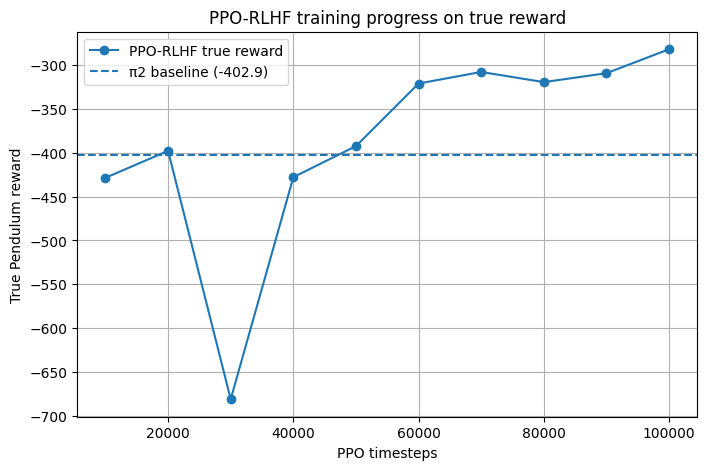

In [52]:
plt.figure(figsize=(8, 5))

plt.plot(
    ppo_rlhf_history["timesteps"],
    ppo_rlhf_history["true_reward_mean"],
    marker="o",
    label="PPO-RLHF true reward",
)

plt.axhline(
    pi2_eval_mean,
    linestyle="--",
    label=f"π2 baseline ({pi2_eval_mean:.1f})",
)

plt.xlabel("PPO timesteps")
plt.ylabel("True Pendulum reward")
plt.title("PPO-RLHF training progress on true reward")
plt.grid(True)
plt.legend()
plt.show()

In [53]:
def continue_ppo_rlhf(
    ppo_rlhf_model,
    reward_model,
    rm_mean,
    rm_std,
    extra_timesteps=100_000,
    ppo_lr=5e-6,
    seed=0,
):
    set_all_seeds(seed)

    base_env = gym.make(ENV_NAME)

    rm_env = LearnedRewardWrapper(
        base_env,
        reward_model=reward_model,
        rm_mean=rm_mean,
        rm_std=rm_std,
        device=DEVICE,
        reward_scale=1.0,
        reward_clip=10.0,
    )

    ppo_rlhf_model.set_env(rm_env)

    ppo_rlhf_model.learning_rate = ppo_lr
    ppo_rlhf_model.lr_schedule = lambda _: ppo_lr

    for group in ppo_rlhf_model.policy.optimizer.param_groups:
        group["lr"] = ppo_lr

    callback = TrueRewardEvalCallback(
        eval_every_timesteps=10_000,
        eval_episodes=100,
        eval_seed_start=70_000,
    )

    ppo_rlhf_model.learn(
        total_timesteps=extra_timesteps,
        callback=callback,
        reset_num_timesteps=False,
    )

    if callback.best_state_dict is not None:
        ppo_rlhf_model.policy.load_state_dict(callback.best_state_dict)

    rm_env.close()

    return ppo_rlhf_model, callback.history, callback.best_reward

In [54]:
ppo_rlhf_model_200k, ppo_rlhf_history_200k, ppo_rlhf_best_reward_200k = continue_ppo_rlhf(
    ppo_rlhf_model=ppo_rlhf_model,
    reward_model=reward_model,
    rm_mean=rm_mean,
    rm_std=rm_std,
    extra_timesteps=100_000,
    ppo_lr=5e-6,
    seed=0,
)

print("Best true reward after continuation:", ppo_rlhf_best_reward_200k)

Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
[True eval] step=100353 | reward=-282.06 ± 250.47 | best=-282.06
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 200      |
|    ep_rew_mean     | 7.64     |
| time/              |          |
|    fps             | 295      |
|    iterations      | 1        |
|    time_elapsed    | 6        |
|    total_timesteps | 102400   |
---------------------------------
-------------------------------------------
| rollout/                |               |
|    ep_len_mean          | 200           |
|    ep_rew_mean          | 5.2           |
| time/                   |               |
|    fps                  | 431           |
|    iterations           | 2             |
|    time_elapsed         | 9             |
|    total_timesteps      | 104448        |
| train/                  |               |
|    approx_kl            | 0.00015825266 |
|    clip_fraction        | 0     

In [55]:
ppo_rlhf_200k_mean, ppo_rlhf_200k_std, _ = evaluate_sb3_policy(
    ppo_rlhf_model_200k,
    episodes=300,
    deterministic=True,
    seed_start=70_000,
)

print("π2 baseline:", pi2_eval_mean, pi2_eval_std)
print("PPO-RLHF continued:", ppo_rlhf_200k_mean, ppo_rlhf_200k_std)
print("Improvement:", ppo_rlhf_200k_mean - pi2_eval_mean)

π2 baseline: -402.8590272629127 195.25502897571167
PPO-RLHF continued: -234.88871753129905 196.12029603879915
Improvement: 167.97030973161367


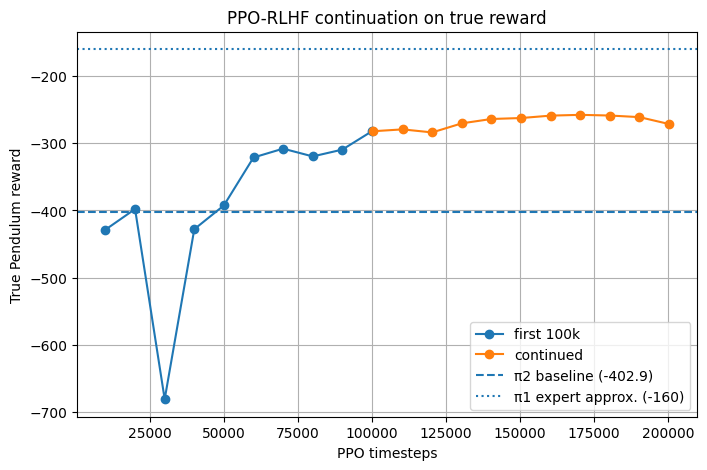

In [56]:
plt.figure(figsize=(8, 5))

plt.plot(
    ppo_rlhf_history["timesteps"],
    ppo_rlhf_history["true_reward_mean"],
    marker="o",
    label="first 100k",
)

offset = ppo_rlhf_history["timesteps"][-1]

plt.plot(
    np.array(ppo_rlhf_history_200k["timesteps"]),
    ppo_rlhf_history_200k["true_reward_mean"],
    marker="o",
    label="continued",
)

plt.axhline(
    pi2_eval_mean,
    linestyle="--",
    label=f"π2 baseline ({pi2_eval_mean:.1f})",
)

plt.axhline(
    -160,
    linestyle=":",
    label="π1 expert approx. (-160)",
)

plt.xlabel("PPO timesteps")
plt.ylabel("True Pendulum reward")
plt.title("PPO-RLHF continuation on true reward")
plt.grid(True)
plt.legend()
plt.show()

In [57]:
ppo_rlhf_model_300k, ppo_rlhf_history_300k, ppo_rlhf_best_reward_300k = continue_ppo_rlhf(
    ppo_rlhf_model=ppo_rlhf_model_200k,
    reward_model=reward_model,
    rm_mean=rm_mean,
    rm_std=rm_std,
    extra_timesteps=100_000,
    ppo_lr=2e-6,
    seed=0,
)

print("Best true reward after second continuation:", ppo_rlhf_best_reward_300k)

Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
[True eval] step=200705 | reward=-257.67 ± 223.87 | best=-257.67
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 200      |
|    ep_rew_mean     | 2.56     |
| time/              |          |
|    fps             | 298      |
|    iterations      | 1        |
|    time_elapsed    | 6        |
|    total_timesteps | 202752   |
---------------------------------
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 200          |
|    ep_rew_mean          | -2.7         |
| time/                   |              |
|    fps                  | 449          |
|    iterations           | 2            |
|    time_elapsed         | 9            |
|    total_timesteps      | 204800       |
| train/                  |              |
|    approx_kl            | 3.654472e-05 |
|    clip_fraction        | 0            |
| 

In [58]:
ppo_rlhf_300k_mean, ppo_rlhf_300k_std, _ = evaluate_sb3_policy(
    ppo_rlhf_model_300k,
    episodes=300,
    deterministic=True,
    seed_start=70_000,
)

print("π2 baseline:", pi2_eval_mean, pi2_eval_std)
print("PPO-RLHF 300k:", ppo_rlhf_300k_mean, ppo_rlhf_300k_std)
print("Improvement:", ppo_rlhf_300k_mean - pi2_eval_mean)

π2 baseline: -402.8590272629127 195.25502897571167
PPO-RLHF 300k: -224.6004208576593 192.79626876193964
Improvement: 178.25860640525343


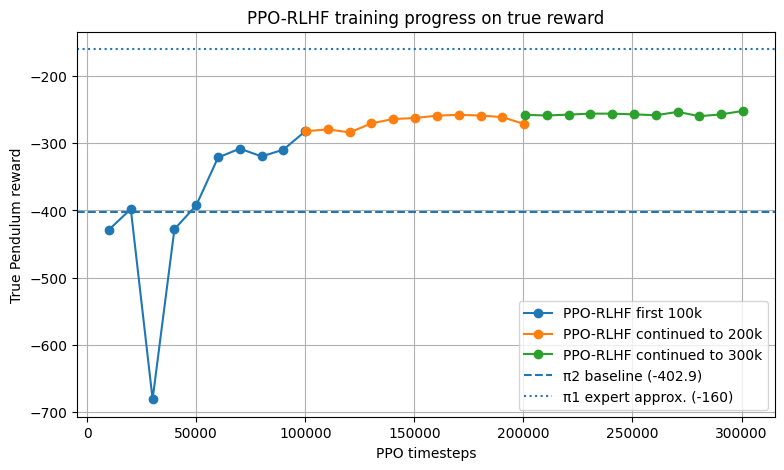

In [59]:
plt.figure(figsize=(9, 5))

# first 100k
plt.plot(
    ppo_rlhf_history["timesteps"],
    ppo_rlhf_history["true_reward_mean"],
    marker="o",
    label="PPO-RLHF first 100k",
)

# 100k -> 200k
plt.plot(
    ppo_rlhf_history_200k["timesteps"],
    ppo_rlhf_history_200k["true_reward_mean"],
    marker="o",
    label="PPO-RLHF continued to 200k",
)

# 200k -> 300k
plt.plot(
    ppo_rlhf_history_300k["timesteps"],
    ppo_rlhf_history_300k["true_reward_mean"],
    marker="o",
    label="PPO-RLHF continued to 300k",
)

plt.axhline(
    pi2_eval_mean,
    linestyle="--",
    label=f"π2 baseline ({pi2_eval_mean:.1f})",
)

plt.axhline(
    -160,
    linestyle=":",
    label="π1 expert approx. (-160)",
)

plt.xlabel("PPO timesteps")
plt.ylabel("True Pendulum reward")
plt.title("PPO-RLHF training progress on true reward")
plt.grid(True)
plt.legend()
plt.show()

In [60]:
ppo_rlhf_model_300k.save("saved_ppo_rlhf_models/pendulum_ppo_rlhf_K10000_seed0_300k_best")

with open("saved_ppo_rlhf_models/pendulum_ppo_rlhf_K10000_seed0_300k_history.pkl", "wb") as f:
    pickle.dump(ppo_rlhf_history_300k, f)

In [61]:
def train_ppo_rlhf_custom(
    reward_model,
    rm_mean,
    rm_std,
    total_timesteps=150_000,
    seed=0,
    ppo_lr=1e-5,
    reward_scale=1.0,
    reward_clip=10.0,
    eval_every_timesteps=10_000,
):
    set_all_seeds(seed)

    base_env = gym.make(ENV_NAME)

    rm_env = LearnedRewardWrapper(
        base_env,
        reward_model=reward_model,
        rm_mean=rm_mean,
        rm_std=rm_std,
        device=DEVICE,
        reward_scale=reward_scale,
        reward_clip=reward_clip,
    )

    # Start from π2, same as before
    model = PPO.load(PI2_PATH, env=rm_env, device=DEVICE)

    model.learning_rate = ppo_lr
    model.lr_schedule = lambda _: ppo_lr

    for group in model.policy.optimizer.param_groups:
        group["lr"] = ppo_lr

    callback = TrueRewardEvalCallback(
        eval_every_timesteps=eval_every_timesteps,
        eval_episodes=100,
        eval_seed_start=70_000,
    )

    model.learn(
        total_timesteps=total_timesteps,
        callback=callback,
    )

    if callback.best_state_dict is not None:
        model.policy.load_state_dict(callback.best_state_dict)

    rm_env.close()

    return model, callback.history, callback.best_reward

In [62]:
ppo_rlhf_configs = [
    {"name": "scale0.5_lr1e-5", "reward_scale": 0.5, "ppo_lr": 1e-5},
    {"name": "scale1.0_lr1e-5", "reward_scale": 1.0, "ppo_lr": 1e-5},
    {"name": "scale2.0_lr5e-6", "reward_scale": 2.0, "ppo_lr": 5e-6},
]

ppo_rlhf_sweep_runs = []
ppo_rlhf_sweep_rows = []

for cfg in ppo_rlhf_configs:
    print("\n" + "=" * 90)
    print("PPO-RLHF CONFIG:", cfg)
    print("=" * 90)

    model_cfg, hist_cfg, best_reward_cfg = train_ppo_rlhf_custom(
        reward_model=reward_model,
        rm_mean=rm_mean,
        rm_std=rm_std,
        total_timesteps=150_000,
        seed=0,
        ppo_lr=cfg["ppo_lr"],
        reward_scale=cfg["reward_scale"],
        reward_clip=10.0,
        eval_every_timesteps=10_000,
    )

    final_mean, final_std, _ = evaluate_sb3_policy(
        model_cfg,
        episodes=300,
        deterministic=True,
        seed_start=70_000,
    )

    row = {
        "config": cfg["name"],
        "reward_scale": cfg["reward_scale"],
        "ppo_lr": cfg["ppo_lr"],
        "best_reward_during_training": best_reward_cfg,
        "final_eval_mean": final_mean,
        "final_eval_std": final_std,
        "improvement_over_pi2": final_mean - pi2_eval_mean,
    }

    ppo_rlhf_sweep_rows.append(row)
    ppo_rlhf_sweep_runs.append({
        **cfg,
        "model": model_cfg,
        "history": hist_cfg,
        "best_reward": best_reward_cfg,
    })

    pd.DataFrame(ppo_rlhf_sweep_rows).to_csv(
        "ppo_rlhf_K10000_seed0_small_sweep.csv",
        index=False,
    )

ppo_rlhf_sweep_df = pd.DataFrame(ppo_rlhf_sweep_rows)
ppo_rlhf_sweep_df.sort_values("best_reward_during_training", ascending=False)


PPO-RLHF CONFIG: {'name': 'scale0.5_lr1e-5', 'reward_scale': 0.5, 'ppo_lr': 1e-05}
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 200      |
|    ep_rew_mean     | -45      |
| time/              |          |
|    fps             | 1520     |
|    iterations      | 1        |
|    time_elapsed    | 1        |
|    total_timesteps | 2048     |
---------------------------------
-------------------------------------------
| rollout/                |               |
|    ep_len_mean          | 200           |
|    ep_rew_mean          | -47.5         |
| time/                   |               |
|    fps                  | 917           |
|    iterations           | 2             |
|    time_elapsed         | 4             |
|    total_timesteps      | 4096          |
| train/                  |               |
|    approx_kl            | 5.4406744e-05 |
|    clip_fract

,config,reward_scale,ppo_lr,best_reward_during_training,final_eval_mean,final_eval_std,improvement_over_pi2
1,scale1.0_lr1e-5,1.0,0.000010,-332.279840,-299.992609,221.275680,102.866418
2,scale2.0_lr5e-6,2.0,0.000005,-336.545904,-301.173570,230.831010,101.685457
0,scale0.5_lr1e-5,0.5,0.000010,-418.061939,-381.527891,208.668288,21.331137


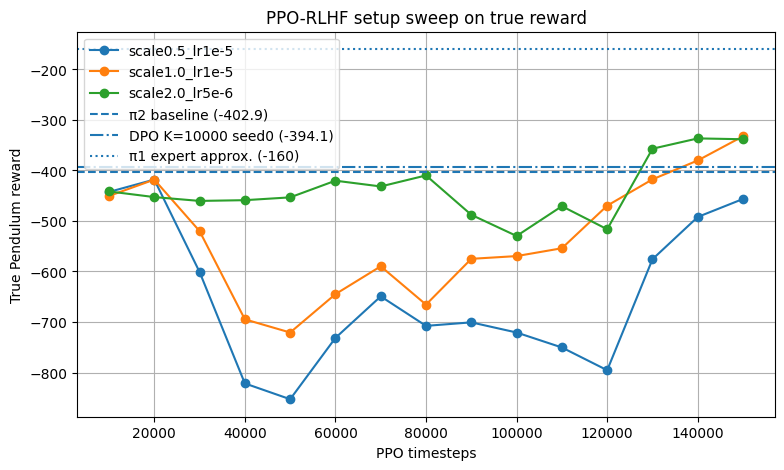

In [63]:
plt.figure(figsize=(9, 5))

for run in ppo_rlhf_sweep_runs:
    hist = run["history"]

    plt.plot(
        hist["timesteps"],
        hist["true_reward_mean"],
        marker="o",
        label=f"{run['name']}",
    )

plt.axhline(
    pi2_eval_mean,
    linestyle="--",
    label=f"π2 baseline ({pi2_eval_mean:.1f})",
)

plt.axhline(
    -394.070132,
    linestyle="-.",
    label="DPO K=10000 seed0 (-394.1)",
)

plt.axhline(
    -160,
    linestyle=":",
    label="π1 expert approx. (-160)",
)

plt.xlabel("PPO timesteps")
plt.ylabel("True Pendulum reward")
plt.title("PPO-RLHF setup sweep on true reward")
plt.grid(True)
plt.legend()
plt.show()

In [64]:
def train_reward_model_v2(
    prefs,
    hidden=256,
    epochs=15,
    batch_size=64,
    lr=3e-4,
    device="cpu",
    seed=0,
):
    set_all_seeds(seed)

    reward_model = RewardModel(hidden=hidden).to(device)
    optimizer = torch.optim.AdamW(reward_model.parameters(), lr=lr, weight_decay=1e-4)

    prefs = copy.deepcopy(prefs)
    random.shuffle(prefs)

    split = int(0.9 * len(prefs))
    train_prefs = prefs[:split]
    val_prefs = prefs[split:]

    train_losses = []
    val_accs = []

    for epoch in range(epochs):
        random.shuffle(train_prefs)

        total_loss = 0.0
        num_batches = 0

        reward_model.train()

        for start in tqdm(range(0, len(train_prefs), batch_size), desc=f"Reward model v2 epoch {epoch+1}/{epochs}"):
            batch = train_prefs[start:start + batch_size]

            score_w = batch_scores(reward_model, batch, "winner", device=device)
            score_l = batch_scores(reward_model, batch, "loser", device=device)

            loss = -F.logsigmoid(score_w - score_l).mean()

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(reward_model.parameters(), 1.0)
            optimizer.step()

            total_loss += float(loss.item())
            num_batches += 1

        avg_loss = total_loss / max(num_batches, 1)
        train_losses.append(avg_loss)

        reward_model.eval()
        correct = 0
        total = 0

        with torch.no_grad():
            for start in range(0, min(len(val_prefs), 1000), batch_size):
                batch = val_prefs[start:start + batch_size]

                score_w = batch_scores(reward_model, batch, "winner", device=device)
                score_l = batch_scores(reward_model, batch, "loser", device=device)

                correct += int((score_w > score_l).sum().item())
                total += len(batch)

        val_acc = correct / max(total, 1)
        val_accs.append(val_acc)

        print(f"Epoch {epoch+1}/{epochs} | loss={avg_loss:.4f} | val acc={val_acc:.3f}")

    return reward_model, {
        "train_loss": train_losses,
        "val_acc": val_accs,
    }

In [65]:
reward_model_v2, reward_history_v2 = train_reward_model_v2(
    prefs=prefs_10000,
    hidden=256,
    epochs=15,
    batch_size=64,
    lr=3e-4,
    device=DEVICE,
    seed=0,
)

rm_mean_v2, rm_std_v2 = compute_reward_model_stats(
    reward_model_v2,
    prefs_10000,
    n_pairs=500,
    device=DEVICE,
)

print("Reward model v2 mean/std:", rm_mean_v2, rm_std_v2)

Reward model v2 epoch 1/15: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 141/141 [00:03<00:00, 37.34it/s]


Epoch 1/15 | loss=0.0939 | val acc=0.999


Reward model v2 epoch 2/15: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 141/141 [00:03<00:00, 43.52it/s]


Epoch 2/15 | loss=0.0151 | val acc=0.999


Reward model v2 epoch 3/15: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 141/141 [00:03<00:00, 43.84it/s]


...

Epoch 13/15 | loss=0.0013 | val acc=1.000


Reward model v2 epoch 14/15: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 141/141 [00:03<00:00, 41.91it/s]


Epoch 14/15 | loss=0.0012 | val acc=1.000


Reward model v2 epoch 15/15: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 141/141 [00:03<00:00, 42.36it/s]


Epoch 15/15 | loss=0.0012 | val acc=1.000
Reward model v2 mean/std: 10.354856491088867 11.96923829125


In [66]:
reward_model_v2, reward_history_v2 = train_reward_model_v2(
    prefs=prefs_10000,
    hidden=256,
    epochs=15,
    batch_size=64,
    lr=3e-4,
    device=DEVICE,
    seed=0,
)

rm_mean_v2, rm_std_v2 = compute_reward_model_stats(
    reward_model_v2,
    prefs_10000,
    n_pairs=500,
    device=DEVICE,
)

print("Reward model v2 mean/std:", rm_mean_v2, rm_std_v2)

Reward model v2 epoch 1/15: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 141/141 [00:03<00:00, 40.10it/s]


Epoch 1/15 | loss=0.0939 | val acc=0.999


Reward model v2 epoch 2/15: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 141/141 [00:03<00:00, 43.72it/s]


Epoch 2/15 | loss=0.0151 | val acc=0.999


Reward model v2 epoch 3/15: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 141/141 [00:03<00:00, 44.29it/s]


...

Epoch 13/15 | loss=0.0013 | val acc=1.000


Reward model v2 epoch 14/15: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 141/141 [00:03<00:00, 42.43it/s]


Epoch 14/15 | loss=0.0012 | val acc=1.000


Reward model v2 epoch 15/15: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 141/141 [00:03<00:00, 42.23it/s]


Epoch 15/15 | loss=0.0012 | val acc=1.000
Reward model v2 mean/std: 10.354856491088867 11.96923829125


In [67]:
torch.save(
    reward_model_v2.state_dict(),
    "saved_reward_models/pendulum_reward_model_v2_hidden256_K10000_seed0.pt",
)

with open("saved_reward_models/pendulum_reward_model_v2_hidden256_K10000_seed0_history.pkl", "wb") as f:
    pickle.dump(reward_history_v2, f)

In [71]:
def train_reward_model_v2(
    prefs,
    hidden=256,
    epochs=15,
    batch_size=64,
    lr=3e-4,
    device="cpu",
    seed=0,
):
    set_all_seeds(seed)

    reward_model = RewardModel(hidden=hidden).to(device)
    optimizer = torch.optim.AdamW(reward_model.parameters(), lr=lr, weight_decay=1e-4)

    prefs = copy.deepcopy(prefs)
    random.shuffle(prefs)

    split = int(0.9 * len(prefs))
    train_prefs = prefs[:split]
    val_prefs = prefs[split:]

    train_losses = []
    val_accs = []

    for epoch in range(epochs):
        random.shuffle(train_prefs)

        total_loss = 0.0
        num_batches = 0

        reward_model.train()

        for start in tqdm(range(0, len(train_prefs), batch_size), desc=f"Reward model v2 epoch {epoch+1}/{epochs}"):
            batch = train_prefs[start:start + batch_size]

            score_w = batch_scores(reward_model, batch, "winner", device=device)
            score_l = batch_scores(reward_model, batch, "loser", device=device)

            loss = -F.logsigmoid(score_w - score_l).mean()

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(reward_model.parameters(), 1.0)
            optimizer.step()

            total_loss += float(loss.item())
            num_batches += 1

        avg_loss = total_loss / max(num_batches, 1)
        train_losses.append(avg_loss)

        reward_model.eval()
        correct = 0
        total = 0

        with torch.no_grad():
            for start in range(0, min(len(val_prefs), 1000), batch_size):
                batch = val_prefs[start:start + batch_size]

                score_w = batch_scores(reward_model, batch, "winner", device=device)
                score_l = batch_scores(reward_model, batch, "loser", device=device)

                correct += int((score_w > score_l).sum().item())
                total += len(batch)

        val_acc = correct / max(total, 1)
        val_accs.append(val_acc)

        print(f"Epoch {epoch+1}/{epochs} | loss={avg_loss:.4f} | val acc={val_acc:.3f}")

    return reward_model, {
        "train_loss": train_losses,
        "val_acc": val_accs,
    }

In [73]:
def train_staged_ppo_rlhf(
    reward_model,
    rm_mean,
    rm_std,
    phases,
    seed=0,
    reward_scale=1.0,
    reward_clip=10.0,
    eval_seed_start=70_000,
):
    set_all_seeds(seed)

    model = None
    all_history = {
        "timesteps": [],
        "true_reward_mean": [],
        "true_reward_std": [],
        "phase": [],
    }

    best_reward_global = -float("inf")
    best_state_global = None

    for phase_idx, phase in enumerate(phases):
        phase_name = phase["name"]
        timesteps = phase["timesteps"]
        lr = phase["lr"]

        print("\n" + "=" * 80)
        print(f"PHASE {phase_idx+1}: {phase_name} | timesteps={timesteps} | lr={lr}")
        print("=" * 80)

        base_env = gym.make(ENV_NAME)

        rm_env = LearnedRewardWrapper(
            base_env,
            reward_model=reward_model,
            rm_mean=rm_mean,
            rm_std=rm_std,
            device=DEVICE,
            reward_scale=reward_scale,
            reward_clip=reward_clip,
        )

        if model is None:
            model = PPO.load(PI2_PATH, env=rm_env, device=DEVICE)
        else:
            model.set_env(rm_env)

        model.learning_rate = lr
        model.lr_schedule = lambda _: lr

        for group in model.policy.optimizer.param_groups:
            group["lr"] = lr

        callback = TrueRewardEvalCallback(
            eval_every_timesteps=10_000,
            eval_episodes=100,
            eval_seed_start=eval_seed_start,
        )

        model.learn(
            total_timesteps=timesteps,
            callback=callback,
            reset_num_timesteps=(phase_idx == 0),
        )

        if callback.best_state_dict is not None:
            model.policy.load_state_dict(callback.best_state_dict)

        if callback.best_reward > best_reward_global:
            best_reward_global = callback.best_reward
            best_state_global = copy.deepcopy(callback.best_state_dict)

        for t, m, s in zip(
            callback.history["timesteps"],
            callback.history["true_reward_mean"],
            callback.history["true_reward_std"],
        ):
            all_history["timesteps"].append(t)
            all_history["true_reward_mean"].append(m)
            all_history["true_reward_std"].append(s)
            all_history["phase"].append(phase_name)

        rm_env.close()

    if best_state_global is not None:
        model.policy.load_state_dict(best_state_global)

    print("Best true reward global:", best_reward_global)

    return model, all_history, best_reward_global

In [69]:
reward_model_v2, reward_history_v2 = train_reward_model_v2(
    prefs=prefs_10000,
    hidden=256,
    epochs=15,
    batch_size=64,
    lr=3e-4,
    device=DEVICE,
    seed=0,
)

rm_mean_v2, rm_std_v2 = compute_reward_model_stats(
    reward_model_v2,
    prefs_10000,
    n_pairs=500,
    device=DEVICE,
)

print("Reward model v2 mean/std:", rm_mean_v2, rm_std_v2)

Reward model v2 epoch 1/15: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 141/141 [00:03<00:00, 44.02it/s]


Epoch 1/15 | loss=0.0939 | val acc=0.999


Reward model v2 epoch 2/15: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 141/141 [00:03<00:00, 44.02it/s]


Epoch 2/15 | loss=0.0151 | val acc=0.999


Reward model v2 epoch 3/15: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 141/141 [00:03<00:00, 40.56it/s]


...

Epoch 13/15 | loss=0.0013 | val acc=1.000


Reward model v2 epoch 14/15: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 141/141 [00:03<00:00, 43.53it/s]


Epoch 14/15 | loss=0.0012 | val acc=1.000


Reward model v2 epoch 15/15: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 141/141 [00:03<00:00, 40.68it/s]


Epoch 15/15 | loss=0.0012 | val acc=1.000
Reward model v2 mean/std: 10.354856491088867 11.96923829125


In [74]:
phases = [
    {"name": "100k_lr3e-5", "timesteps": 100_000, "lr": 3e-5},
    {"name": "100k_lr5e-6", "timesteps": 100_000, "lr": 5e-6},
    {"name": "100k_lr2e-6", "timesteps": 100_000, "lr": 2e-6},
]

ppo_rlhf_v2_model, ppo_rlhf_v2_history, ppo_rlhf_v2_best = train_staged_ppo_rlhf(
    reward_model=reward_model_v2,
    rm_mean=rm_mean_v2,
    rm_std=rm_std_v2,
    phases=phases,
    seed=0,
    reward_scale=1.0,
    reward_clip=10.0,
    eval_seed_start=70_000,
)

ppo_rlhf_v2_mean, ppo_rlhf_v2_std, _ = evaluate_sb3_policy(
    ppo_rlhf_v2_model,
    episodes=300,
    deterministic=True,
    seed_start=70_000,
)

print("PPO-RLHF v2:", ppo_rlhf_v2_mean, ppo_rlhf_v2_std)
print("Improvement over π2:", ppo_rlhf_v2_mean - pi2_eval_mean)
print("Best during training:", ppo_rlhf_v2_best)


PHASE 1: 100k_lr3e-5 | timesteps=100000 | lr=3e-05
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 200      |
|    ep_rew_mean     | -86.2    |
| time/              |          |
|    fps             | 1440     |
|    iterations      | 1        |
|    time_elapsed    | 1        |
|    total_timesteps | 2048     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 200         |
|    ep_rew_mean          | -88.2       |
| time/                   |             |
|    fps                  | 1109        |
|    iterations           | 2           |
|    time_elapsed         | 3           |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.001703301 |
|    clip_fraction        | 0.000439    |
|    clip_range           |

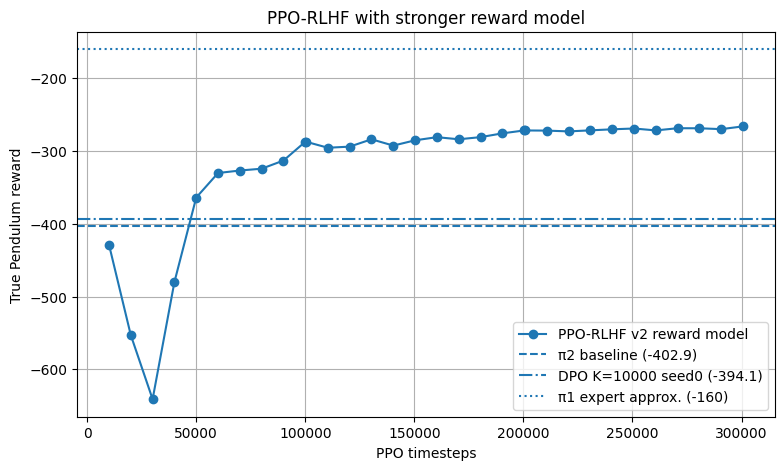

In [75]:
plt.figure(figsize=(9, 5))

plt.plot(
    ppo_rlhf_v2_history["timesteps"],
    ppo_rlhf_v2_history["true_reward_mean"],
    marker="o",
    label="PPO-RLHF v2 reward model",
)

plt.axhline(pi2_eval_mean, linestyle="--", label=f"π2 baseline ({pi2_eval_mean:.1f})")
plt.axhline(-394.070132, linestyle="-.", label="DPO K=10000 seed0 (-394.1)")
plt.axhline(-160, linestyle=":", label="π1 expert approx. (-160)")

plt.xlabel("PPO timesteps")
plt.ylabel("True Pendulum reward")
plt.title("PPO-RLHF with stronger reward model")
plt.grid(True)
plt.legend()
plt.show()

In [76]:
def sb3_log_prob_action(model, obs_np, action_np):
    """
    Approximate log π(a|s) for SB3 Gaussian policy.
    obs_np: shape [obs_dim]
    action_np: shape [act_dim]
    """
    obs_tensor, _ = model.policy.obs_to_tensor(obs_np)

    action_tensor = torch.as_tensor(
        action_np,
        dtype=torch.float32,
        device=model.device,
    )

    if action_tensor.ndim == 1:
        action_tensor = action_tensor.view(1, -1)

    with torch.no_grad():
        dist = model.policy.get_distribution(obs_tensor)
        log_prob = dist.log_prob(action_tensor)

    return float(log_prob.detach().cpu().item())

In [77]:
class KLLearnedRewardWrapper(gym.Wrapper):
    def __init__(
        self,
        env,
        reward_model,
        rm_mean,
        rm_std,
        ref_model,
        kl_coef=0.003,
        device="cpu",
        reward_scale=1.0,
        reward_clip=10.0,
    ):
        super().__init__(env)

        self.reward_model = reward_model
        self.reward_model.eval()

        self.ref_model = ref_model
        self.ref_model.policy.eval()

        self.current_model = None  # set after PPO model is created

        self.rm_mean = rm_mean
        self.rm_std = rm_std
        self.kl_coef = kl_coef
        self.device = device
        self.reward_scale = reward_scale
        self.reward_clip = reward_clip

        self.last_obs = None

    def reset(self, **kwargs):
        obs, info = self.env.reset(**kwargs)
        self.last_obs = obs
        return obs, info

    def step(self, action):
        current_obs = self.last_obs

        next_obs, true_reward, terminated, truncated, info = self.env.step(action)

        obs_t = torch.as_tensor(
            current_obs,
            dtype=torch.float32,
            device=self.device,
        ).view(1, -1)

        act_t = torch.as_tensor(
            action,
            dtype=torch.float32,
            device=self.device,
        ).view(1, -1)

        with torch.no_grad():
            raw_rm_reward = self.reward_model(obs_t, act_t).item()

        # Normalize reward model output
        learned_reward = (raw_rm_reward - self.rm_mean) / self.rm_std
        learned_reward = learned_reward * self.reward_scale
        learned_reward = float(np.clip(learned_reward, -self.reward_clip, self.reward_clip))

        # KL sample estimate: log π_current(a|s) - log π_ref(a|s)
        kl_sample = 0.0

        if self.current_model is not None:
            logp_current = sb3_log_prob_action(
                self.current_model,
                current_obs,
                action,
            )

            logp_ref = sb3_log_prob_action(
                self.ref_model,
                current_obs,
                action,
            )

            kl_sample = logp_current - logp_ref

        final_reward = learned_reward - self.kl_coef * kl_sample

        info["true_reward"] = true_reward
        info["learned_reward"] = learned_reward
        info["kl_sample"] = kl_sample
        info["kl_penalty"] = self.kl_coef * kl_sample
        info["final_rlhf_reward"] = final_reward

        self.last_obs = next_obs

        return next_obs, final_reward, terminated, truncated, info

In [78]:
def train_kl_ppo_rlhf_staged(
    reward_model,
    rm_mean,
    rm_std,
    phases,
    kl_coef=0.003,
    reward_scale=1.0,
    reward_clip=10.0,
    seed=0,
    eval_seed_start=70_000,
):
    set_all_seeds(seed)

    ref_model = PPO.load(PI2_PATH, device=DEVICE)
    ref_model.policy.eval()

    model = None

    all_history = {
        "timesteps": [],
        "true_reward_mean": [],
        "true_reward_std": [],
        "phase": [],
    }

    best_reward_global = -float("inf")
    best_state_global = None

    for phase_idx, phase in enumerate(phases):
        phase_name = phase["name"]
        timesteps = phase["timesteps"]
        lr = phase["lr"]

        print("\n" + "=" * 90)
        print(f"KL PPO-RLHF phase {phase_idx+1}: {phase_name} | lr={lr} | kl_coef={kl_coef}")
        print("=" * 90)

        base_env = gym.make(ENV_NAME)

        rm_env = KLLearnedRewardWrapper(
            base_env,
            reward_model=reward_model,
            rm_mean=rm_mean,
            rm_std=rm_std,
            ref_model=ref_model,
            kl_coef=kl_coef,
            device=DEVICE,
            reward_scale=reward_scale,
            reward_clip=reward_clip,
        )

        if model is None:
            model = PPO.load(PI2_PATH, env=rm_env, device=DEVICE)
        else:
            model.set_env(rm_env)

        # important: wrapper needs access to current policy
        rm_env.current_model = model

        model.learning_rate = lr
        model.lr_schedule = lambda _: lr

        for group in model.policy.optimizer.param_groups:
            group["lr"] = lr

        callback = TrueRewardEvalCallback(
            eval_every_timesteps=10_000,
            eval_episodes=100,
            eval_seed_start=eval_seed_start,
        )

        model.learn(
            total_timesteps=timesteps,
            callback=callback,
            reset_num_timesteps=(phase_idx == 0),
        )

        # Load best checkpoint from this phase
        if callback.best_state_dict is not None:
            model.policy.load_state_dict(callback.best_state_dict)

        # Store global best
        if callback.best_reward > best_reward_global:
            best_reward_global = callback.best_reward
            best_state_global = copy.deepcopy(callback.best_state_dict)

        for t, m, s in zip(
            callback.history["timesteps"],
            callback.history["true_reward_mean"],
            callback.history["true_reward_std"],
        ):
            all_history["timesteps"].append(t)
            all_history["true_reward_mean"].append(m)
            all_history["true_reward_std"].append(s)
            all_history["phase"].append(phase_name)

        rm_env.close()

    if best_state_global is not None:
        model.policy.load_state_dict(best_state_global)

    print("Best KL PPO-RLHF true reward:", best_reward_global)

    return model, all_history, best_reward_global

In [79]:
kl_phases = [
    {"name": "100k_lr3e-5", "timesteps": 100_000, "lr": 3e-5},
    {"name": "100k_lr5e-6", "timesteps": 100_000, "lr": 5e-6},
    {"name": "100k_lr2e-6", "timesteps": 100_000, "lr": 2e-6},
]

ppo_kl_model, ppo_kl_history, ppo_kl_best = train_kl_ppo_rlhf_staged(
    reward_model=reward_model,   # v1 reward model
    rm_mean=rm_mean,
    rm_std=rm_std,
    phases=kl_phases,
    kl_coef=0.003,
    reward_scale=1.0,
    reward_clip=10.0,
    seed=0,
    eval_seed_start=70_000,
)


KL PPO-RLHF phase 1: 100k_lr3e-5 | lr=3e-05 | kl_coef=0.003
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 200      |
|    ep_rew_mean     | -90      |
| time/              |          |
|    fps             | 822      |
|    iterations      | 1        |
|    time_elapsed    | 2        |
|    total_timesteps | 2048     |
---------------------------------
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 200          |
|    ep_rew_mean          | -88.6        |
| time/                   |              |
|    fps                  | 675          |
|    iterations           | 2            |
|    time_elapsed         | 6            |
|    total_timesteps      | 4096         |
| train/                  |              |
|    approx_kl            | 0.0015577604 |
|    clip_fraction        | 0.000195     |
|    c

In [80]:
ppo_kl_mean, ppo_kl_std, _ = evaluate_sb3_policy(
    ppo_kl_model,
    episodes=300,
    deterministic=True,
    seed_start=70_000,
)

print("π2 baseline:", pi2_eval_mean, pi2_eval_std)
print("DPO K=10000 seed0:", -394.070132, 190.915968)
print("Old best PPO-RLHF:", ppo_rlhf_300k_mean, ppo_rlhf_300k_std)
print("KL PPO-RLHF:", ppo_kl_mean, ppo_kl_std)
print("Improvement over π2:", ppo_kl_mean - pi2_eval_mean)
print("Best during training:", ppo_kl_best)

π2 baseline: -402.8590272629127 195.25502897571167
DPO K=10000 seed0: -394.070132 190.915968
Old best PPO-RLHF: -224.6004208576593 192.79626876193964
KL PPO-RLHF: -225.792775008095 189.55021175797359
Improvement over π2: 177.06625225481773
Best during training: -253.50761161332858


## 10. Small beta sweep over 3 seeds

In [ ]:
SEEDS = [0, 1, 2]
BETAS = [0.001, 0.003, 0.01, 0.03]
LR = 1e-6
EPOCHS = 5
BATCH_SIZE = 16

pure_dpo_results = []

for seed in SEEDS:
    for beta in BETAS:
        print("\n" + "=" * 70)
        print(f"seed={seed} | beta={beta}")
        print("=" * 70)

        model, losses, mean_reward, std_reward = run_one_pure_dpo_test(
            beta=beta,
            lr=LR,
            epochs=EPOCHS,
            batch_size=BATCH_SIZE,
            seed=seed,
            eval_seed_start=30_000,
        )

        pure_dpo_results.append({
            "seed": seed,
            "beta": beta,
            "lr": LR,
            "epochs": EPOCHS,
            "batch_size": BATCH_SIZE,
            "mean_reward": mean_reward,
            "std_reward": std_reward,
            "final_loss": losses[-1],
        })

pure_dpo_results_df = pd.DataFrame(pure_dpo_results)
pure_dpo_results_df


In [ ]:
summary = (
    pure_dpo_results_df
    .groupby("beta")
    .agg(
        mean_reward=("mean_reward", "mean"),
        std_across_seeds=("mean_reward", "std"),
    )
    .reset_index()
)

pi1_eval_mean, _, _ = evaluate_sb3_policy(
    pi1_model,
    episodes=300,
    deterministic=True,
    seed_start=30_000,
)

pi2_eval_mean, _, _ = evaluate_sb3_policy(
    pi2_model,
    episodes=300,
    deterministic=True,
    seed_start=30_000,
)

plt.figure(figsize=(9, 5))

plt.errorbar(
    summary["beta"],
    summary["mean_reward"],
    yerr=summary["std_across_seeds"],
    marker="o",
    capsize=4,
    label="Pure trajectory-level DPO, mean ± std over 3 seeds",
)

plt.axhline(pi1_eval_mean, linestyle="--", label=f"π1 expert ({pi1_eval_mean:.1f})")
plt.axhline(pi2_eval_mean, linestyle="--", label=f"π2 reference ({pi2_eval_mean:.1f})")

plt.xlabel("β")
plt.ylabel("Final average reward")
plt.title("Pure trajectory-level DPO: effect of β")
plt.grid(True)
plt.legend()
plt.show()


In [2]:
from pathlib import Path
import pandas as pd

roots = [
    Path("/scratch/izar/mduric/RL_artifacts"),
    Path("/scratch/izar/mduric/RL"),
]

candidates = []
for root in roots:
    if root.exists():
        candidates.extend(root.rglob("*dpo*.csv"))
        candidates.extend(root.rglob("*DPO*.csv"))

seen = set()
candidates = [p for p in candidates if not (str(p) in seen or seen.add(str(p)))]

matches = []

for p in candidates:
    name_hit = any(s in p.name.lower() for s in ["2000", "k2000", "2k"])
    try:
        df = pd.read_csv(p)

        k_hit = False
        if "K" in df.columns:
            k_hit = (df["K"].astype(str) == "2000").any()

        if name_hit or k_hit:
            matches.append(p)
            print("\nFOUND:", p)
            print("columns:", df.columns.tolist())
            print(df.head())

    except Exception:
        pass

print("\nNumber of possible K=2000 DPO files:", len(matches))


Number of possible K=2000 DPO files: 0


In [4]:
from pathlib import Path
import pandas as pd
import pickle
import json

roots = [
    Path("/scratch/izar/mduric/RL_artifacts"),
    Path("/scratch/izar/mduric/RL"),
    Path("/scratch/izar/mduric/slurm_logs"),
]

hits = []

def check_df(path, df):
    cols = list(df.columns) if hasattr(df, "columns") else []
    text_cols = " ".join(map(str, cols)).lower()
    name = path.name.lower()

    has_dpo = ("dpo" in name) or ("dpo" in text_cols)
    has_k2000 = False

    if hasattr(df, "columns"):
        if "K" in df.columns:
            has_k2000 = (df["K"].astype(str) == "2000").any()
        if "k" in df.columns:
            has_k2000 = has_k2000 or (df["k"].astype(str) == "2000").any()

    name_k2000 = any(s in name for s in ["2000", "k2000", "2k", "k_2000"])

    if has_dpo or has_k2000 or name_k2000:
        print("\nFOUND POSSIBLE FILE:", path)
        print("columns:", cols)

        if hasattr(df, "head"):
            display(df.head())

        if hasattr(df, "columns"):
            if "K" in df.columns:
                print("unique K:", sorted(df["K"].dropna().unique().tolist()))
            if "dpo_mean" in df.columns:
                print("dpo_mean mean:", df["dpo_mean"].mean())

        hits.append(path)

for root in roots:
    if not root.exists():
        continue

    for path in root.rglob("*"):
        if not path.is_file():
            continue

        suffix = path.suffix.lower()
        name = path.name.lower()

        try:
            if suffix == ".csv":
                df = pd.read_csv(path)
                check_df(path, df)

            elif suffix in [".pkl", ".pickle"]:
                obj = pd.read_pickle(path)

                if isinstance(obj, pd.DataFrame):
                    check_df(path, obj)
                elif isinstance(obj, dict):
                    keys = " ".join(map(str, obj.keys())).lower()
                    if "dpo" in keys or "2000" in keys or "k" in keys:
                        print("\nFOUND POSSIBLE PKL DICT:", path)
                        print("keys:", obj.keys())
                        hits.append(path)

            elif suffix in [".txt", ".log", ".out", ".ipynb"]:
                text = path.read_text(errors="ignore")
                low = text.lower()
                if ("dpo" in low and "2000" in low) or ("pure_dpo" in low):
                    print("\nFOUND TEXT HIT:", path)
                    lines = text.splitlines()
                    for i, line in enumerate(lines):
                        l = line.lower()
                        if ("dpo" in l and "2000" in l) or "pure_dpo" in l:
                            print(f"line {i+1}: {line[:300]}")
                    hits.append(path)

        except Exception as e:
            pass

print("\nTOTAL HITS:", len(hits))
for h in hits:
    print(h)


FOUND POSSIBLE FILE: /scratch/izar/mduric/RL_artifacts/pure_dpo_K10000_final_3seeds.csv
columns: ['seed', 'K', 'beta', 'lr', 'max_updates', 'pi2_mean', 'pi2_std', 'dpo_mean', 'dpo_std', 'improvement', 'best_step', 'best_reward_during_training']


,seed,K,beta,lr,max_updates,pi2_mean,pi2_std,dpo_mean,dpo_std,improvement,best_step,best_reward_during_training
0,0,10000,0.3,3.000000e-07,1500,-402.859027,195.255029,-394.070132,190.915968,8.788896,500,-415.756675
1,1,10000,0.3,3.000000e-07,1500,-399.712031,174.919180,-391.568600,169.469028,8.143431,500,-385.306634
2,2,10000,0.3,3.000000e-07,1500,-390.783238,175.314030,-382.386293,171.654233,8.396945,500,-374.187103


unique K: [10000]
dpo_mean mean: -389.3416749371386

FOUND POSSIBLE FILE: /scratch/izar/mduric/RL_artifacts/pure_dpo_K10000_final_summary.csv
columns: ['K', 'beta', 'lr', 'max_updates', 'pi2_mean', 'pi2_std_across_seeds', 'dpo_mean', 'dpo_std_across_seeds', 'improvement_mean', 'improvement_std', 'mean_best_step']


,K,beta,lr,max_updates,pi2_mean,pi2_std_across_seeds,dpo_mean,dpo_std_across_seeds,improvement_mean,improvement_std,mean_best_step
0,10000,0.3,3.000000e-07,1500,-397.784765,6.264338,-389.341675,6.152025,8.44309,0.325197,500.0


unique K: [10000]
dpo_mean mean: -389.3416749371386

FOUND POSSIBLE FILE: /scratch/izar/mduric/RL_artifacts/pure_dpo_K10000_best_by_beta_seed0.csv
columns: ['beta', 'lr', 'best_step', 'best_reward', 'improvement_same_eval', 'final_logged_reward']


...

unique K: [10000]
dpo_mean mean: -389.341675

FOUND TEXT HIT: /scratch/izar/mduric/RL/Pendulum_RLHF_clean_package/Pendulum_PPO_RLHF_requested_plots.ipynb

FOUND POSSIBLE FILE: /scratch/izar/mduric/RL/Pendulum_RLHF_clean_package/pendulum_dpo_beta_sweep_K1000_3seeds.csv
columns: ['beta', 'lr', 'epochs', 'seed', 'pi2_mean', 'dpo_mean', 'improvement', 'best_epoch', 'best_reward_during_training']


,beta,lr,epochs,seed,pi2_mean,dpo_mean,improvement,best_epoch,best_reward_during_training
0,0.003,3.000000e-07,20,0,-402.859027,-390.976711,11.882316,7,-360.435865
1,0.003,3.000000e-07,20,1,-399.712031,-393.741524,5.970507,8,-372.814706
2,0.003,3.000000e-07,20,2,-390.783238,-385.325168,5.458070,4,-352.956530
3,0.010,3.000000e-07,20,0,-402.859027,-390.931965,11.927062,7,-360.486036
4,0.010,3.000000e-07,20,1,-399.712031,-393.692440,6.019591,8,-372.762093


dpo_mean mean: -389.95771249999996

FOUND TEXT HIT: /scratch/izar/mduric/RL/Pendulum_RLHF_clean_package/.ipynb_checkpoints/Pendulum_PPO_RLHF_requested_plots-checkpoint.ipynb

FOUND POSSIBLE FILE: /scratch/izar/mduric/RL/Pendulum_RLHF_clean_package/data/pendulum_dpo_K10000_final_3seeds.csv
columns: ['seed', 'K', 'beta', 'lr', 'max_updates', 'pi2_mean', 'pi2_std', 'dpo_mean', 'dpo_std', 'improvement', 'best_step', 'best_reward_during_training']


,seed,K,beta,lr,max_updates,pi2_mean,pi2_std,dpo_mean,dpo_std,improvement,best_step,best_reward_during_training
0,0,10000,0.3,3.000000e-07,1500,-402.859027,195.255029,-394.070132,190.915968,8.788896,500,-415.756675
1,1,10000,0.3,3.000000e-07,1500,-399.712031,174.919180,-391.568600,169.469028,8.143431,500,-385.306634
2,2,10000,0.3,3.000000e-07,1500,-390.783238,175.314030,-382.386293,171.654233,8.396945,500,-374.187103


unique K: [10000]
dpo_mean mean: -389.34167499999995

FOUND TEXT HIT: /scratch/izar/mduric/slurm_logs/bevformer_vjepa_2868376.out

FOUND TEXT HIT: /scratch/izar/mduric/slurm_logs/bevformer_vjepa_2863866.out

TOTAL HITS: 31
/scratch/izar/mduric/RL_artifacts/pure_dpo_K10000_final_3seeds.csv
/scratch/izar/mduric/RL_artifacts/pure_dpo_K10000_final_summary.csv
/scratch/izar/mduric/RL_artifacts/pure_dpo_K10000_best_by_beta_seed0.csv
/scratch/izar/mduric/RL_artifacts/pure_dpo_K10000_fixed_update_sweep_seed0.csv
/scratch/izar/mduric/RL_artifacts/pure_dpo_beta_sweep_earlystop_3seeds.csv
/scratch/izar/mduric/RL_artifacts/rlhf_results/dpo_existing_dataset_size_sweep_summary.csv
/scratch/izar/mduric/RL_artifacts/rlhf_results/ppo_rlhf_K_sweep_training_curves.csv
/scratch/izar/mduric/RL_artifacts/rlhf_results/dpo_existing_dataset_size_sweep_eval.csv
/scratch/izar/mduric/RL_artifacts/rlhf_results/ppo_rlhf_K_sweep_raw.csv
/scratch/izar/mduric/RL_artifacts/rlhf_results/pure_dpo_valid_K1000_K10000_summa

The main limitation of pure trajectory-level DPO in this experiment is that the optimization signal is indirect and noisy. The method optimizes relative trajectory log-probabilities, not the environment reward directly. In Pendulum-v1, a trajectory is long and continuous, so small changes in the action distribution can accumulate over many timesteps and lead to unstable behavior.

As a result, the DPO loss can decrease without producing a large improvement in true reward. This suggests that the model learns to separate preferred and rejected trajectories under the DPO objective, but this separation does not reliably translate into better long-horizon control. The method is also sensitive to $\beta$, learning rate, dataset size, and the quality of the initialization policy $\pi_2$.

Therefore, pure trajectory-level DPO produced only modest improvements over $\pi_2$, while PPO-RLHF was more effective because it uses the learned reward model inside an actual policy optimization loop and directly updates the policy through environment rollouts.
